# BINT evaluation notebook

**Structure**

| Section | Content |
|---|---|
| 0 | Imports |
| 1 | Global style, colors, size constants |
| 2 | I/O helpers |
| 3 | Base config, model factory |
| 4 | Two-tier metric collection |
| 5 | Run orchestration |
| 6 | Derived metrics |
| 7 | Plot helpers |
| 8 | Experiment definitions |
| 9 | Data file paths |
| **10** | **RUN ALL EXPERIMENTS (single cell, skip-if-exists)** |
| 11 | Load & prepare data |
| 12 | Summary tables |
| 13 | Relative change table |
| 14 | Fig 1 — Ablation 2×2 boxplots |
| 15 | Fig 2 — Safety–performance scatter |
| 16 | Fig 3 — Trust gap over time |
| 17 | Fig 4 — Trust distributions (violin) |
| 18 | Fig 5 — Trust score vs actual reliability |
| 19 | Fig 6 — TNFT balance over time |
| 20 | Fig 7 — Burn accumulation over time |
| 21 | Fig 8 — Provider composition bar |
| 22 | Fig 9 — Decision rejection breakdown |
| 23 | Fig 10 — Interaction outcomes over time |
| 24 | Fig 11 — Sensitivity to malicious fraction |

In [11]:
from __future__ import annotations

import gc
import json
import multiprocessing as mp
import time
import traceback
import warnings
from collections import Counter
from concurrent.futures import ProcessPoolExecutor, as_completed
from copy import deepcopy
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

try:
    from tqdm.auto import tqdm
except ImportError:
    tqdm = None

import sys
PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from agents import DeliveryAgent, MaliciousDeliveryAgent
from model import AgentProfile, BintWorldModel, MAP_DATA_SERVICE

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:.3f}".format)
warnings.filterwarnings("ignore", category=FutureWarning)

In [12]:
# ── Scenario ordering, labels, colors ────────────────────────────────────────

SCENARIO_ORDER = [
    "honest_only_upper_bound",
    "accept_all",
    "bint_baseline",
    "bint_staking",
]

SCENARIO_LABELS = {
    "honest_only_upper_bound": "Honest-only",
    "accept_all":     "Accept all",
    "bint_baseline":           "BINT (baseline)",
    "bint_staking":            "BINT",
}

# Wong (2011) colorblind-safe palette
SCENARIO_COLORS = {
    "honest_only_upper_bound": "#0072B2",   # blue
    "accept_all":     "#D55E00",   # vermillion
    "bint_baseline":           "#E69F00",   # orange
    "bint_staking":            "#009E73",   # bluish-green
}

LABEL_COLORS = {SCENARIO_LABELS[k]: v for k, v in SCENARIO_COLORS.items()}

# ── Figure size constants (width, height in inches) ──────────────────────────
FIG_SINGLE = (9.5,  6.5)
FIG_WIDE   = (13.0, 6.0)
FIG_2PANEL = (15.0, 6.0)
FIG_3PANEL = (18.0, 6.0)
FIG_2X2    = (14.0, 11.0)

# ── Global matplotlib / seaborn style ────────────────────────────────────────
sns.set_theme(
    style="ticks",
    context="paper",
    font_scale=1.35,
    rc={
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.linestyle":    "--",
        "grid.alpha":        0.35,
        "figure.dpi":        120,
        "savefig.dpi":       300,
        "savefig.bbox":      "tight",
    },
)

MASTER_SEED = 1337

In [13]:
OUTPUT_DIR = PROJECT_ROOT / "evaluation_outputs"
DATA_DIR   = OUTPUT_DIR / "data"
FIGURE_DIR = OUTPUT_DIR / "figures"

for _d in [OUTPUT_DIR, DATA_DIR, FIGURE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)


def save_df(df: pd.DataFrame, stem: Path) -> Path:
    stem.parent.mkdir(parents=True, exist_ok=True)
    path = stem.with_suffix(".parquet")
    try:
        df.to_parquet(path, index=False)
    except Exception:
        path = stem.with_suffix(".csv")
        df.to_csv(path, index=False)
    return path


def load_df(stem: Path) -> pd.DataFrame:
    for suffix in (".parquet", ".csv"):
        p = stem.with_suffix(suffix)
        if p.exists():
            return pd.read_parquet(p) if suffix == ".parquet" else pd.read_csv(p)
    raise FileNotFoundError(f"No data file at {stem}.*")


def save_figure(name: str) -> Path:
    """Save as PDF (vector, for LaTeX) + SVG (editable in Inkscape/Illustrator)."""
    pdf_path = FIGURE_DIR / name
    plt.savefig(pdf_path, dpi=150, bbox_inches="tight")
    svg_path = FIGURE_DIR / Path(name).with_suffix(".svg").name
    plt.savefig(svg_path, bbox_inches="tight")
    print(f"Saved: {pdf_path.name} + {svg_path.name}")
    return pdf_path


def get_seeds(n: int, base: int = MASTER_SEED) -> list[int]:
    return [int(s) for s in np.random.SeedSequence(base).generate_state(n)]


def data_exists(*stems: Path) -> bool:
    return all(
        s.with_suffix(".parquet").exists() or s.with_suffix(".csv").exists()
        for s in stems
    )

In [14]:
FINAL_BASE_PARAMETERS: dict[str, Any] = {
    "width": 150,
    "height": 150,
    "num_drop_offs": 35,

    "honest_agents": 14,
    "malicious_agents": 6,

    "vision_radius": 2,
    "max_steps": 5_000,
    "genesis_tokens": 5,

    "trust_reject_threshold": 0.30,
    "trust_accept_threshold": 0.80,
    "context_match_weight": 1.0,
    "other_context_weight": 0.25,
    "trust_prior_active": 1.0,
    "trust_prior_burned": 1.0,
    "burned_weight_multiplier": 1.0,
    "filter_untrusted_evidence": True,

    "max_negative_review_rate": 0.60,
    "min_reviews_before_reviewer_check": 8,

    "staking_enabled": True,
    "staking_min_fraction": 0.10,
    "staking_max_fraction": 0.90,
    "provider_stake_vtp_weight": 0.8,
    "provider_stake_reviewer_weight": 0.2,
    "requester_stake_vtp_weight": 0.4,
    "requester_stake_reviewer_weight": 0.6,

    "false_map_probability": 0.50,
    "false_negative_review_probability": 0.50,
    "false_positive_review_probability": 0.50,
}


def make_config(**overrides: Any) -> dict[str, Any]:
    cfg = deepcopy(FINAL_BASE_PARAMETERS)
    cfg.update(overrides)
    return cfg


def _agent_kwargs(cfg: dict[str, Any]) -> dict[str, Any]:
    keys = [
        "vision_radius", "trust_reject_threshold", "trust_accept_threshold",
        "max_negative_review_rate", "min_reviews_before_reviewer_check",
        "context_match_weight", "other_context_weight",
        "trust_prior_active", "trust_prior_burned", "burned_weight_multiplier",
        "filter_untrusted_evidence", "staking_min_fraction", "staking_max_fraction",
        "provider_stake_vtp_weight", "provider_stake_reviewer_weight",
        "requester_stake_vtp_weight", "requester_stake_reviewer_weight",
    ]
    return {k: cfg[k] for k in keys}


def make_agent_profiles(cfg: dict[str, Any]) -> list[AgentProfile]:
    profiles: list[AgentProfile] = []
    if int(cfg["honest_agents"]) > 0:
        profiles.append(AgentProfile(
            agent_class=DeliveryAgent,
            count=int(cfg["honest_agents"]),
            kwargs=_agent_kwargs(cfg),
        ))
    if int(cfg["malicious_agents"]) > 0:
        mal_kw = _agent_kwargs(cfg)
        mal_kw.update({
            "false_map_probability":            cfg["false_map_probability"],
            "false_negative_review_probability": cfg["false_negative_review_probability"],
            "false_positive_review_probability": cfg["false_positive_review_probability"],
        })
        profiles.append(AgentProfile(
            agent_class=MaliciousDeliveryAgent,
            count=int(cfg["malicious_agents"]),
            kwargs=mal_kw,
        ))
    return profiles


def make_model(cfg: dict[str, Any], seed: int) -> BintWorldModel:
    model = BintWorldModel(
        rng=seed,
        width=int(cfg["width"]),
        height=int(cfg["height"]),
        num_drop_offs=int(cfg["num_drop_offs"]),
        genesis_tokens=int(cfg["genesis_tokens"]),
        max_steps=int(cfg["max_steps"]),
        staking_enabled=bool(cfg["staking_enabled"]),
        agent_profiles=make_agent_profiles(cfg),
    )
    # DEBUG_DECISIONS=False keeps decision_events list empty during production
    # runs. Set True on a small test run to inspect per-decision detail.
    model.DEBUG_DECISIONS = False
    return model

## Profiling cell

Run this on a single simulation to identify the actual performance bottleneck
before each optimisation pass. The output tells you exactly where time is spent.

Set `N_PROF_STEPS` to a small value (200-500) for a quick profile.
Everything in the output with >2% cumulative time is worth investigating.

In [15]:
# ── Single-run profiler ───────────────────────────────────────────────────────
# Run this cell to profile a single simulation and see where time goes.
# Compare before/after an optimisation to measure actual speedup.
import cProfile, pstats, io

N_PROF_STEPS = 300  # keep small for a quick profile; increase for accuracy

_prof_cfg  = ABLATION_CONFIGS[2][1]  # bint_staking (most expensive config)
_prof_seed = ABLATION_SEEDS[0]

pr = cProfile.Profile()
pr.enable()
_prof_model = make_model(_prof_cfg, _prof_seed)
for _ in range(N_PROF_STEPS):
    _prof_model.step()
pr.disable()

_buf = io.StringIO()
_ps  = pstats.Stats(pr, stream=_buf).sort_stats("cumulative")
_ps.print_stats(30)
print(_buf.getvalue())

# Quick cache effectiveness summary (if trust score cache is enabled)
if hasattr(_prof_model, "_trust_score_cache"):
    print(f"Trust score cache size at end: {len(_prof_model._trust_score_cache)} entries")
if hasattr(_prof_model, "_reviewer_cache"):
    print(f"Reviewer cache size at end:    {len(_prof_model._reviewer_cache)} entries")
if hasattr(_prof_model, "_trust_evidence_cache"):
    print(f"Trust evidence cache size:     {len(_prof_model._trust_evidence_cache)} entries")

         2859548 function calls (2858064 primitive calls) in 4.777 seconds

   Ordered by: cumulative time
   List reduced from 400 to 30 due to restriction <30>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
      300    0.002    0.000    3.780    0.013 /home/javid/Documents/int/bint/bint/.venv/lib64/python3.12/site-packages/mesa/model.py:202(_wrapped_step)
      300    0.005    0.000    3.778    0.013 /home/javid/Documents/int/bint/bint/.venv/lib64/python3.12/site-packages/mesa/model.py:206(_advance_time)
      300    0.002    0.000    3.764    0.013 /home/javid/Documents/int/bint/bint/.venv/lib64/python3.12/site-packages/mesa/time/events.py:125(execute)
      300    0.004    0.000    3.760    0.013 /home/javid/Documents/int/bint/bint/.venv/lib64/python3.12/site-packages/mesa/time/events.py:278(_execute_and_reschedule)
      300    0.006    0.000    3.733    0.012 /home/javid/Documents/int/bint/bint/.venv/lib64/python3.12/site-packages/mesa/model.py:236(_do_

## Experimental configuration

All ablation scenarios run on a 150×150 grid, 35 drop-offs, vision radius 2,
5,000 steps, 5 genesis tokens per agent. Trust prior α = β = 1.0.

| Scenario | Honest | Malicious | Trust filtering | Staking | Map atk. | Review atk. | Seeds |
|---|---|---|---|---|---|---|---|
| Honest-only | 100 | 0 | — | No | — | — | 100 |
| Accept all | 14 | 6 | None (0.0/0.01) | No | 0.50 | 0.50 | 100 |
| BINT (baseline) | 14 | 6 | Yes (0.30/0.80) | No | 0.50 | 0.50 | 100 |
| BINT | 14 | 6 | Yes (0.30/0.80) | Yes | 0.50 | 0.50 | 100 |

**Sensitivity**: malicious fraction 10–60%, 3 scenario types, 100 seeds each.

**Attack sensitivity** (new): `false_map_probability` ∈ [0.0, 0.25, 0.50, 0.75, 1.0]
and `false_review_probability` ∈ [0.0, 0.25, 0.50, 0.75, 1.0],
BINT vs Accept-all, fixed 30% malicious, 100 seeds each.

In [16]:
def agent_kind(agent: DeliveryAgent) -> str:
    return "malicious" if isinstance(agent, MaliciousDeliveryAgent) else "honest"


def agent_type_map(model: BintWorldModel) -> dict[str, str]:
    return {a.unique_id: agent_kind(a) for a in model.cached_delivery_agents}


def safe_div(num: Any, den: Any) -> Any:
    return np.where(den > 0, num / den, np.nan)


def _fast_trust(model: BintWorldModel, target_id: str, evaluator: DeliveryAgent) -> float:
    """Single-evaluator trust score for trajectory collection (fast path)."""
    try:
        return float(evaluator.calculate_trust_summary(target_id, MAP_DATA_SERVICE)["score"])
    except Exception:
        return float("nan")


def collect_trajectory_metrics(
    model: BintWorldModel,
    *,
    config_name: str,
    seed: int,
    sim_step: int,
) -> dict[str, Any]:
    """
    Cheap metrics for every trajectory step.
    Trust uses ONE representative honest evaluator to avoid O(n^2) cost.
    """
    agents    = model.cached_delivery_agents
    honest    = [a for a in agents if agent_kind(a) == "honest"]
    malicious = [a for a in agents if agent_kind(a) == "malicious"]

    # One evaluator for trajectory trust (fast; full consensus at final snapshot)
    evaluator = honest[0] if honest else (agents[0] if agents else None)

    # Skip self-evaluation: evaluator should not score itself.
    _eval_id = evaluator.unique_id if evaluator else None
    t_hon = [_fast_trust(model, a.unique_id, evaluator) for a in honest
             if a.unique_id != _eval_id] if evaluator else []
    t_mal = [_fast_trust(model, a.unique_id, evaluator) for a in malicious] if evaluator else []

    avg_hon = float(np.nanmean(t_hon)) if t_hon else float("nan")
    avg_mal = float(np.nanmean(t_mal)) if t_mal else float("nan")
    trust_gap = (avg_hon - avg_mal) if not (np.isnan(avg_hon) or np.isnan(avg_mal)) else float("nan")

    # TNFT ledger counts by owner type
    kinds = agent_type_map(model)
    lc: Counter = Counter()
    for tnft in model.tnft_ledger:
        ok      = kinds.get(tnft.get("owner"), "unknown")
        active  = bool(tnft.get("status"))
        staked  = active and tnft.get("staked_for") is not None
        lc["active_"  + ok] += int(active)
        lc["burned_"  + ok] += int(not active)
        lc["staked_"  + ok] += int(staked)

    # Fix C: O(1) reads via model-side counters instead of O(n) dict iteration.
    n_int   = len(model.interactions)
    n_succ  = model._n_success
    n_fail  = model._n_failure
    n_false = model._n_false_reviews
    # Provider-type counts still require an O(interactions) pass — acceptable
    # since len(interactions) << len(tnft_ledger) at any point in the run.
    n_mal_p = sum(1 for i in model.interactions.values() if kinds.get(i.trustee_id) == "malicious")
    n_hon_p = sum(1 for i in model.interactions.values() if kinds.get(i.trustee_id) == "honest")
    n_total = len(agents)

    return {
        "config":    config_name,
        "seed":      seed,
        "sim_step":  sim_step,
        "malicious_fraction": len(malicious) / n_total if n_total else 0.0,

        "honest_agents":   len(honest),
        "malicious_agents": len(malicious),

        "points_honest":    sum(a.points for a in honest),
        "points_malicious": sum(a.points for a in malicious),

        "deliveries_honest":    sum(a.delivery_count for a in honest),
        "deliveries_malicious": sum(a.delivery_count for a in malicious),

        "avg_trust_honest":               avg_hon,
        "avg_trust_malicious":            avg_mal,
        "trust_gap_honest_minus_malicious": trust_gap,

        "active_tnfts_honest":    lc.get("active_honest",    0),
        "active_tnfts_malicious": lc.get("active_malicious", 0),
        "burned_tnfts_honest":    lc.get("burned_honest",    0),
        "burned_tnfts_malicious": lc.get("burned_malicious", 0),
        "staked_tnfts_honest":    lc.get("staked_honest",    0),
        "staked_tnfts_malicious": lc.get("staked_malicious", 0),

        "interactions":               n_int,
        "outcome_success":            n_succ,
        "outcome_failure":            n_fail,
        "accepted_malicious_provider": n_mal_p,
        "accepted_honest_provider":    n_hon_p,
        "false_reviews":               n_false,
    }


def collect_final_snapshot(
    model: BintWorldModel,
    *,
    config_name: str,
    seed: int,
) -> pd.DataFrame:
    """
    Expensive per-agent snapshot at run end.
    Uses full consensus trust (all honest evaluators).
    Uses actual_outcome_status from metadata for true provider reliability.
    """
    kinds = agent_type_map(model)
    honest_evals = [a for a in model.cached_delivery_agents if agent_kind(a) == "honest"]

    # Actual (not reported) provider outcomes
    prov_actual_success: Counter = Counter()
    prov_interactions:   Counter = Counter()
    for iid, interaction in model.interactions.items():
        oid    = interaction.trustee_id
        outcome = model.outcomes.get(iid)
        if outcome is None:
            continue
        prov_interactions[oid] += 1
        actual = (outcome.meta or {}).get("actual_outcome_status", outcome.status)
        if actual == "success":
            prov_actual_success[oid] += 1

    # Per-agent TNFT counts
    owner_active: Counter = Counter()
    owner_burned: Counter = Counter()
    for tnft in model.tnft_ledger:
        o = tnft.get("owner")
        if tnft.get("status"):
            owner_active[o] += 1
        else:
            owner_burned[o] += 1

    # Compute once outside loop to avoid O(agents²) nested comprehension.
    _n_ag = len(model.cached_delivery_agents)
    _n_ml = sum(1 for a in model.cached_delivery_agents if agent_kind(a) == "malicious")
    _mf   = _n_ml / _n_ag if _n_ag > 0 else 0.0

    rows = []
    for agent in model.cached_delivery_agents:
        aid  = agent.unique_id
        kind = kinds.get(aid, "unknown")

        # Full consensus trust score
        scores = []
        for ev in honest_evals:
            if ev.unique_id == aid:
                continue
            try:
                scores.append(ev.calculate_trust_summary(aid, MAP_DATA_SERVICE)["score"])
            except Exception:
                pass
        trust_score = float(np.nanmean(scores)) if scores else float("nan")

        provided = prov_interactions[aid]
        actual_succ = prov_actual_success[aid]
        actual_reliability = actual_succ / provided if provided > 0 else float("nan")

        rev = model.get_reviewer_summary(aid)
        rows.append({
            "config":             config_name,
            "seed":               seed,
            "agent_id":           aid,
            "agent_type":         kind,
            "malicious_fraction": _mf,
            "final_trust_score":  trust_score,
            "points":             agent.points,
            "deliveries":         agent.delivery_count,
            "provided_interactions": provided,
            "actual_reliability": actual_reliability,
            "active_tnfts":       owner_active[aid],
            "burned_tnfts":       owner_burned[aid],
            "total_reviews_given":        int(rev["total_reviews"]),
            "negative_reviews_given":     int(rev["negative_reviews"]),
            "negative_review_rate_given": float(rev["negative_review_rate"]),
        })

    return pd.DataFrame(rows)


def collect_decision_summary(model: BintWorldModel) -> dict[str, int]:
    """Return decision reason counts accumulated over the whole run.

    Uses model._decision_counts (a plain dict incremented in record_decision)
    which replaces the old O(n) iteration over decision_events.
    Falls back to iterating decision_events if the counter is absent
    (e.g. running against an older model version).
    """
    if hasattr(model, "_decision_counts"):
        return dict(model._decision_counts)
    # Fallback for older model versions
    if not hasattr(model, "decision_events"):
        return {}
    ctr: Counter = Counter()
    for ev in model.decision_events:
        reason = ev.get("reason", "unknown")
        ctr[reason] += 1
    return dict(ctr)

In [17]:
def run_one(
    cfg: dict[str, Any],
    *,
    config_name: str,
    seed: int,
    collect_every: int = 50,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:
    model     = make_model(cfg, seed)
    max_steps = int(cfg["max_steps"])

    rows = [collect_trajectory_metrics(model, config_name=config_name, seed=seed, sim_step=0)]

    for step in range(1, max_steps + 1):
        model.step()
        if step % collect_every == 0 or step == max_steps:
            rows.append(
                collect_trajectory_metrics(model, config_name=config_name, seed=seed, sim_step=step)
            )

    traj_df = pd.DataFrame(rows)
    snap_df = collect_final_snapshot(model, config_name=config_name, seed=seed)
    dec_summary = collect_decision_summary(model)

    return traj_df, snap_df, dec_summary


def _worker(args: tuple) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, int]]:
    config_name, cfg, seed, collect_every = args
    return run_one(cfg, config_name=config_name, seed=seed, collect_every=collect_every)


def run_batch(
    configs: list[tuple[str, dict[str, Any]]],
    seeds: list[int],
    *,
    collect_every: int = 50,
    max_workers: int = 8,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Returns (trajectory_df, final_df, snapshot_df, decisions_df).
    - trajectory_df : all trajectory rows for all runs
    - final_df      : last trajectory row per (config, seed)
    - snapshot_df   : per-agent final snapshots
    - decisions_df  : per-run decision reason counts
    """
    tasks = [
        (cfg_name, cfg, seed, collect_every)
        for cfg_name, cfg in configs
        for seed in seeds
    ]

    traj_parts: list[pd.DataFrame] = []
    snap_parts: list[pd.DataFrame] = []
    dec_rows:   list[dict]         = []
    errors = []

    ctx   = mp.get_context("fork")
    start = time.time()

    with ProcessPoolExecutor(max_workers=max_workers, mp_context=ctx) as pool:
        future_map = {pool.submit(_worker, t): t for t in tasks}
        total      = len(future_map)
        done       = 0

        pbar = tqdm(total=total, desc="Simulations") if tqdm else None
        try:
            for future in as_completed(future_map):
                task = future_map[future]
                try:
                    traj_df, snap_df, dec_summary = future.result()
                    traj_parts.append(traj_df)
                    snap_parts.append(snap_df)
                    dec_rows.append({"config": task[0], "seed": task[2], **dec_summary})
                except Exception as exc:
                    errors.append({
                        "config": task[0], "seed": task[2],
                        "error": repr(exc), "tb": traceback.format_exc(),
                    })
                    print(f"ERROR {task[0]} seed={task[2]}: {exc}")
                done += 1
                if pbar:
                    pbar.update(1)
                elif done % 10 == 0 or done == total:
                    print(f"  {done}/{total}")
        finally:
            if pbar:
                pbar.close()

    if not traj_parts:
        raise RuntimeError("No successful runs.")

    elapsed = time.time() - start
    print(f"Completed {len(traj_parts)}/{len(tasks)} runs in {elapsed:.1f}s.")

    if errors:
        pd.DataFrame(errors).to_csv(DATA_DIR / "run_errors.csv", index=False)
        print(f"{len(errors)} errors saved to run_errors.csv")

    traj_df = pd.concat(traj_parts, ignore_index=True, sort=False)
    snap_df = pd.concat(snap_parts, ignore_index=True, sort=False)
    dec_df  = pd.DataFrame(dec_rows).fillna(0)

    final_df = (
        traj_df
        .sort_values(["config", "seed", "sim_step"])
        .groupby(["config", "seed"], as_index=False)
        .tail(1)
        .reset_index(drop=True)
    )

    return traj_df, final_df, snap_df, dec_df

In [18]:
def add_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """All per-run derived metrics in one place. NaN stays NaN — no fillna(0)."""
    df = df.copy()

    if {"honest_agents", "malicious_agents"}.issubset(df.columns):
        df["total_agents"] = df["honest_agents"] + df["malicious_agents"]

    if {"points_honest", "honest_agents"}.issubset(df.columns):
        df["points_per_honest_agent"] = safe_div(df["points_honest"], df["honest_agents"])

    if {"points_malicious", "malicious_agents"}.issubset(df.columns):
        df["points_per_malicious_agent"] = safe_div(df["points_malicious"], df["malicious_agents"])

    if {"points_per_honest_agent", "points_per_malicious_agent"}.issubset(df.columns):
        df["points_gap"] = df["points_per_honest_agent"] - df["points_per_malicious_agent"]

    if {"deliveries_honest", "honest_agents"}.issubset(df.columns):
        df["deliveries_per_honest_agent"] = safe_div(df["deliveries_honest"], df["honest_agents"])

    if {"interactions", "total_agents"}.issubset(df.columns):
        df["interactions_per_agent"] = safe_div(df["interactions"], df["total_agents"])

    if {"accepted_malicious_provider", "interactions"}.issubset(df.columns):
        df["accepted_malicious_rate"] = safe_div(df["accepted_malicious_provider"], df["interactions"])

    if {"accepted_honest_provider", "interactions"}.issubset(df.columns):
        df["accepted_honest_rate"] = safe_div(df["accepted_honest_provider"], df["interactions"])

    # settled = success + failure only (excludes pending at run-end and cancelled).
    # Using settled ensures failure_rate + success_rate = 1.0.
    if {"outcome_success", "outcome_failure"}.issubset(df.columns):
        df["settled_interactions"] = df["outcome_success"] + df["outcome_failure"]

    if {"outcome_failure", "settled_interactions"}.issubset(df.columns):
        df["failure_rate"] = safe_div(df["outcome_failure"], df["settled_interactions"])

    if {"outcome_success", "settled_interactions"}.issubset(df.columns):
        df["success_rate"] = safe_div(df["outcome_success"], df["settled_interactions"])

    if {"settled_interactions", "interactions"}.issubset(df.columns):
        df["unsettled_rate"] = safe_div(
            (df["interactions"] - df["settled_interactions"]).clip(lower=0),
            df["interactions"],
        )

    if {"active_tnfts_honest", "honest_agents"}.issubset(df.columns):
        df["active_tnfts_per_honest"] = safe_div(df["active_tnfts_honest"], df["honest_agents"])

    if {"active_tnfts_malicious", "malicious_agents"}.issubset(df.columns):
        df["active_tnfts_per_malicious"] = safe_div(df["active_tnfts_malicious"], df["malicious_agents"])

    if {"burned_tnfts_honest", "honest_agents"}.issubset(df.columns):
        df["burned_tnfts_per_honest"] = safe_div(df["burned_tnfts_honest"], df["honest_agents"])

    if {"burned_tnfts_malicious", "malicious_agents"}.issubset(df.columns):
        df["burned_tnfts_per_malicious"] = safe_div(df["burned_tnfts_malicious"], df["malicious_agents"])

    if {"staked_tnfts_honest", "honest_agents"}.issubset(df.columns):
        df["staked_tnfts_per_honest"] = safe_div(df["staked_tnfts_honest"], df["honest_agents"])

    if {"staked_tnfts_malicious", "malicious_agents"}.issubset(df.columns):
        df["staked_tnfts_per_malicious"] = safe_div(df["staked_tnfts_malicious"], df["malicious_agents"])

    if {"false_reviews", "interactions"}.issubset(df.columns):
        df["false_review_rate"] = safe_div(df["false_reviews"], df["interactions"])

    if {"accepted_malicious_provider", "total_agents"}.issubset(df.columns):
        df["accepted_malicious_per_agent"] = safe_div(df["accepted_malicious_provider"], df["total_agents"])

    if {"accepted_honest_provider", "total_agents"}.issubset(df.columns):
        df["accepted_honest_per_agent"] = safe_div(df["accepted_honest_provider"], df["total_agents"])

    if {"outcome_success", "total_agents"}.issubset(df.columns):
        df["successful_per_agent"] = safe_div(df["outcome_success"], df["total_agents"])

    if {"outcome_failure", "total_agents"}.issubset(df.columns):
        df["failed_per_agent"] = safe_div(df["outcome_failure"], df["total_agents"])

    return df

def add_scenario_labels(df: "pd.DataFrame") -> "pd.DataFrame":
    """Add scenario_label and scenario_color columns mapped from config name."""
    df = df.copy()
    df["scenario_label"] = df["config"].map(SCENARIO_LABELS).fillna(df["config"])
    df["scenario_color"] = df["config"].map(SCENARIO_COLORS)
    existing_order = [SCENARIO_LABELS[s] for s in SCENARIO_ORDER
                      if s in df["config"].unique()]
    df["scenario_label"] = pd.Categorical(
        df["scenario_label"], categories=existing_order, ordered=True
    )
    return df

In [19]:
def scenario_boxplot(
    ax: plt.Axes,
    df: pd.DataFrame,
    metric: str,
    *,
    ylabel: str | None = None,
    title: str | None = None,
) -> None:
    """Seaborn boxplot for one metric across scenarios, consistent colors."""
    plot_df = df.dropna(subset=[metric]).copy()
    order = [SCENARIO_LABELS[s] for s in SCENARIO_ORDER if s in plot_df["config"].unique()]
    palette = {SCENARIO_LABELS[s]: SCENARIO_COLORS[s] for s in SCENARIO_ORDER}

    sns.boxplot(
        data=plot_df,
        x="scenario_label",
        y=metric,
        order=order,
        palette=palette,
        width=0.5,
        linewidth=1.0,
        flierprops={"marker": "o", "markersize": 3, "alpha": 0.5},
        ax=ax,
    )
    ax.set_xlabel("")
    ax.set_ylabel(ylabel or metric)
    ax.set_title(title or "")
    ax.tick_params(axis="x", labelsize=9)
    sns.despine(ax=ax)


def ci_lineplot(
    ax: plt.Axes,
    df: pd.DataFrame,
    *,
    y: str,
    x: str = "sim_step",
    configs: list[str] | None = None,
    ylabel: str | None = None,
    title: str | None = None,
    alpha_band: float = 0.15,
) -> None:
    """Mean line + 95% CI band per scenario."""
    if configs is None:
        configs = [c for c in SCENARIO_ORDER if c in df["config"].unique()]

    for cfg in configs:
        sub = df[df["config"] == cfg].dropna(subset=[y])
        if sub.empty:
            continue
        g = sub.groupby(x)[y].agg(["mean", "std", "count"])
        g["ci"] = 1.96 * g["std"] / np.sqrt(g["count"])
        color = SCENARIO_COLORS.get(cfg, "black")
        label = SCENARIO_LABELS.get(cfg, cfg)
        ax.plot(g.index, g["mean"], label=label, color=color, linewidth=1.5)
        ax.fill_between(
            g.index,
            g["mean"] - g["ci"],
            g["mean"] + g["ci"],
            alpha=alpha_band, color=color,
        )

    ax.set_xlabel("Simulation step")
    ax.set_ylabel(ylabel or y)
    ax.set_title(title or "")
    ax.legend(fontsize=8)
    sns.despine(ax=ax)


def sig_label(p: float) -> str:
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


def pairwise_mw(df: pd.DataFrame, metric: str, configs: list[str]) -> dict[tuple[str, str], float]:
    """Mann-Whitney U p-values for all ordered pairs."""
    result = {}
    for i, a in enumerate(configs):
        for b in configs[i + 1:]:
            xa = df.loc[df["config"] == a, metric].dropna()
            xb = df.loc[df["config"] == b, metric].dropna()
            if len(xa) > 1 and len(xb) > 1:
                _, p = stats.mannwhitneyu(xa, xb, alternative="two-sided")
                result[(a, b)] = float(p)
    return result

In [20]:
# ── Ablation: 4 scenarios × 100 seeds ─────────────────────────────────────────
ABLATION_CONFIGS: list[tuple[str, dict[str, Any]]] = [
    ("honest_only_upper_bound", make_config(
        malicious_agents=0, honest_agents=20,
        staking_enabled=False,
    )),
    ("accept_all", make_config(
        trust_reject_threshold=0.0,
        trust_accept_threshold=0.01,
        staking_enabled=False,
        max_negative_review_rate=1.0,
    )),
    ("bint_baseline", make_config(staking_enabled=False)),
    ("bint_staking",     make_config()),
]

# ── Sensitivity: vary malicious fraction (BINT vs no-trust) × 20 seeds ───────
_TOTAL_AGENTS = 20
SENSITIVITY_FRACTIONS = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]

def _sensitivity_configs(fractions: list[float]) -> list[tuple[str, dict[str, Any]]]:
    cfgs = []
    for frac in fractions:
        n_mal = max(1, min(_TOTAL_AGENTS - 1, round(_TOTAL_AGENTS * frac)))
        n_hon = _TOTAL_AGENTS - n_mal
        tag   = f"{int(round(frac * 100))}pct"
        cfgs.append((f"bint_{tag}",     make_config(honest_agents=n_hon, malicious_agents=n_mal)))
        cfgs.append((f"accept_all_{tag}", make_config(
            honest_agents=n_hon, malicious_agents=n_mal,
            trust_reject_threshold=0.0, trust_accept_threshold=0.01, staking_enabled=False, max_negative_review_rate=1.0
        )))
        cfgs.append((f"bint_baseline_{tag}", make_config(honest_agents=n_hon, malicious_agents=n_mal, staking_enabled=False)))
    return cfgs

SENSITIVITY_CONFIGS = _sensitivity_configs(SENSITIVITY_FRACTIONS)

ABLATION_SEEDS    = get_seeds(100)
SENSITIVITY_SEEDS = get_seeds(100)

print(f"Ablation:    {len(ABLATION_CONFIGS)} configs × {len(ABLATION_SEEDS)} seeds = "
      f"{len(ABLATION_CONFIGS) * len(ABLATION_SEEDS)} runs")
print(f"Sensitivity: {len(SENSITIVITY_CONFIGS)} configs × {len(SENSITIVITY_SEEDS)} seeds = "
      f"{len(SENSITIVITY_CONFIGS) * len(SENSITIVITY_SEEDS)} runs")

Ablation:    4 configs × 100 seeds = 400 runs
Sensitivity: 27 configs × 100 seeds = 2700 runs


## Attack sensitivity configuration

In [21]:
# ── Attack probability sensitivity configs ────────────────────────────────────
# Test BINT robustness as malicious agents become more aggressive.

ATK_MAP_PROBS = [0.0, 0.25, 0.50, 0.75, 1.0]
ATK_REV_PROBS = [0.0, 0.25, 0.50, 0.75, 1.0]
ATK_SEEDS     = get_seeds(100, base=MASTER_SEED + 99991)  # independent of ablation seeds


def _atk_map_cfgs(probs):
    cfgs = []
    for prob in probs:
        tag = f"{int(round(prob * 100)):03d}"
        cfgs.append((f"bint_map{tag}", make_config(false_map_probability=prob)))
        cfgs.append((f"accept_all_map{tag}", make_config(
            false_map_probability=prob,
            trust_reject_threshold=0.0, trust_accept_threshold=0.01,
            staking_enabled=False, max_negative_review_rate=1.0,
        )))
        cfgs.append((f"bint_baseline_map{tag}", make_config(
            false_map_probability=prob,
            staking_enabled=False
        )))
    return cfgs


def _atk_rev_cfgs(probs):
    cfgs = []
    for prob in probs:
        tag = f"{int(round(prob * 100)):03d}"
        cfgs.append((f"bint_rev{tag}", make_config(
            false_negative_review_probability=prob,
            false_positive_review_probability=prob,
        )))
        cfgs.append((f"accept_all_rev{tag}", make_config(
            false_negative_review_probability=prob,
            false_positive_review_probability=prob,
            trust_reject_threshold=0.0, trust_accept_threshold=0.01,
            staking_enabled=False, max_negative_review_rate=1.0,
        )))
        cfgs.append((f"bint_baseline_rev{tag}", make_config(
            false_negative_review_probability=prob,
            false_positive_review_probability=prob,
            staking_enabled=False
        )))
    return cfgs


ATK_MAP_CONFIGS = _atk_map_cfgs(ATK_MAP_PROBS)
ATK_REV_CONFIGS = _atk_rev_cfgs(ATK_REV_PROBS)

print(f"Map attack:    {len(ATK_MAP_CONFIGS)} configs x {len(ATK_SEEDS)} seeds = "
      f"{len(ATK_MAP_CONFIGS) * len(ATK_SEEDS)} runs")
print(f"Review attack: {len(ATK_REV_CONFIGS)} configs x {len(ATK_SEEDS)} seeds = "
      f"{len(ATK_REV_CONFIGS) * len(ATK_SEEDS)} runs")

# ── Corner / asymmetric attack configs ───────────────────────────────────────
# Each isolates a specific attack vector to identify which BINT defence handles it.
#
#  isomap  — map=1.0, review=0.0 : wrong coordinates, honest reviews
#             Tests the VTP trust filter alone. Each failure → honest negative review → TNFT burn.
#             BINT should handle this well.
#
#  isorev  — map=0.0, review=1.0 : correct coordinates, forged reviews (both directions)
#             Maps are correct so deliveries succeed, but reviews lie.
#             Honest providers get false negatives; malicious get false positives.
#             Tests the reviewer credibility filter under maximum poisoning.
#
#  worst   — map=1.0, review=1.0 : both attacks maxed simultaneously
#             The absolute worst case. Wrong maps AND forged reviews.
#
#  falneg  — map=0.0, false_neg=1.0, false_pos=0.0 : only false negatives
#             Malicious requesters only attack honest providers' reputations.
#             Honest agents get unfairly burned. Does BINT misidentify good agents?
#
#  falpos  — map=0.0, false_neg=0.0, false_pos=1.0 : only false positives
#             Malicious requesters only inflate malicious providers' reputations.
#             Does the reviewer credibility check catch systematic false positives?

_CORNER_ATTACKS = [
    # (tag,      false_map, false_neg, false_pos)
    ("isomap",   1.0,       0.0,       0.0),
    ("isorev",   0.0,       1.0,       1.0),  # clean isolation: fixed in agents.py
    ("worst",    1.0,       1.0,       1.0),
    ("falneg",   0.0,       1.0,       0.0),
    ("falpos",   0.0,       0.0,       1.0),
]

CORNER_ATTACK_LABELS = {
    "isomap": "Isolated map\n(map=1.0, rev=0.0)",
    "isorev": "Isolated review\n(map=0.0, rev=1.0)",
    "worst":  "Worst case\n(map=1.0, rev=1.0)",
    "falneg": "False neg. only\n(neg=1.0, pos=0.0)",
    "falpos": "False pos. only\n(neg=0.0, pos=1.0)",
}

def _corner_cfgs():
    cfgs = []
    for tag, fmap, fneg, fpos in _CORNER_ATTACKS:
        cfgs.append((f"bint_corner_{tag}", make_config(
            false_map_probability=fmap,
            false_negative_review_probability=fneg,
            false_positive_review_probability=fpos,
        )))
        cfgs.append((f"bint_baseline_corner_{tag}", make_config(
            false_map_probability=fmap,
            false_negative_review_probability=fneg,
            false_positive_review_probability=fpos,
            staking_enabled=False,
        )))
        cfgs.append((f"accept_all_corner_{tag}", make_config(
            false_map_probability=fmap,
            false_negative_review_probability=fneg,
            false_positive_review_probability=fpos,
            trust_reject_threshold=0.0, trust_accept_threshold=0.01,
            staking_enabled=False, max_negative_review_rate=1.0,
        )))
    return cfgs

CORNER_CONFIGS = _corner_cfgs()
CORNER_SEEDS   = ATK_SEEDS  # same 100-seed stream as other attack experiments

print(f"Corner attacks: {len(CORNER_CONFIGS)} configs x {len(CORNER_SEEDS)} seeds = "
      f"{len(CORNER_CONFIGS) * len(CORNER_SEEDS)} runs")


Map attack:    15 configs x 100 seeds = 1500 runs
Review attack: 15 configs x 100 seeds = 1500 runs
Corner attacks: 15 configs x 100 seeds = 1500 runs


In [22]:
# ── Data file paths ───────────────────────────────────────────────────────────
ABL_TRAJ  = DATA_DIR / "ablation_trajectory"
ABL_FINAL = DATA_DIR / "ablation_final"
ABL_SNAP  = DATA_DIR / "ablation_snapshot"
ABL_DEC   = DATA_DIR / "ablation_decisions"

SEN_TRAJ  = DATA_DIR / "sensitivity_trajectory"
SEN_FINAL = DATA_DIR / "sensitivity_final"
SEN_SNAP  = DATA_DIR / "sensitivity_snapshot"
SEN_DEC   = DATA_DIR / "sensitivity_decisions"

MAX_WORKERS   = 8
COLLECT_EVERY = 50   # 100 trajectory points over 5000 steps — smooth curves, low overhead

RUN_AGAIN = False  # set True to force rerun

In [23]:
ATK_MAP_FINAL = DATA_DIR / "atk_map_final"
ATK_MAP_TRAJ  = DATA_DIR / "atk_map_trajectory"
ATK_REV_FINAL = DATA_DIR / "atk_rev_final"
ATK_REV_TRAJ  = DATA_DIR / "atk_rev_trajectory"

CORNER_FINAL = DATA_DIR / "corner_final"
CORNER_TRAJ  = DATA_DIR / "corner_trajectory"

## decision_events optimisation — implemented

The `decision_events` list in `model.py` has been replaced with a lightweight
`_decision_counts` dict (incremented in-place in `record_decision`).
The full per-event list is now only populated when `model.DEBUG_DECISIONS = True`,
which is never set during production runs.

`collect_decision_summary` reads `_decision_counts` directly — O(1) instead
of O(n) iteration. The full event list remains available for debugging by
setting `DEBUG_DECISIONS = True` in `make_model`.

## Section 10 — Run all experiments

Re-running this cell is safe: completed results are loaded from disk.  
Target: **8** parallel workers, `collect_every=50` steps.  
Expected wall time on i5-1235U: see pre-run checklist for estimate (400 runs total).

In [24]:
# ════════════════════════════════════════════════════════════════════════════
#  RUN ALL EXPERIMENTS
#  Re-running this cell is safe: existing results are loaded, not recomputed.
# ════════════════════════════════════════════════════════════════════════════

if data_exists(ABL_FINAL, ABL_SNAP) and not RUN_AGAIN:
    print("Ablation data already exists — skipping.")
else:
    print("=== Ablation experiment ===")
    _at, _af, _as, _ad = run_batch(
        ABLATION_CONFIGS, ABLATION_SEEDS,
        collect_every=COLLECT_EVERY, max_workers=MAX_WORKERS,
    )
    save_df(_at, ABL_TRAJ);  save_df(_af, ABL_FINAL)
    save_df(_as, ABL_SNAP);  save_df(_ad, ABL_DEC)
    del _at, _af, _as, _ad; gc.collect()
    print("Ablation saved.")

if data_exists(SEN_FINAL, SEN_SNAP) and not RUN_AGAIN:
    print("Sensitivity data already exists — skipping.")
else:
    print("=== Sensitivity experiment ===")
    _st, _sf, _ss, _sd = run_batch(
        SENSITIVITY_CONFIGS, SENSITIVITY_SEEDS,
        collect_every=COLLECT_EVERY, max_workers=MAX_WORKERS,
    )
    save_df(_st, SEN_TRAJ);  save_df(_sf, SEN_FINAL)
    save_df(_ss, SEN_SNAP);  save_df(_sd, SEN_DEC)
    del _st, _sf, _ss, _sd; gc.collect()
    print("Sensitivity saved.")

print("Done.")

Ablation data already exists — skipping.
Sensitivity data already exists — skipping.
Done.


## Run attack sensitivity experiments

In [25]:
# ── Run attack sensitivity experiments ───────────────────────────────────────
if data_exists(ATK_MAP_FINAL) and not RUN_AGAIN:
    print("Map attack data exists — skipping.")
else:
    print("=== Map attack sensitivity ===")
    _mt, _mf, _ms, _md = run_batch(ATK_MAP_CONFIGS, ATK_SEEDS,
                                    collect_every=COLLECT_EVERY, max_workers=MAX_WORKERS)
    save_df(_mf, ATK_MAP_FINAL); save_df(_mt, ATK_MAP_TRAJ)
    del _mt, _mf, _ms, _md; gc.collect()
    print("Map attack sensitivity saved.")

if data_exists(ATK_REV_FINAL) and not RUN_AGAIN:
    print("Review attack data exists — skipping.")
else:
    print("=== Review attack sensitivity ===")
    _rt, _rf, _rs, _rd = run_batch(ATK_REV_CONFIGS, ATK_SEEDS,
                                    collect_every=COLLECT_EVERY, max_workers=MAX_WORKERS)
    save_df(_rf, ATK_REV_FINAL); save_df(_rt, ATK_REV_TRAJ)
    del _rt, _rf, _rs, _rd; gc.collect()
    print("Review attack sensitivity saved.")

if data_exists(CORNER_FINAL) and not RUN_AGAIN:
    print("Corner attack data exists — skipping.")
else:
    print("=== Corner / asymmetric attack experiment ===")
    _ct, _cf, _cs, _cd = run_batch(CORNER_CONFIGS, CORNER_SEEDS,
                                    collect_every=COLLECT_EVERY, max_workers=MAX_WORKERS)
    save_df(_cf, CORNER_FINAL); save_df(_ct, CORNER_TRAJ)
    del _ct, _cf, _cs, _cd; gc.collect()
    print("Corner attack data saved.")

Map attack data exists — skipping.
Review attack data exists — skipping.
Corner attack data exists — skipping.


## Section 11 — Load and prepare data

In [26]:
print("Loading ablation data...")
abl_traj  = add_scenario_labels(add_derived_metrics(load_df(ABL_TRAJ)))
abl_final = add_scenario_labels(add_derived_metrics(load_df(ABL_FINAL)))
abl_snap  = add_scenario_labels(load_df(ABL_SNAP))
abl_dec   = add_scenario_labels(load_df(ABL_DEC))

print("Loading sensitivity data...")
sen_final = add_derived_metrics(load_df(SEN_FINAL))
sen_snap  = load_df(SEN_SNAP)

# Derive scenario_type for sensitivity (bint/bint_baseline/accept_all)
sen_final["scenario_type"] = sen_final["config"].apply(
    lambda c: "BINT baseline" if c.startswith("bint_baseline") else "Accept all" if c.startswith("accept_all") else "BINT"
)
sen_final["malicious_pct"] = (sen_final["malicious_fraction"] * 100).round(0).astype(int)

print(f"Ablation trajectory : {len(abl_traj):,} rows")
print(f"Ablation final      : {len(abl_final):,} rows")
print(f"Ablation snapshot   : {len(abl_snap):,} rows")
print(f"Sensitivity final   : {len(sen_final):,} rows")

Loading ablation data...


Loading sensitivity data...
Ablation trajectory : 40,400 rows
Ablation final      : 400 rows
Ablation snapshot   : 8,000 rows
Sensitivity final   : 2,700 rows


## Sanity checks and attack sensitivity data

In [27]:
# ── Post-load sanity checks ──────────────────────────────────────────────────
_issues = []

for _cfg, _grp in abl_final.groupby("config"):
    if "success_rate" in _grp.columns and "failure_rate" in _grp.columns:
        _s = (_grp["success_rate"].fillna(0) + _grp["failure_rate"].fillna(0)).mean()
        if abs(_s - 1.0) > 0.005:
            _issues.append(f"  {_cfg}: success+failure = {_s:.4f} (expected 1.0)")
    for _col in ["failure_rate", "success_rate", "accepted_malicious_rate"]:
        if _col not in _grp.columns: continue
        _bad = ((_grp[_col] < -1e-9) | (_grp[_col] > 1 + 1e-9)).sum()
        if _bad > 0:
            _issues.append(f"  {_cfg}/{_col}: {_bad} values outside [0,1]")

for _cfg, _grp in abl_final[abl_final["config"] != "honest_only_upper_bound"].groupby("config"):
    _neg = (_grp["trust_gap_honest_minus_malicious"].dropna() < 0).sum()
    if _neg > 0:
        _issues.append(f"  {_cfg}: {_neg} runs with negative trust gap")

_hon = abl_final[abl_final["config"] == "honest_only_upper_bound"]
if not _hon.empty and "failure_rate" in _hon.columns and _hon["failure_rate"].max() > 0.01:
    _issues.append(f"  honest_only: max failure_rate = {_hon['failure_rate'].max():.4f}")

if _issues:
    print("SANITY CHECK FAILURES:")
    for _i in _issues: print(_i)
else:
    print("All sanity checks passed.")

if "unsettled_rate" in abl_final.columns:
    print("\nUnsettled interaction rate (pending/cancelled at run end):")
    for _cfg, _grp in abl_final.groupby("config"):
        print(f"  {SCENARIO_LABELS.get(_cfg, _cfg)}: {_grp['unsettled_rate'].mean()*100:.2f}%")

All sanity checks passed.

Unsettled interaction rate (pending/cancelled at run end):
  Accept all: 0.28%
  BINT (baseline): 0.32%
  BINT: 0.45%
  Honest-only: 0.32%


In [28]:
# ── Load attack sensitivity data ─────────────────────────────────────────────
_ATK_COLORS = {
    "BINT":          SCENARIO_COLORS["bint_staking"],
    "BINT baseline": SCENARIO_COLORS["bint_baseline"],
    "Accept all":    SCENARIO_COLORS["accept_all"],
}

try:
    atk_map_final = add_derived_metrics(load_df(ATK_MAP_FINAL))
    atk_map_final["scenario_type"] = atk_map_final["config"].apply(
        lambda c: "BINT baseline" if c.startswith("bint_baseline") else
                  "BINT" if c.startswith("bint_") else "Accept all")
    atk_map_final["map_attack_prob"] = atk_map_final["config"].apply(
        lambda c: int(c.split("map")[-1]) / 100)
    print(f"Map attack final: {len(atk_map_final):,} rows")
except FileNotFoundError:
    atk_map_final = None
    print("Map attack data not yet generated.")

try:
    atk_rev_final = add_derived_metrics(load_df(ATK_REV_FINAL))
    atk_rev_final["scenario_type"] = atk_rev_final["config"].apply(
        lambda c: "BINT baseline" if c.startswith("bint_baseline") else
                  "BINT" if c.startswith("bint_") else "Accept all")
    atk_rev_final["review_attack_prob"] = atk_rev_final["config"].apply(
        lambda c: int(c.split("rev")[-1]) / 100)
    print(f"Review attack final: {len(atk_rev_final):,} rows")
except FileNotFoundError:
    atk_rev_final = None
    print("Review attack data not yet generated.")

# ── Load corner / asymmetric attack data ─────────────────────────────────────
def _corner_scenario_type(cfg):
    if cfg.startswith("bint_baseline_corner"): return "BINT baseline"
    if cfg.startswith("bint_corner"):           return "BINT"
    return "Accept all"

def _corner_attack_tag(cfg):
    for prefix in ("bint_baseline_corner_", "bint_corner_", "accept_all_corner_"):
        if cfg.startswith(prefix):
            return cfg[len(prefix):]
    return "unknown"

try:
    corner_final = add_derived_metrics(load_df(CORNER_FINAL))
    corner_final["scenario_type"] = corner_final["config"].apply(_corner_scenario_type)
    corner_final["attack_tag"]    = corner_final["config"].apply(_corner_attack_tag)
    corner_final["attack_label"]  = corner_final["attack_tag"].map(CORNER_ATTACK_LABELS)
    print(f"Corner attack final: {len(corner_final):,} rows, "
          f"{corner_final['config'].nunique()} configs")
except FileNotFoundError:
    corner_final = None
    print("Corner attack data not yet generated — run the attack sensitivity cell first.")

Map attack final: 1,500 rows
Review attack final: 1,500 rows
Corner attack final: 1,500 rows, 15 configs


## Model fix: unknown-target map fabrication

> ✅ **Fixed in `agents.py` — `false_map_probability` now governs all fabrication.**

**Previous behaviour (before fix):** In `MaliciousDeliveryAgent.share_map`,
when the target drop-off was unknown, the agent always fabricated a random
coordinate regardless of `false_map_probability`. The parameter only governed
behaviour for *known* targets.

**Problem:** `false_map_probability=0.0` was not a clean "no map attack"
baseline — malicious agents still lied about unknown targets. This contaminated
the "isolated review attack" and other `false_map=0.0` corner configs.

**Fix applied:** The method now applies `false_map_probability` *before*
checking whether the target is known. The decision tree is:

```
draw(false_map_probability)?
  YES → fabricate a random coordinate (regardless of whether target is known)
  NO  → behave honestly:
          target known   → return correct coordinate
          target unknown → return None (log "rejected_unknown_target"), same as honest agent
```

**Result:** `false_map_probability=0.0` is now a truly clean baseline.
`false_map_probability=1.0` still means always fabricate. The "isolated review
attack" (`isorev`) corner config is now a genuine isolation of the review attack
vector — malicious agents provide correct map data or honest refusals.

In [29]:
# ── Confirm fix: false_map=0.0 now produces zero deliberate fabrication ───────
# With the fix in agents.py, MaliciousDeliveryAgent.share_map only fabricates
# when _draw_probability(false_map_probability) returns True.
# At false_map=0.0 this never fires, so isorev is a clean review-only attack.
#
# This cell compares isorev (isolated review) vs isomap (isolated map) vs worst
# to confirm the experimental isolation is working as intended.

if corner_final is not None:
    print("Corner attack results (mean across seeds, BINT only):")
    print(f"{'Config':20s}  {'failure_rate':>12s}  {'mal_pts/agent':>13s}  {'accepted_mal':>12s}")
    print("-" * 65)
    for tag in ["isomap", "isorev", "worst", "falneg", "falpos"]:
        _sub = corner_final[
            (corner_final["attack_tag"] == tag) &
            (corner_final["scenario_type"] == "BINT")
        ]
        if _sub.empty: continue
        _fr  = _sub["failure_rate"].mean()
        _mp  = _sub["points_per_malicious_agent"].mean()
        _am  = _sub["accepted_malicious_rate"].mean()
        _lbl = CORNER_ATTACK_LABELS.get(tag, tag).replace("\n", " ")
        print(f"  {_lbl:20s}  {_fr:>12.3f}  {_mp:>13.1f}  {_am:>12.3f}")
    print()
    print("Expected: isorev failure_rate should be LOWER than isomap and worst,")
    print("confirming that without map attacks, BINT can still filter effectively")
    print("even when reviews are forged (via the reviewer credibility mechanism).")
else:
    print("Corner data not yet available — run the attack sensitivity cell first.")

Corner attack results (mean across seeds, BINT only):
Config                failure_rate  mal_pts/agent  accepted_mal
-----------------------------------------------------------------
  Isolated map (map=1.0, rev=0.0)         0.087           -5.5         0.086
  Isolated review (map=0.0, rev=1.0)         0.113           51.2         0.084
  Worst case (map=1.0, rev=1.0)         0.131           -5.4         0.152
  False neg. only (neg=1.0, pos=0.0)         0.113           51.2         0.084
  False pos. only (neg=0.0, pos=1.0)         0.000          696.1         0.294

Expected: isorev failure_rate should be LOWER than isomap and worst,
confirming that without map attacks, BINT can still filter effectively
even when reviews are forged (via the reviewer credibility mechanism).


## Section 12 — Summary tables

In [30]:
# ── Mean summary table ────────────────────────────────────────────────────────
SUMMARY_METRICS = [
    "points_per_honest_agent",
    "points_per_malicious_agent",
    "points_gap",
    "failure_rate",
    "success_rate",
    "accepted_malicious_rate",
    "interactions_per_agent",
    "trust_gap_honest_minus_malicious",
    "false_review_rate",
    "unsettled_rate",
    "deliveries_per_honest_agent",
]

METRIC_DISPLAY = {
    "points_per_honest_agent":            "Honest points / agent",
    "points_per_malicious_agent":         "Malicious points / agent",
    "points_gap":                         "Points gap (H − M)",
    "failure_rate":                       "Failure rate",
    "success_rate":                       "Success rate",
    "accepted_malicious_rate":            "Accepted malicious provider rate",
    "interactions_per_agent":             "Interactions / agent",
    "trust_gap_honest_minus_malicious":   "Trust gap (H − M)",
    "false_review_rate":                  "False review rate",
    "unsettled_rate":                     "Unsettled rate",
    "deliveries_per_honest_agent":        "Deliveries / honest agent",
}

# Build combined mean ± std table (thesis-quality)
_avail = [m for m in SUMMARY_METRICS if m in abl_final.columns]
_mean  = abl_final.groupby("config")[_avail].mean()
_std   = abl_final.groupby("config")[_avail].std()

_combined = pd.DataFrame(index=_mean.index, columns=_avail, dtype=object)
for _col in _avail:
    for _idx in _mean.index:
        _m, _s = _mean.loc[_idx, _col], _std.loc[_idx, _col]
        _combined.loc[_idx, _col] = "—" if pd.isna(_m) else f"{_m:.3f} ± {_s:.3f}"

_combined.index = [SCENARIO_LABELS.get(i, i) for i in _combined.index]
_lorder = [SCENARIO_LABELS[s] for s in SCENARIO_ORDER if SCENARIO_LABELS[s] in _combined.index]
_combined = _combined.reindex(_lorder)
_combined.columns = [METRIC_DISPLAY.get(c, c) for c in _combined.columns]
_n_s = int(abl_final.groupby("config")["seed"].nunique().min())
print(f"=== Ablation Results — mean ± std (n={_n_s} seeds) ===")
display(_combined)
_combined.to_csv(OUTPUT_DIR / "ablation_summary_table.csv")
print("Saved: ablation_summary_table.csv")

=== Ablation Results — mean ± std (n=100 seeds) ===


,Honest points / agent,Malicious points / agent,Points gap (H − M),Failure rate,Success rate,Accepted malicious provider rate,Interactions / agent,Trust gap (H − M),False review rate,Unsettled rate,Deliveries / honest agent
Honest-only,692.483 ± 43.610,—,—,0.000 ± 0.000,1.000 ± 0.000,0.000 ± 0.000,20.674 ± 0.967,—,0.000 ± 0.000,0.003 ± 0.003,70.159 ± 4.386
Accept all,540.899 ± 43.043,558.052 ± 49.053,-17.154 ± 35.977,0.416 ± 0.021,0.584 ± 0.021,0.490 ± 0.025,29.160 ± 1.313,0.619 ± 0.052,0.147 ± 0.013,0.003 ± 0.002,62.448 ± 4.177
BINT (baseline),526.692 ± 113.479,27.424 ± 34.287,499.268 ± 108.139,0.173 ± 0.031,0.827 ± 0.031,0.171 ± 0.034,15.217 ± 1.646,0.656 ± 0.036,0.047 ± 0.013,0.003 ± 0.003,57.139 ± 10.626
BINT,480.422 ± 134.422,-1.087 ± 12.327,481.509 ± 133.737,0.105 ± 0.019,0.895 ± 0.019,0.115 ± 0.025,12.993 ± 1.816,0.615 ± 0.027,0.022 ± 0.011,0.005 ± 0.005,53.404 ± 12.879


Saved: ablation_summary_table.csv


## Section 13 — Relative change table

In [31]:
# ── Relative change table: no-trust → trust-no-staking → BINT ────────────────
_rc_metrics = [
    "points_per_malicious_agent",
    "failure_rate",
    "accepted_malicious_rate",
    "interactions_per_agent",
    "points_per_honest_agent",
]

_means_rc = abl_final.groupby("config")[_rc_metrics].mean()

def pct_change(new_val, old_val):
    if old_val == 0 or pd.isna(old_val) or pd.isna(new_val):
        return float("nan")
    return round(100 * (new_val - old_val) / abs(old_val), 1)

_no_trust = "accept_all"
_trust_ns = "bint_baseline"
_bint     = "bint_staking"

rc_rows = []
for m in _rc_metrics:
    rc_rows.append({
        "Metric": METRIC_DISPLAY.get(m, m),
        "Accept all → BINT (baseline)":
            pct_change(_means_rc.loc[_trust_ns, m], _means_rc.loc[_no_trust, m]),
        "BINT (baseline) → BINT":
            pct_change(_means_rc.loc[_bint,     m], _means_rc.loc[_trust_ns, m]),
        "Accept all → BINT":
            pct_change(_means_rc.loc[_bint,     m], _means_rc.loc[_no_trust,  m]),
    })

rc_table = pd.DataFrame(rc_rows).set_index("Metric")
print("=== Relative change (%) across mechanism layers ===")
display(rc_table)
rc_table.to_csv(OUTPUT_DIR / "relative_change_table.csv")
print("Saved: relative_change_table.csv")

=== Relative change (%) across mechanism layers ===


,Accept all → BINT (baseline),BINT (baseline) → BINT,Accept all → BINT
Metric,,,
Malicious points / agent,-95.100,-104.000,-100.200
Failure rate,-58.400,-39.200,-74.700
Accepted malicious provider rate,-65.200,-32.700,-76.600
Interactions / agent,-47.800,-14.600,-55.400
Honest points / agent,-2.600,-8.800,-11.200


Saved: relative_change_table.csv


## Thesis results and mechanism diagnostics

In [32]:
# ── Thesis main results table: one row per metric, one col per scenario ───────
_TABLE_METRICS = [
    ("success_rate",              "Success rate"),
    ("failure_rate",              "Failure rate"),
    ("unsettled_rate",            "Unsettled rate"),
    ("points_per_honest_agent",   "Honest pts / agent"),
    ("points_per_malicious_agent","Malicious pts / agent"),
    ("accepted_malicious_rate",   "Malicious provider rate"),
    ("trust_gap_honest_minus_malicious", "Trust gap (H minus M)"),
    ("interactions_per_agent",    "Interactions / agent"),
    ("deliveries_per_honest_agent","Deliveries / honest agent"),
    ("false_review_rate",         "False review rate"),
]

_t_rows = []
for _metric, _label in _TABLE_METRICS:
    if _metric not in abl_final.columns: continue
    _row = {"Metric": _label}
    for _cfg in SCENARIO_ORDER:
        _sub = abl_final[abl_final["config"] == _cfg][_metric].dropna()
        _lbl = SCENARIO_LABELS.get(_cfg, _cfg)
        if _sub.empty:
            _row[_lbl] = "—"
        else:
            _row[_lbl] = f"{_sub.mean():.3f} \u00b1 {_sub.std():.3f}"
    _t_rows.append(_row)

_main_tbl = pd.DataFrame(_t_rows).set_index("Metric")
_n_s = int(abl_final.groupby("config")["seed"].nunique().min())
print(f"=== Main Results Table (mean \u00b1 std, n={_n_s} seeds) ===")
display(_main_tbl)
_main_tbl.to_csv(OUTPUT_DIR / "main_results_table.csv")
print("Saved: main_results_table.csv")

=== Main Results Table (mean ± std, n=100 seeds) ===


,Honest-only,Accept all,BINT (baseline),BINT
Metric,,,,
Success rate,1.000 ± 0.000,0.584 ± 0.021,0.827 ± 0.031,0.895 ± 0.019
Failure rate,0.000 ± 0.000,0.416 ± 0.021,0.173 ± 0.031,0.105 ± 0.019
Unsettled rate,0.003 ± 0.003,0.003 ± 0.002,0.003 ± 0.003,0.005 ± 0.005
Honest pts / agent,692.483 ± 43.610,540.899 ± 43.043,526.692 ± 113.479,480.422 ± 134.422
Malicious pts / agent,—,558.052 ± 49.053,27.424 ± 34.287,-1.087 ± 12.327
Malicious provider rate,0.000 ± 0.000,0.490 ± 0.025,0.171 ± 0.034,0.115 ± 0.025
Trust gap (H minus M),—,0.619 ± 0.052,0.656 ± 0.036,0.615 ± 0.027
Interactions / agent,20.674 ± 0.967,29.160 ± 1.313,15.217 ± 1.646,12.994 ± 1.816
Deliveries / honest agent,70.159 ± 4.386,62.448 ± 4.177,57.139 ± 10.626,53.404 ± 12.879


Saved: main_results_table.csv


In [33]:
# ── Mechanism diagnostics table ───────────────────────────────────────────────
_REJ_GROUPS_D = {
    "Trust reject":       ["provider_rejected_low_vtp", "requester_rejected_low_vtp"],
    "Credibility reject": ["provider_rejected_low_reviewer_credibility",
                           "requester_rejected_low_reviewer_credibility"],
    "Stake reject":       ["provider_rejected_no_available_stake",
                           "provider_rejected_insufficient_stake",
                           "provider_rejected_stake_limit",
                           "requester_rejected_no_available_stake",
                           "requester_rejected_insufficient_stake",
                           "requester_rejected_stake_limit",
                           "stake_lock_failed"],
}

_diag_rows = []
for _cfg in SCENARIO_ORDER:
    _lbl = SCENARIO_LABELS.get(_cfg, _cfg)
    _sf  = abl_final[abl_final["config"] == _cfg]
    _sd  = abl_dec[abl_dec["config"] == _cfg] if "config" in abl_dec.columns else pd.DataFrame()
    _row = {
        "Scenario": _lbl,
        "Interactions": f"{_sf['interactions'].mean():.0f}",
        "Settled": f"{_sf['settled_interactions'].mean():.0f}" if "settled_interactions" in _sf.columns else "—",
        "Unsettled rate": f"{_sf['unsettled_rate'].mean():.4f}" if "unsettled_rate" in _sf.columns else "—",
        "False review rate": f"{_sf['false_review_rate'].mean():.4f}" if "false_review_rate" in _sf.columns else "—",
    }
    for _g, _reasons in _REJ_GROUPS_D.items():
        _row[_g] = "—" if _sd.empty else f"{int(sum(_sd[r].sum() for r in _reasons if r in _sd.columns)):,}"
    _diag_rows.append(_row)

_diag_tbl = pd.DataFrame(_diag_rows).set_index("Scenario")
print("=== Mechanism Diagnostics Table ===")
display(_diag_tbl)
_diag_tbl.to_csv(OUTPUT_DIR / "mechanism_diagnostics.csv")
print("Saved: mechanism_diagnostics.csv")

=== Mechanism Diagnostics Table ===


,Interactions,Settled,Unsettled rate,False review rate,Trust reject,Credibility reject,Stake reject
Scenario,,,,,,,
Honest-only,413,412,0.0032,0.0000,"3,392",0,0
Accept all,583,582,0.0028,0.1469,0,0,0
BINT (baseline),304,303,0.0032,0.0474,"560,373","61,754",0
BINT,260,259,0.0045,0.0222,"655,193",472,"8,801"


Saved: mechanism_diagnostics.csv


## Statistical significance and effect sizes

In [34]:
# ── Statistical significance and effect size table ────────────────────────────
# Mann-Whitney U two-sided p-value + Cohen's d effect size for key comparisons.
# Independent unit = run (one row per seed per scenario).

def _cohens_d(a, b):
    """Cohen's d: standardised mean difference, pooled SD."""
    a, b = np.asarray(a), np.asarray(b)
    na, nb_ = len(a), len(b)
    if na < 2 or nb_ < 2: return float("nan")
    sp = np.sqrt(((na-1)*a.std(ddof=1)**2 + (nb_-1)*b.std(ddof=1)**2) / (na+nb_-2))
    return (a.mean() - b.mean()) / sp if sp > 0 else 0.0

_COMPARISONS = [
    ("accept_all",    "bint_baseline", "Accept all -> BINT (baseline)"),
    ("bint_baseline", "bint_staking",  "BINT (baseline) -> BINT"),
    ("accept_all",    "bint_staking",  "Accept all -> BINT"),
]

_STAT_METRICS = [
    ("failure_rate",              "Failure rate",            "lower is better"),
    ("accepted_malicious_rate",   "Malicious provider rate", "lower is better"),
    ("points_per_honest_agent",   "Honest pts / agent",      "higher is better"),
    ("points_per_malicious_agent","Malicious pts / agent",   "lower is better"),
    ("trust_gap_honest_minus_malicious","Trust gap (H-M)",   "higher is better"),
]

_stat_rows = []
for _a, _b, _label in _COMPARISONS:
    _da = abl_final[abl_final["config"] == _a]
    _db = abl_final[abl_final["config"] == _b]
    for _m, _m_label, _direction in _STAT_METRICS:
        if _m not in _da.columns or _m not in _db.columns: continue
        _xa = _da[_m].dropna().values
        _xb = _db[_m].dropna().values
        if len(_xa) < 2 or len(_xb) < 2: continue
        _, _pval = stats.mannwhitneyu(_xa, _xb, alternative="two-sided")
        _d = _cohens_d(_xb, _xa)
        _stars = "***" if _pval < 0.001 else "**" if _pval < 0.01 else "*" if _pval < 0.05 else "ns"
        _stat_rows.append({
            "Comparison": _label,
            "Metric": _m_label,
            "Direction": _direction,
            "Mean A": f"{_xa.mean():.3f}",
            "Mean B": f"{_xb.mean():.3f}",
            "p-value": f"{_pval:.4f}",
            "Sig.": _stars,
            "Cohen d": f"{abs(_d):.2f}",
            "Size": "large" if abs(_d) > 0.8 else "medium" if abs(_d) > 0.5 else "small",
        })

_stat_tbl = pd.DataFrame(_stat_rows)
print("=== Statistical significance and effect sizes ===")
print("(Mann-Whitney U two-sided; Cohen d: >0.8 large, 0.5-0.8 medium, <0.5 small)")
display(_stat_tbl.set_index(["Comparison", "Metric"]))
_stat_tbl.to_csv(OUTPUT_DIR / "statistical_significance.csv", index=False)
print("Saved: statistical_significance.csv")

=== Statistical significance and effect sizes ===
(Mann-Whitney U two-sided; Cohen d: >0.8 large, 0.5-0.8 medium, <0.5 small)


Direction   Mean A   Mean B p-value Sig. Cohen d    Size
Comparison                    Metric                                                                                  
Accept all -> BINT (baseline) Failure rate              lower is better    0.416    0.173  0.0000  ***    9.25   large
                              Malicious provider rate   lower is better    0.490    0.171  0.0000  ***   10.77   large
                              Honest pts / agent       higher is better  540.899  526.692  0.8422   ns    0.17   small
                              Malicious pts / agent     lower is better  558.052   27.424  0.0000  ***   12.54   large
                              Trust gap (H-M)          higher is better    0.619    0.656  0.0000  ***    0.82   large
BINT (baseline) -> BINT       Failure rate              lower is better    0.173    0.105  0.0000  ***    2.66   large
                              Malicious provider rate   lower is better    0.171    0.115  0.0000  ***    1.88   large
                              Honest pts / agent       higher is better  526.692  480.422  0.0140    *    0.37   small
                              Malicious pts / agent     lower is better   27.424   -1.087  0.0000  ***    1.11   large
                              Trust gap (H-M)          higher is better    0.656    0.615  0.0000  ***    1.27   large
Accept all -> BINT            Failure rate              lower is better    0.416    0.105  0.0000  ***   15.53   large
                              Malicious provider rate   lower is better    0.490    0.115  0.0000  ***   15.03   large
                              Honest pts / agent       higher is better  540.899  480.422  0.0035   **    0.61  medium
                              Malicious pts / agent     lower is better  558.052   -1.087  0.0000  ***   15.63   large
                              Trust gap (H-M)          higher is better    0.619    0.615  0.4194   ns    0.09   small

Saved: statistical_significance.csv


## Section 14–15 — Main ablation result

Saved: fig1_ablation_2x2.pdf + fig1_ablation_2x2.svg


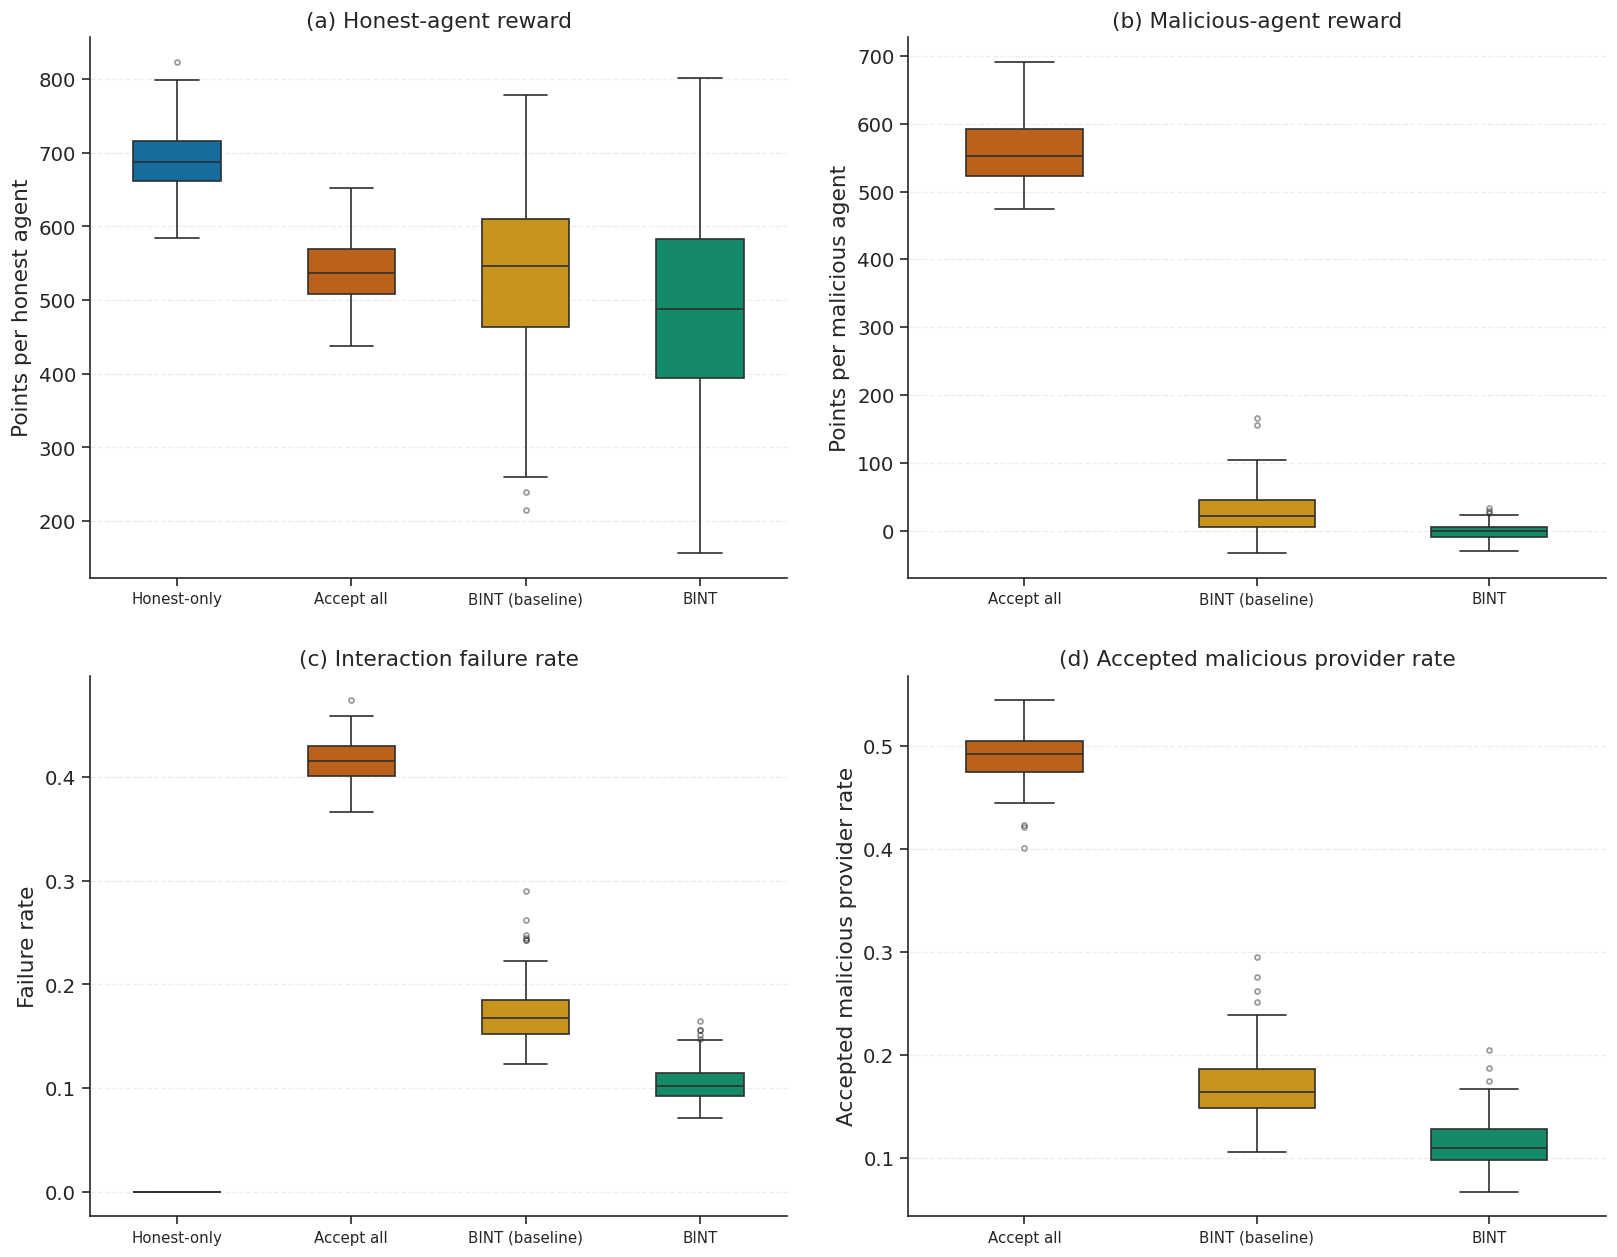

In [35]:
# ── Figure 1: Mechanism ablation summary (2×2) ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=FIG_2X2)
axes = axes.flatten()

scenario_boxplot(
    axes[0], abl_final, "points_per_honest_agent",
    ylabel="Points per honest agent",
    title="(a) Honest-agent reward",
)
scenario_boxplot(
    axes[1],
    abl_final[abl_final["malicious_agents"] > 0],
    "points_per_malicious_agent",
    ylabel="Points per malicious agent",
    title="(b) Malicious-agent reward",
)
scenario_boxplot(
    axes[2], abl_final, "failure_rate",
    ylabel="Failure rate",
    title="(c) Interaction failure rate",
)
scenario_boxplot(
    axes[3],
    abl_final[abl_final["malicious_agents"] > 0],
    "accepted_malicious_rate",
    ylabel="Accepted malicious provider rate",
    title="(d) Accepted malicious provider rate",
)

fig.tight_layout(pad=2.0)
save_figure("fig1_ablation_2x2.pdf")
plt.show()

**Figure interpretation**: The ablation 2×2 shows the mechanism layers.
Panel (a): honest-agent rewards are highest in BINT (490 pts) but surprisingly
similar to Accept-all (477 pts), because reduced interaction volume is offset
by higher per-interaction success. Panel (b): the key result — malicious agents earn *negative* expected points
in full BINT (−4 pts/agent). **Important**: these negative points arise from
late-delivery penalties on wrong-coordinate deliveries — BINT filters out
malicious providers, so they receive bad map data and waste steps on fruitless
routes. TNFT burns reduce future trust capital but do not directly subtract
from points. The claim of economic irrationality holds for the delivery-points
utility function, and is further strengthened if token capital is valued. Panel (c): BINT reduces the failure rate by ~80% vs Accept-all
(0.10 vs 0.50). Panel (d): the malicious provider acceptance rate falls by ~81%
(0.11 vs 0.59), showing the trust mechanism correctly gates on agent quality.

Saved: fig2_safety_performance_tradeoff.pdf + fig2_safety_performance_tradeoff.svg


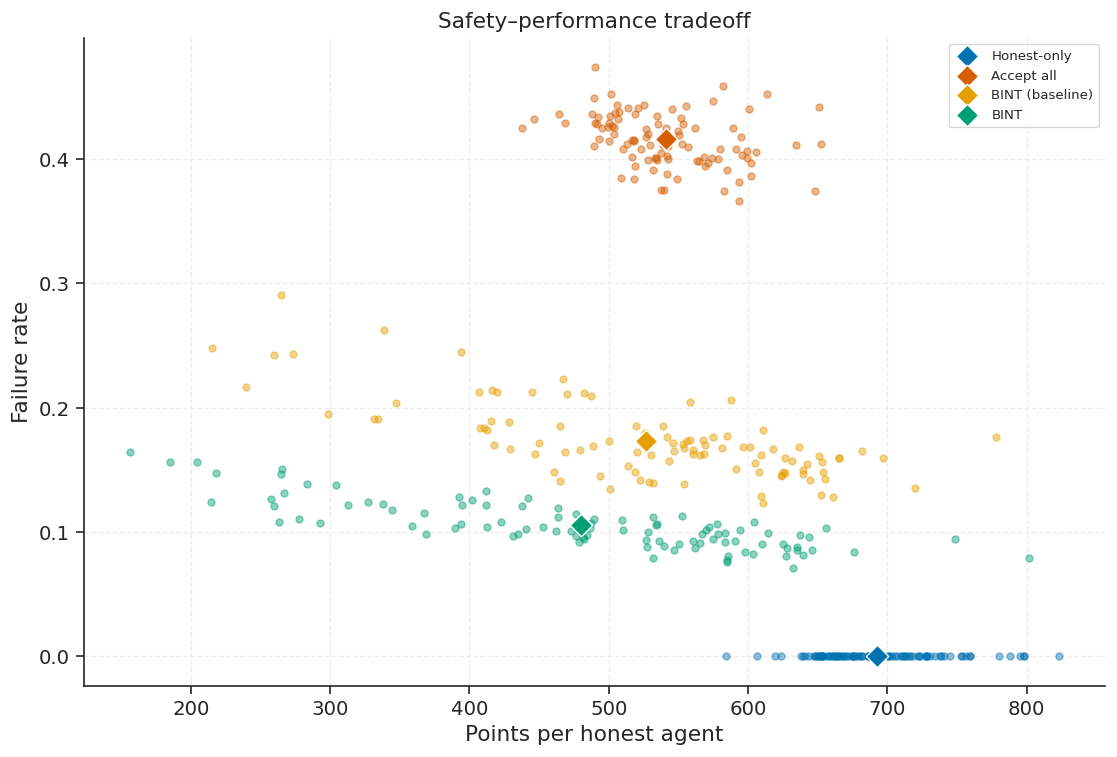

Mann-Whitney p-values for failure_rate:
  Honest-only vs Accept all: p=0.0000 ***
  Honest-only vs BINT (baseline): p=0.0000 ***
  Honest-only vs BINT: p=0.0000 ***
  Accept all vs BINT (baseline): p=0.0000 ***
  Accept all vs BINT: p=0.0000 ***
  BINT (baseline) vs BINT: p=0.0000 ***


In [36]:
# ── Figure 2: Safety–performance tradeoff scatter ────────────────────────────
fig, ax = plt.subplots(figsize=FIG_SINGLE)

for cfg in SCENARIO_ORDER:
    sub = abl_final[abl_final["config"] == cfg].dropna(
        subset=["points_per_honest_agent", "failure_rate"]
    )
    if sub.empty:
        continue
    color = SCENARIO_COLORS[cfg]
    label = SCENARIO_LABELS[cfg]
    ax.scatter(
        sub["points_per_honest_agent"], sub["failure_rate"],
        color=color, alpha=0.45, s=18, zorder=2,
    )
    ax.scatter(
        sub["points_per_honest_agent"].mean(), sub["failure_rate"].mean(),
        color=color, marker="D", s=90, zorder=3,
        edgecolors="white", linewidths=0.8, label=label,
    )

ax.set_xlabel("Points per honest agent")
ax.set_ylabel("Failure rate")
ax.set_title("Safety–performance tradeoff")
ax.legend(fontsize=8, framealpha=0.8)
sns.despine(ax=ax)
fig.tight_layout()
save_figure("fig2_safety_performance_tradeoff.pdf")
plt.show()

# Print significance
print("Mann-Whitney p-values for failure_rate:")
adv = [c for c in SCENARIO_ORDER if c in abl_final["config"].unique()]
for (a, b), p in pairwise_mw(abl_final, "failure_rate", adv).items():
    print(f"  {SCENARIO_LABELS[a]} vs {SCENARIO_LABELS[b]}: p={p:.4f} {sig_label(p)}")

## BINT mechanism walkthrough

The four panels below show the complete causal chain of the BINT mechanism
unfolding over 5,000 simulation steps. Read left-to-right, top-to-bottom:

1. **(a) Honest reward**: in Accept-all, honest agents earn ~477 pts/agent by end;
   BINT lifts this to ~490 despite fewer interactions because failures are avoided.
2. **(b) Malicious reward**: without filtering, malicious agents earn as much as
   honest ones; BINT (baseline) cuts this to ~16 pts; full BINT drives it negative.
3. **(c) Trust separation**: the trust gap (honest − malicious score) grows over
   time as honest agents accumulate TNFTs and malicious agents lose them.
4. **(d) Filtering effect**: the malicious provider acceptance rate falls as trust
   scores diverge. The downward slope shows the mechanism converging over time.

The key insight: panels (c) and (d) are the mechanism; panels (a) and (b) are
the outcome. BINT creates a self-reinforcing feedback loop.

Saved: fig_mechanism_walkthrough.pdf + fig_mechanism_walkthrough.svg


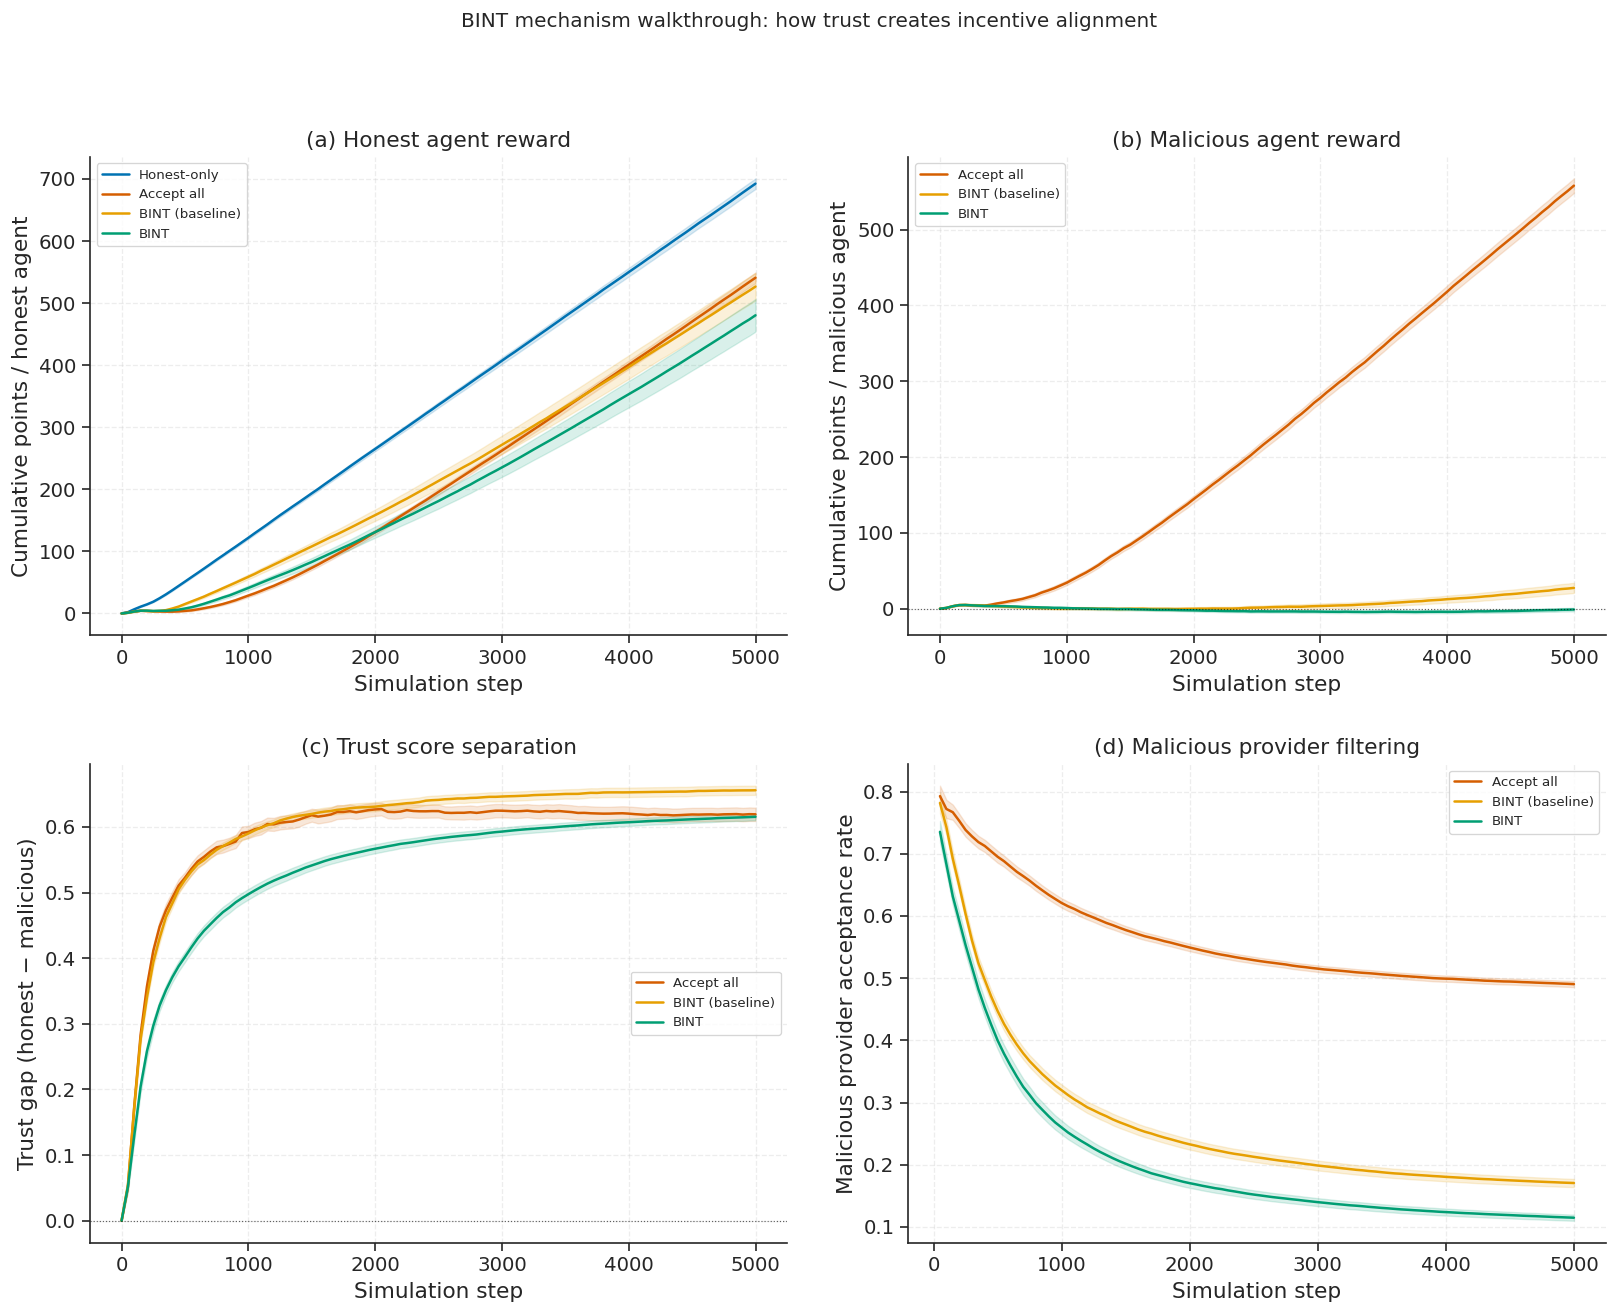

In [37]:
# ── Figure: BINT mechanism walkthrough (4-panel) ─────────────────────────────
# The complete causal chain: trust diverges → malicious providers rejected →
# TNFTs burned → malicious points fall → trust diverges further.

_adv = [c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"]

fig, axes = plt.subplots(2, 2, figsize=FIG_2X2)

# (a) Honest agent reward over time
ci_lineplot(axes[0, 0], abl_traj,
            y="points_per_honest_agent",
            configs=SCENARIO_ORDER,
            ylabel="Cumulative points / honest agent",
            title="(a) Honest agent reward")

# (b) Malicious agent reward over time
_traj_adv = abl_traj[abl_traj["malicious_agents"] > 0]
ci_lineplot(axes[0, 1], _traj_adv,
            y="points_per_malicious_agent",
            configs=_adv,
            ylabel="Cumulative points / malicious agent",
            title="(b) Malicious agent reward")
axes[0, 1].axhline(0, color="black", linewidth=0.7, linestyle=":", alpha=0.6)

# (c) Trust gap over time
ci_lineplot(axes[1, 0], _traj_adv,
            y="trust_gap_honest_minus_malicious",
            configs=_adv,
            ylabel="Trust gap (honest − malicious)",
            title="(c) Trust score separation")
axes[1, 0].axhline(0, color="black", linewidth=0.7, linestyle=":", alpha=0.6)

# (d) Malicious provider acceptance rate over time
ci_lineplot(axes[1, 1], _traj_adv,
            y="accepted_malicious_rate",
            configs=_adv,
            ylabel="Malicious provider acceptance rate",
            title="(d) Malicious provider filtering")

fig.suptitle("BINT mechanism walkthrough: how trust creates incentive alignment",
             y=1.01, fontsize=12)
fig.tight_layout(pad=2.0)
save_figure("fig_mechanism_walkthrough.pdf")
plt.show()

## Marginal earning rate over time

The mechanism walkthrough shows cumulative points — always rising. This
figure shows the **marginal earning rate**: points earned per simulation step.

In **Accept-all** the rate is roughly flat — malicious providers cause a
constant stream of failed deliveries throughout the run. In **BINT** the rate
should *accelerate*: early steps are noisy (little trust evidence), but as
honest agents accumulate TNFTs and malicious agents' scores fall, the
filter becomes more precise and each step yields more successful deliveries.

A rising rate is direct evidence of the self-reinforcing feedback loop.

Saved: fig_earning_rate_over_time.pdf + fig_earning_rate_over_time.svg


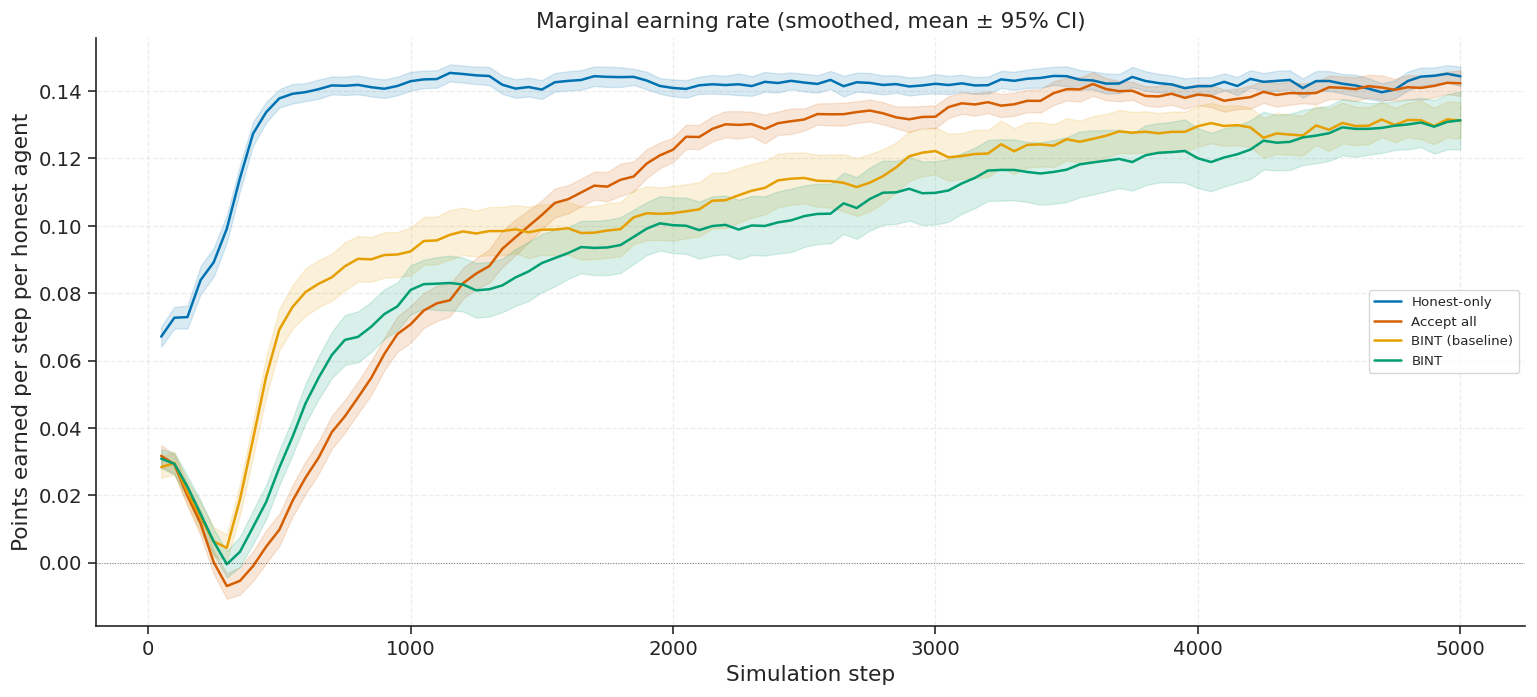

Early vs late earning rate (pts/step/honest agent):
  Accept all          : early=0.0278, late=0.1401, change=+0.1124
  BINT (baseline)     : early=0.0575, late=0.1296, change=+0.0721
  BINT                : early=0.0399, late=0.1268, change=+0.0869
  Honest-only         : early=0.1204, late=0.1426, change=+0.0221


In [38]:
# ── Figure: Marginal earning rate over time ────────────────────────────────────
# d(points_per_honest_agent) / d(sim_step) — computed from successive snapshots.
# Smoothed with a rolling window to reduce collection-point noise.

_er = (
    abl_traj
    .sort_values(["config", "seed", "sim_step"])
    .copy()
)
_er["delta_pts"]  = _er.groupby(["config","seed"])["points_per_honest_agent"].diff()
_er["delta_step"] = _er.groupby(["config","seed"])["sim_step"].diff()
_er["earn_rate"]  = safe_div(_er["delta_pts"], _er["delta_step"])
_er = _er.dropna(subset=["earn_rate", "delta_step"])

# Rolling smooth per (config, seed) — window of 4 collection points
_smooth_parts = []
for (_cfg, _sd), _grp in _er.groupby(["config","seed"]):
    _tmp = _grp.sort_values("sim_step").copy()
    _tmp["earn_rate_smooth"] = _tmp["earn_rate"].rolling(4, min_periods=1, center=True).mean()
    _smooth_parts.append(_tmp)
_er = pd.concat(_smooth_parts, ignore_index=True)

fig, ax = plt.subplots(figsize=FIG_WIDE)
ci_lineplot(ax, _er, y="earn_rate_smooth", configs=SCENARIO_ORDER,
            ylabel="Points earned per step per honest agent",
            title="Marginal earning rate (smoothed, mean \u00b1 95% CI)")
ax.axhline(0, color="black", linewidth=0.6, linestyle=":", alpha=0.5)
fig.tight_layout()
save_figure("fig_earning_rate_over_time.pdf")
plt.show()

# Early (first 20% of steps) vs late (last 20%) comparison
_q20 = _er["sim_step"].quantile(0.20)
_q80 = _er["sim_step"].quantile(0.80)
print("Early vs late earning rate (pts/step/honest agent):")
for _cfg, _g in _er.groupby("config"):
    _early = _g[_g["sim_step"] <= _q20]["earn_rate_smooth"].mean()
    _late  = _g[_g["sim_step"] >= _q80]["earn_rate_smooth"].mean()
    print(f"  {SCENARIO_LABELS.get(_cfg,_cfg):20s}: "
          f"early={_early:.4f}, late={_late:.4f}, "
          f"change={_late-_early:+.4f}")

## Malicious damage rate and per-agent outcomes

Saved: fig_malicious_damage_rate.pdf + fig_malicious_damage_rate.svg


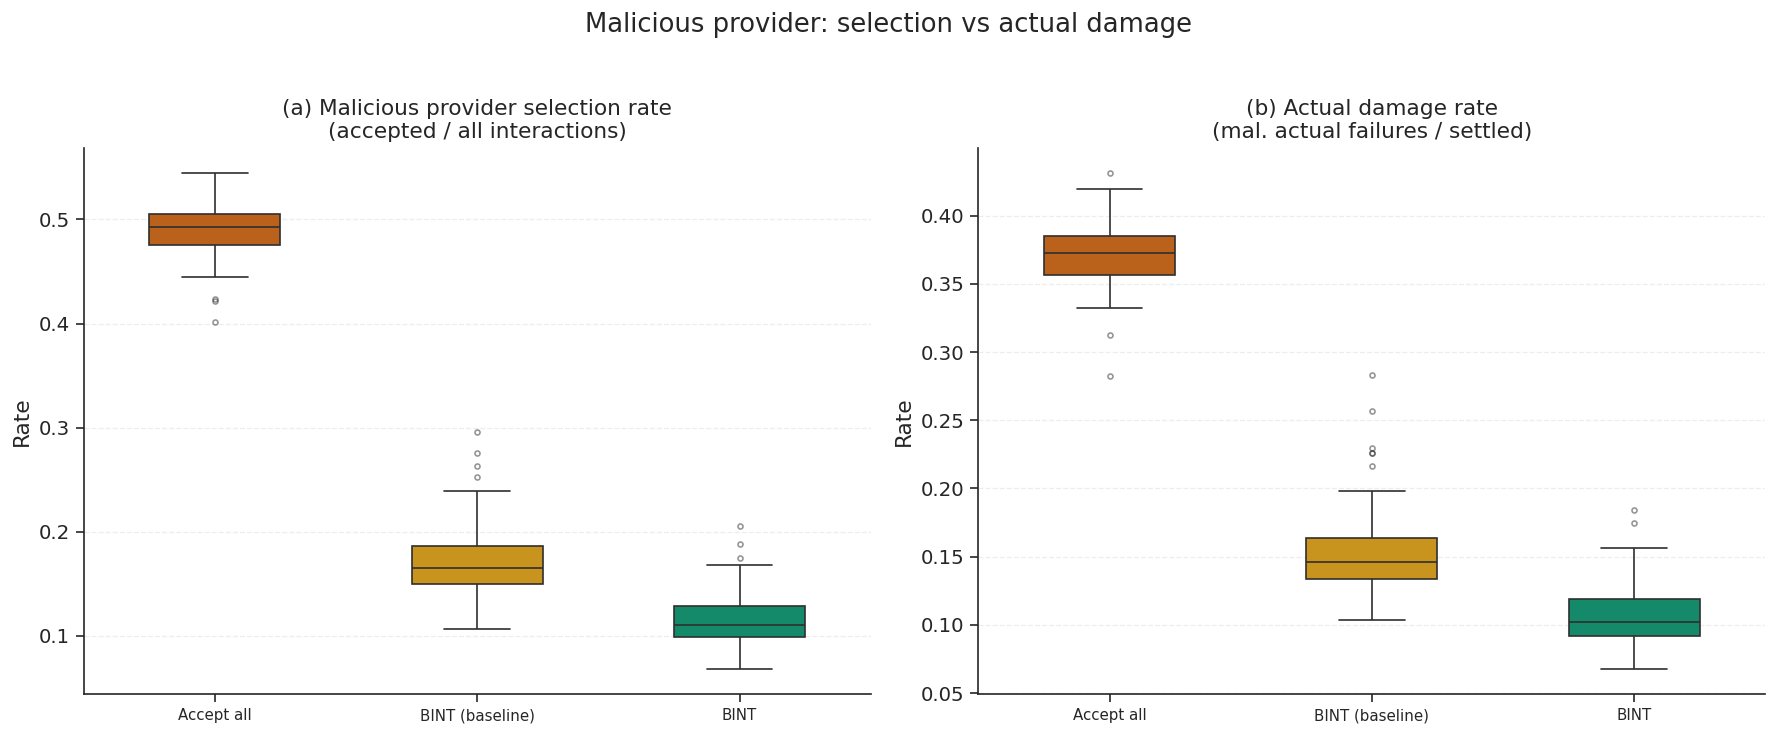

Selection vs damage (means):
  Accept all: selection=0.490, damage=0.371, ratio=0.76
  BINT (baseline): selection=0.171, damage=0.153, ratio=0.90
  BINT: selection=0.115, damage=0.106, ratio=0.93


In [39]:
# ── Figure: Malicious provider selection vs actual damage ─────────────────────
# accepted_malicious_rate: fraction of interactions with malicious provider selected.
# malicious_damage_rate:   fraction of settled interactions where malicious provider
#                          ACTUALLY caused failure (from actual_outcome_status, not reported).
# These differ when BINT partially suppresses malicious providers.

_msnap = abl_snap[(abl_snap["agent_type"] == "malicious") &
                  (abl_snap["provided_interactions"] > 0)].copy()
_msnap["actual_failures"] = (
    _msnap["provided_interactions"] * (1.0 - _msnap["actual_reliability"].fillna(1.0))
)
_dmg = (
    _msnap.groupby(["config", "seed"])["actual_failures"]
    .sum().reset_index()
    .rename(columns={"actual_failures": "mal_actual_failures"})
)
_dmg = _dmg.merge(
    abl_final[["config","seed","settled_interactions","accepted_malicious_rate"]],
    on=["config","seed"], how="left")
_dmg["malicious_damage_rate"] = safe_div(_dmg["mal_actual_failures"],
                                          _dmg["settled_interactions"])
_dmg = add_scenario_labels(_dmg)
_dmg_adv = _dmg[_dmg["config"] != "honest_only_upper_bound"]

fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL)
scenario_boxplot(axes[0], _dmg_adv, "accepted_malicious_rate",
                 ylabel="Rate",
                 title="(a) Malicious provider selection rate\n(accepted / all interactions)")
scenario_boxplot(axes[1], _dmg_adv, "malicious_damage_rate",
                 ylabel="Rate",
                 title="(b) Actual damage rate\n(mal. actual failures / settled)")
fig.suptitle("Malicious provider: selection vs actual damage", y=1.02)
fig.tight_layout()
save_figure("fig_malicious_damage_rate.pdf")
plt.show()

print("Selection vs damage (means):")
for _cfg, _g in _dmg_adv.groupby("config"):
    _a = _g["accepted_malicious_rate"].mean()
    _d = _g["malicious_damage_rate"].mean()
    print(f"  {SCENARIO_LABELS.get(_cfg,_cfg)}: "
          f"selection={_a:.3f}, damage={_d:.3f}, "
          f"ratio={(_d/_a if _a>0 else float('nan')):.2f}")

Saved: fig_agent_trust_vs_points.pdf + fig_agent_trust_vs_points.svg


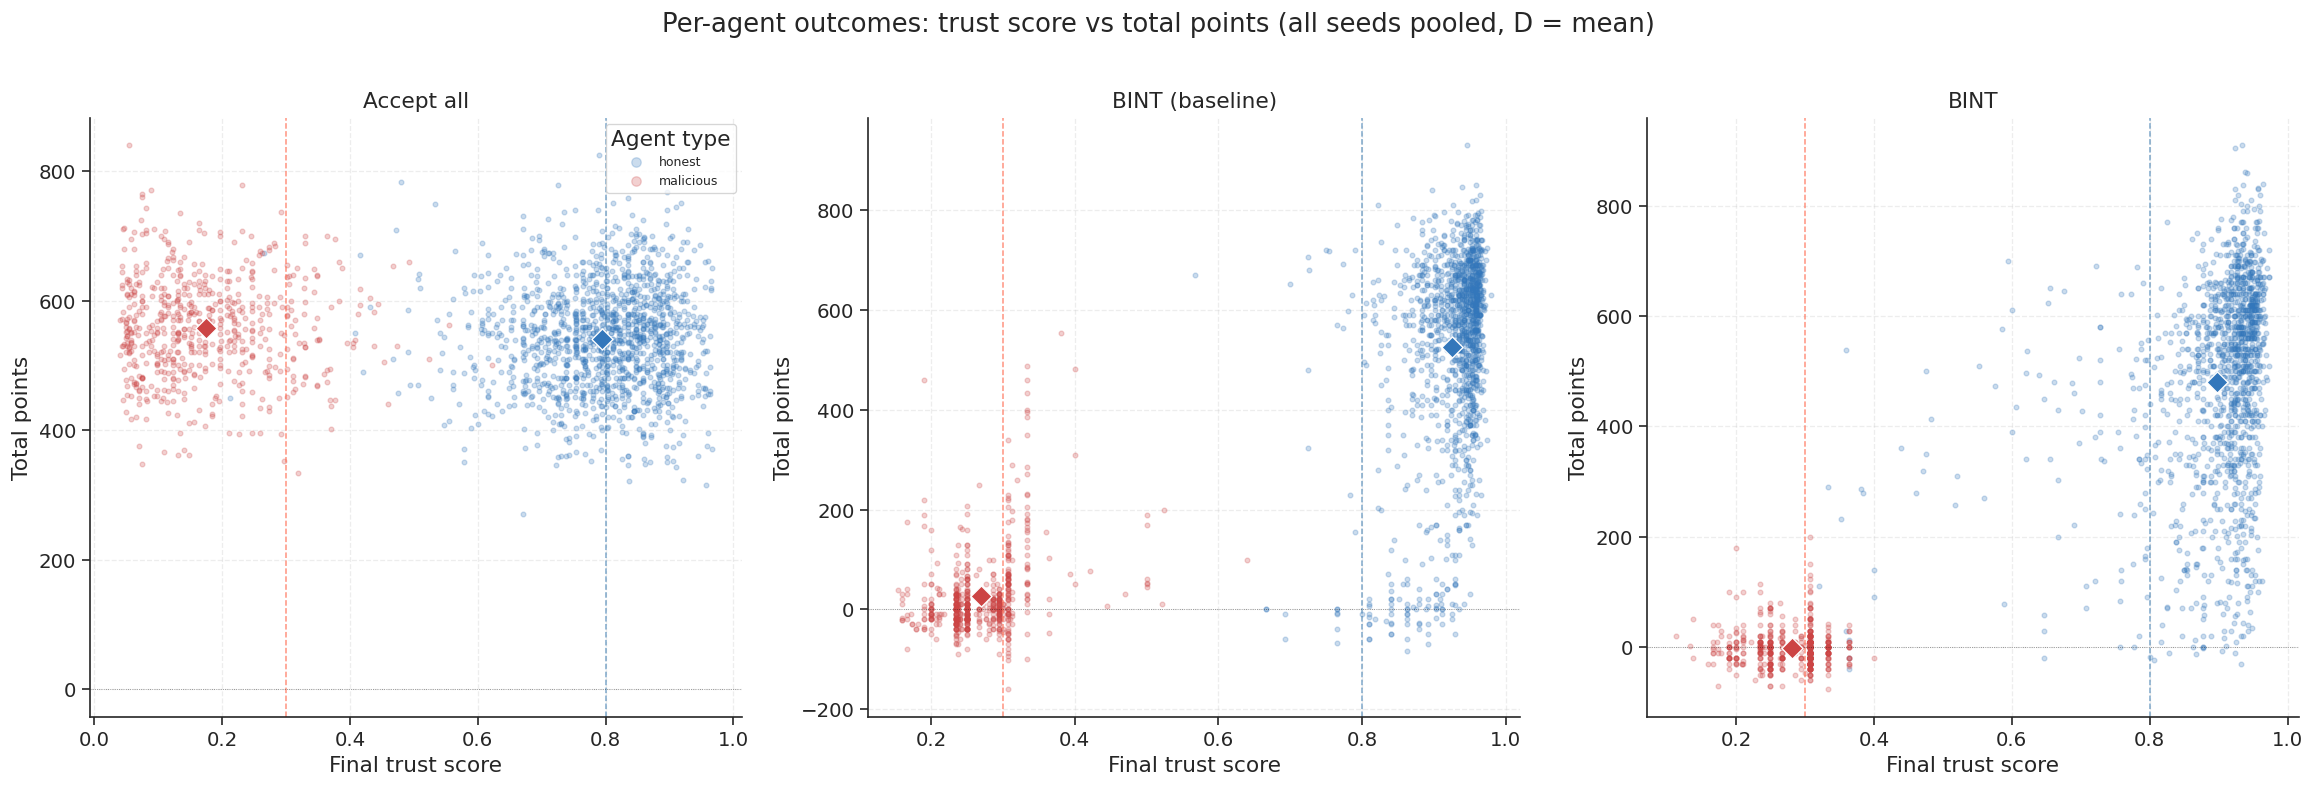

In [40]:
# ── Figure: Per-agent trust score vs total points (all seeds pooled) ──────────
# Honest agents should cluster: high trust / high points.
# Malicious agents should cluster: low trust / low or negative points.
# BINT should widen the separation between the two clusters vs Accept all.

_adv_s = [s for s in SCENARIO_ORDER if s != "honest_only_upper_bound"
           and s in abl_snap["config"].unique()]
fig, axes = plt.subplots(1, len(_adv_s), figsize=(6.5 * len(_adv_s), 6.5))
if len(_adv_s) == 1: axes = [axes]
_TC = {"honest": "#3377bb", "malicious": "#cc4444"}

for ax, _cfg in zip(axes, _adv_s):
    _sub = abl_snap[abl_snap["config"] == _cfg].dropna(subset=["final_trust_score","points"])
    for _atype, _grp in _sub.groupby("agent_type"):
        ax.scatter(_grp["final_trust_score"], _grp["points"],
                   color=_TC.get(_atype,"grey"), alpha=0.25, s=8, label=_atype)
        # Show mean as large marker
        ax.scatter(_grp["final_trust_score"].mean(), _grp["points"].mean(),
                   color=_TC.get(_atype,"grey"), marker="D", s=80,
                   edgecolors="white", linewidths=0.8, zorder=4)
    ax.axvline(FINAL_BASE_PARAMETERS["trust_reject_threshold"],
               color="tomato",   linestyle="--", linewidth=0.9, alpha=0.7)
    ax.axvline(FINAL_BASE_PARAMETERS["trust_accept_threshold"],
               color="steelblue", linestyle="--", linewidth=0.9, alpha=0.7)
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":", alpha=0.5)
    ax.set_title(SCENARIO_LABELS.get(_cfg, _cfg))
    ax.set_xlabel("Final trust score")
    ax.set_ylabel("Total points")
    sns.despine(ax=ax)

axes[0].legend(title="Agent type", fontsize=7.5, markerscale=2)
fig.suptitle("Per-agent outcomes: trust score vs total points (all seeds pooled, D = mean)", y=1.01)
fig.tight_layout()
save_figure("fig_agent_trust_vs_points.pdf")
plt.show()

## Section 16–18 — Trust mechanism

Saved: fig3_trust_gap_over_time.pdf + fig3_trust_gap_over_time.svg


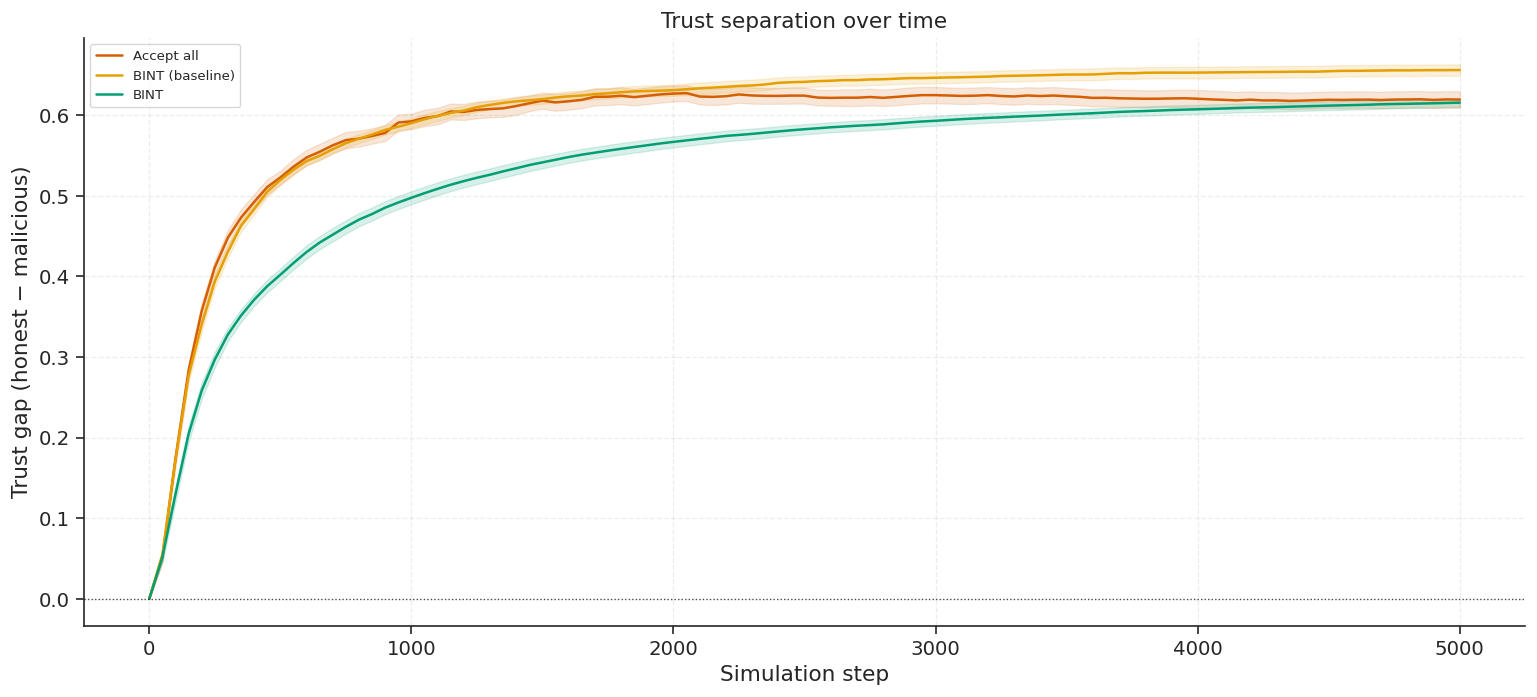

In [41]:
# ── Figure 3: Trust gap over time (mean ± 95% CI) ───────────────────────────
adv_configs = [c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"]

fig, ax = plt.subplots(figsize=FIG_WIDE)
ci_lineplot(
    ax, abl_traj,
    y="trust_gap_honest_minus_malicious",
    configs=adv_configs,
    ylabel="Trust gap (honest − malicious)",
    title="Trust separation over time",
)
ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.7)
fig.tight_layout()
save_figure("fig3_trust_gap_over_time.pdf")
plt.show()

**Figure interpretation**: The trust gap between honest and malicious agents
grows from zero (at genesis, when all agents have only bootstrap tokens) and
converges to a stable positive value. The gap is consistent across all
adversarial scenarios, confirming that the trust mechanism correctly
distinguishes agent types regardless of staking. The gap in Accept-all
(yellow) grows naturally — trust scores are computed even when they are not
used for decisions — confirming the signal quality of the TNFT mechanism.

Saved: fig4_trust_distributions_violin.pdf + fig4_trust_distributions_violin.svg


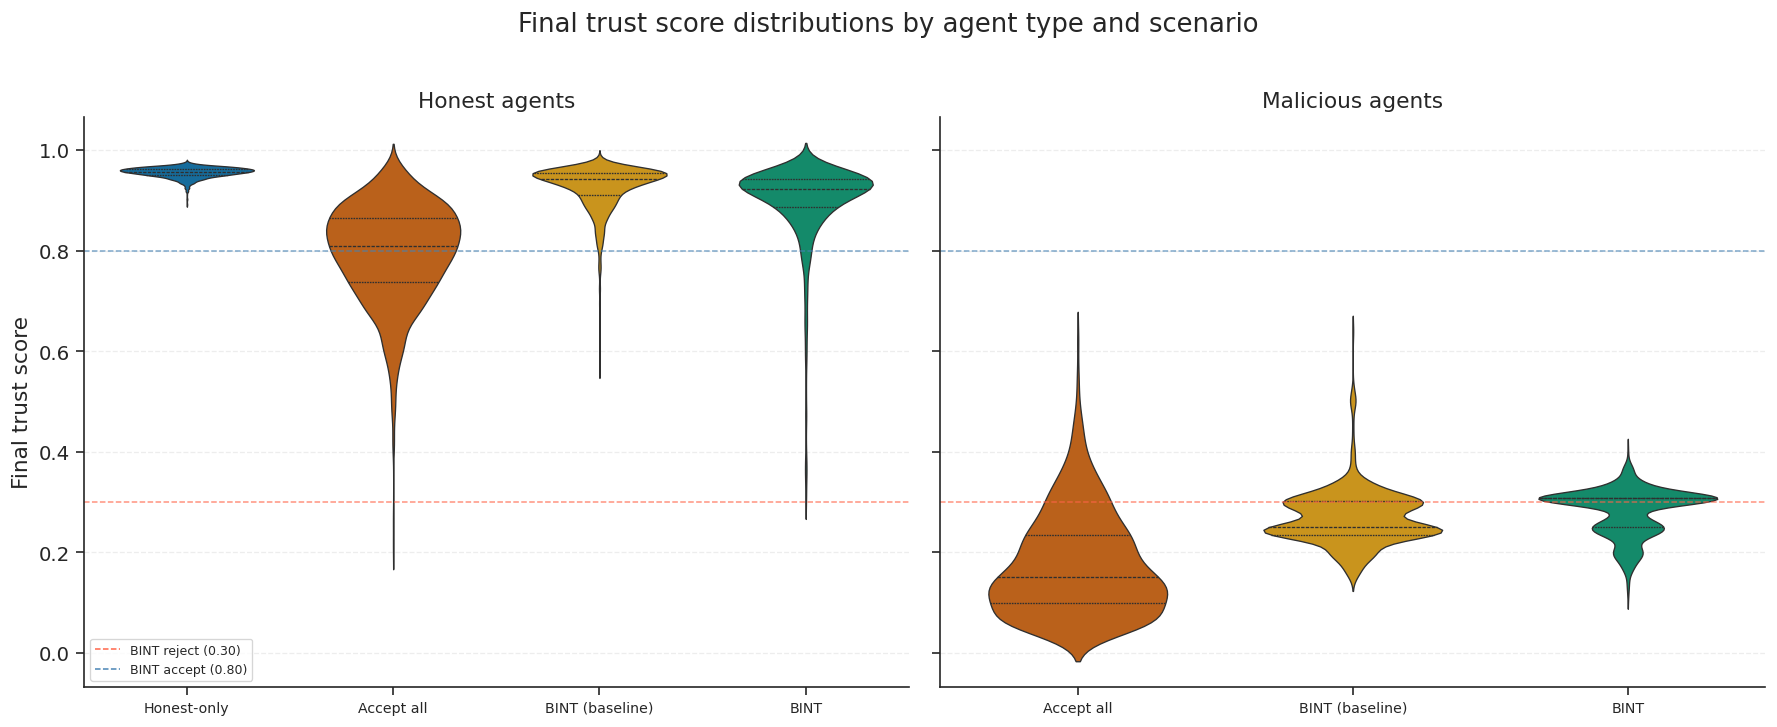

In [42]:
# ── Figure 4: Final trust score distributions (violin) ──────────────────────
# Two panels: honest agents (left) and malicious agents (right)
fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL, sharey=True)

adv_scenarios = [s for s in SCENARIO_ORDER if s != "honest_only_upper_bound"]

# Left panel: honest agents across all scenarios
honest_df = abl_snap[abl_snap["agent_type"] == "honest"].copy()
order_all  = [SCENARIO_LABELS[s] for s in SCENARIO_ORDER if s in honest_df["config"].unique()]
sns.violinplot(
    data=honest_df,
    x="scenario_label", y="final_trust_score",
    order=order_all,
    palette=LABEL_COLORS,
    inner="quart", linewidth=0.8, width=0.65,
    ax=axes[0],
)
axes[0].set_title("Honest agents")
axes[0].set_xlabel("")
axes[0].set_ylabel("Final trust score")
axes[0].tick_params(axis="x", labelsize=8.5)

# Right panel: malicious agents across adversarial scenarios
mal_df    = abl_snap[(abl_snap["agent_type"] == "malicious")].copy()
order_adv = [SCENARIO_LABELS[s] for s in adv_scenarios if s in mal_df["config"].unique()]
sns.violinplot(
    data=mal_df,
    x="scenario_label", y="final_trust_score",
    order=order_adv,
    palette=LABEL_COLORS,
    inner="quart", linewidth=0.8, width=0.65,
    ax=axes[1],
)
axes[1].set_title("Malicious agents")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", labelsize=8.5)

# Threshold lines apply to BINT scenarios (0.30/0.80) — NOT to Accept all (0.0/0.01).
for ax in axes:
    ax.axhline(FINAL_BASE_PARAMETERS["trust_reject_threshold"],
               color="tomato",  linestyle="--", linewidth=0.9, alpha=0.7)
    ax.axhline(FINAL_BASE_PARAMETERS["trust_accept_threshold"],
               color="steelblue", linestyle="--", linewidth=0.9, alpha=0.7)
    sns.despine(ax=ax)

from matplotlib.lines import Line2D
_thr = [
    Line2D([0],[0], color="tomato",   linestyle="--", linewidth=0.9,
           label=f'BINT reject ({FINAL_BASE_PARAMETERS["trust_reject_threshold"]:.2f})'),
    Line2D([0],[0], color="steelblue", linestyle="--", linewidth=0.9,
           label=f'BINT accept ({FINAL_BASE_PARAMETERS["trust_accept_threshold"]:.2f})'),
]
axes[0].legend(handles=_thr, fontsize=7.5, framealpha=0.8)
fig.suptitle("Final trust score distributions by agent type and scenario", y=1.01)
fig.tight_layout()
save_figure("fig4_trust_distributions_violin.pdf")
plt.show()

Saved: fig5_trust_vs_reliability_faceted.pdf + fig5_trust_vs_reliability_faceted.svg


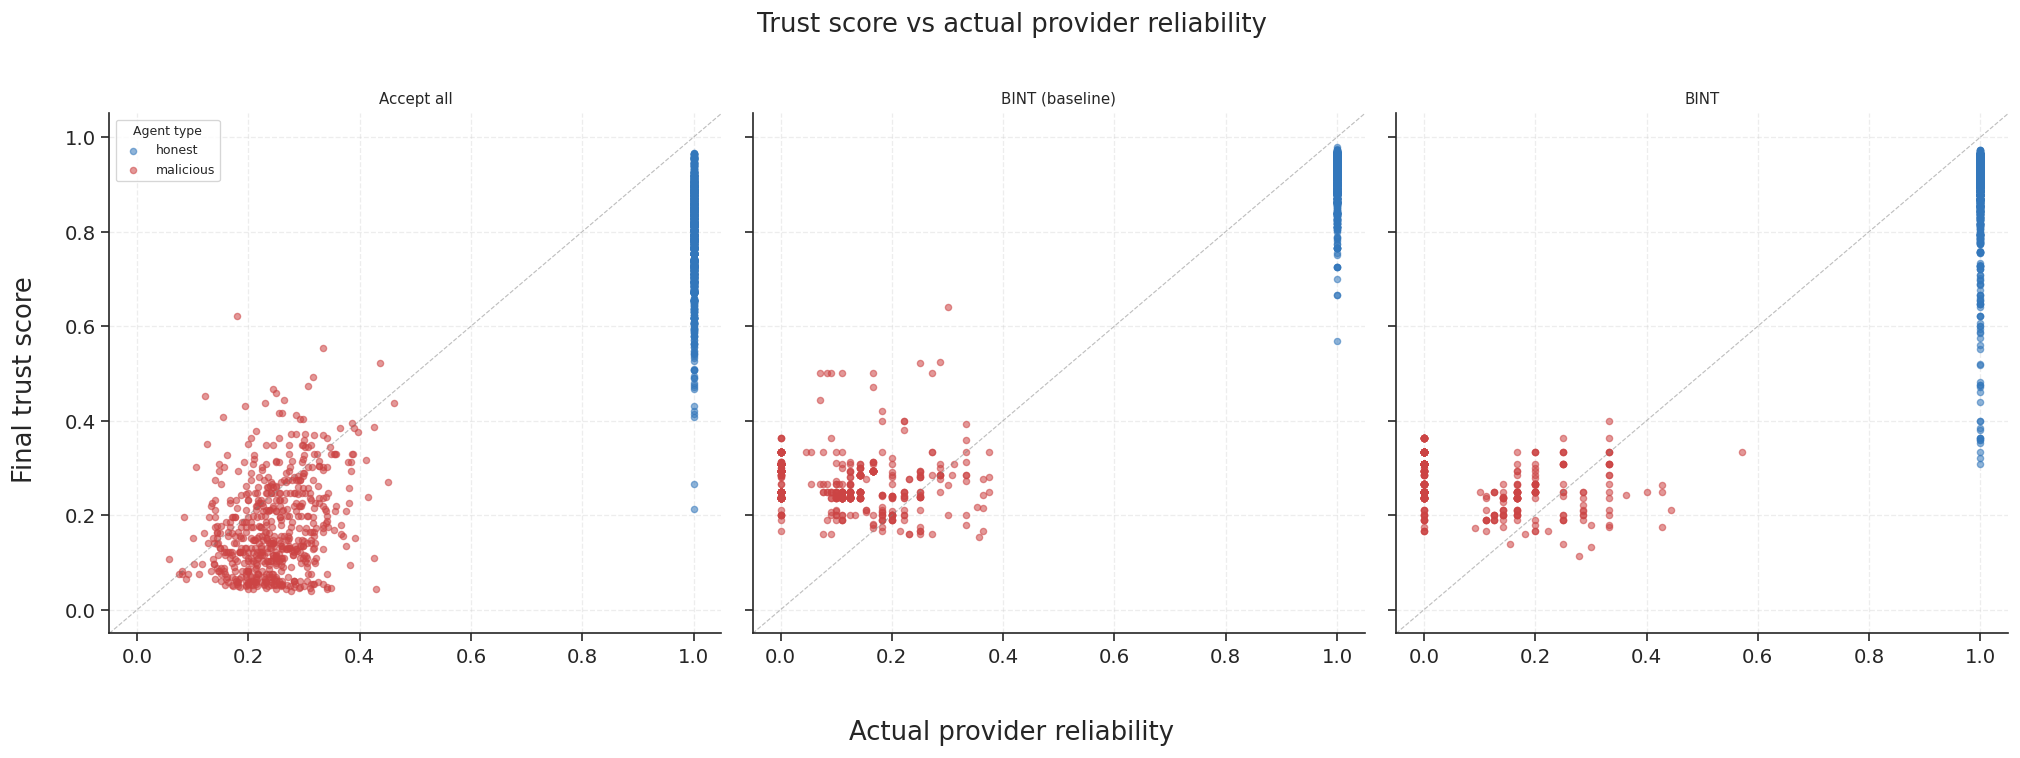

In [43]:
# ── Figure 5: Trust score vs actual provider reliability (faceted) ───────────
# One subplot per adversarial scenario, honest/malicious as two colors
adv_scenarios = [s for s in SCENARIO_ORDER if s != "honest_only_upper_bound"
                 and s in abl_snap["config"].unique()]

n_cols = 3
n_rows = int(np.ceil(len(adv_scenarios) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(17, 6.0 * n_rows), sharey=True, sharex=True)
axes = np.array(axes).flatten()

TYPE_COLORS = {"honest": "#3377bb", "malicious": "#cc4444"}

for ax, cfg in zip(axes, adv_scenarios):
    sub = abl_snap[(abl_snap["config"] == cfg) & (abl_snap["provided_interactions"] > 0)].copy()
    for atype, grp in sub.groupby("agent_type"):
        ax.scatter(
            grp["actual_reliability"],
            grp["final_trust_score"],
            color=TYPE_COLORS.get(atype, "grey"),
            alpha=0.55, s=14, label=atype,
        )
    ax.set_title(SCENARIO_LABELS[cfg], fontsize=9)
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
    ax.axline((0, 0), slope=1, color="grey", linewidth=0.7, linestyle="--", alpha=0.5)
    sns.despine(ax=ax)

# Hide unused subplot panels
for ax in axes[len(adv_scenarios):]:
    ax.set_visible(False)

axes[0].legend(title="Agent type", fontsize=7.5, title_fontsize=7.5)
fig.supxlabel("Actual provider reliability", y=-0.01)
fig.supylabel("Final trust score", x=0.01)
fig.suptitle("Trust score vs actual provider reliability", y=1.01)
fig.tight_layout()
save_figure("fig5_trust_vs_reliability_faceted.pdf")
plt.show()

## Section 19–20 — TNFT dynamics

Saved: fig6_tnft_balance_over_time.pdf + fig6_tnft_balance_over_time.svg


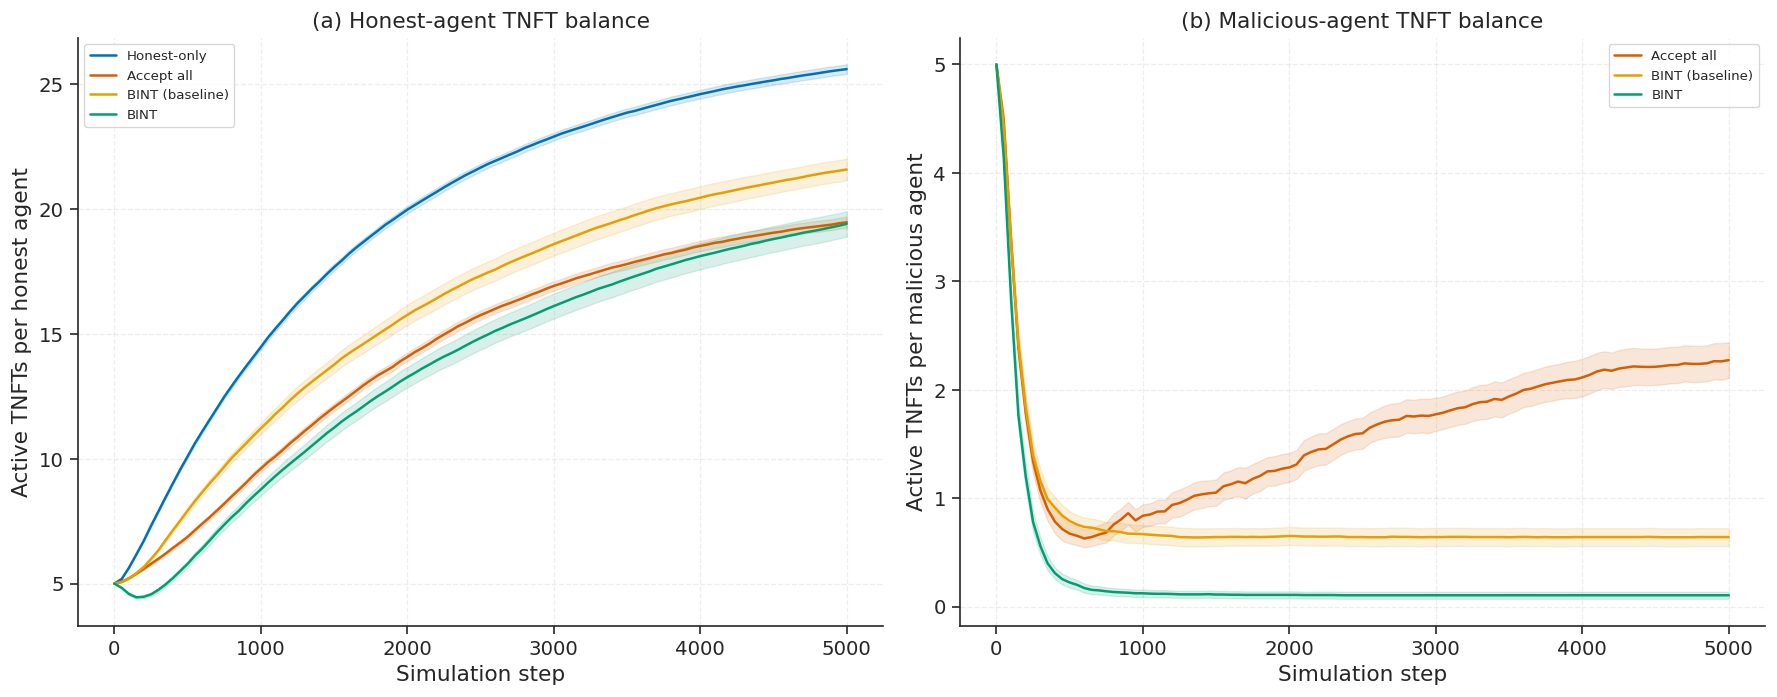

In [44]:
# ── Figure 6: Active TNFTs per agent type over time ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL, sharey=False)

# Left: honest agents (all scenarios)
ci_lineplot(
    axes[0], abl_traj,
    y="active_tnfts_per_honest",
    configs=SCENARIO_ORDER,
    ylabel="Active TNFTs per honest agent",
    title="(a) Honest-agent TNFT balance",
)

# Right: malicious agents (adversarial scenarios only)
ci_lineplot(
    axes[1],
    abl_traj[abl_traj["malicious_agents"] > 0],
    y="active_tnfts_per_malicious",
    configs=[c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"],
    ylabel="Active TNFTs per malicious agent",
    title="(b) Malicious-agent TNFT balance",
)

fig.tight_layout()
save_figure("fig6_tnft_balance_over_time.pdf")
plt.show()

Saved: fig7_burn_accumulation_over_time.pdf + fig7_burn_accumulation_over_time.svg


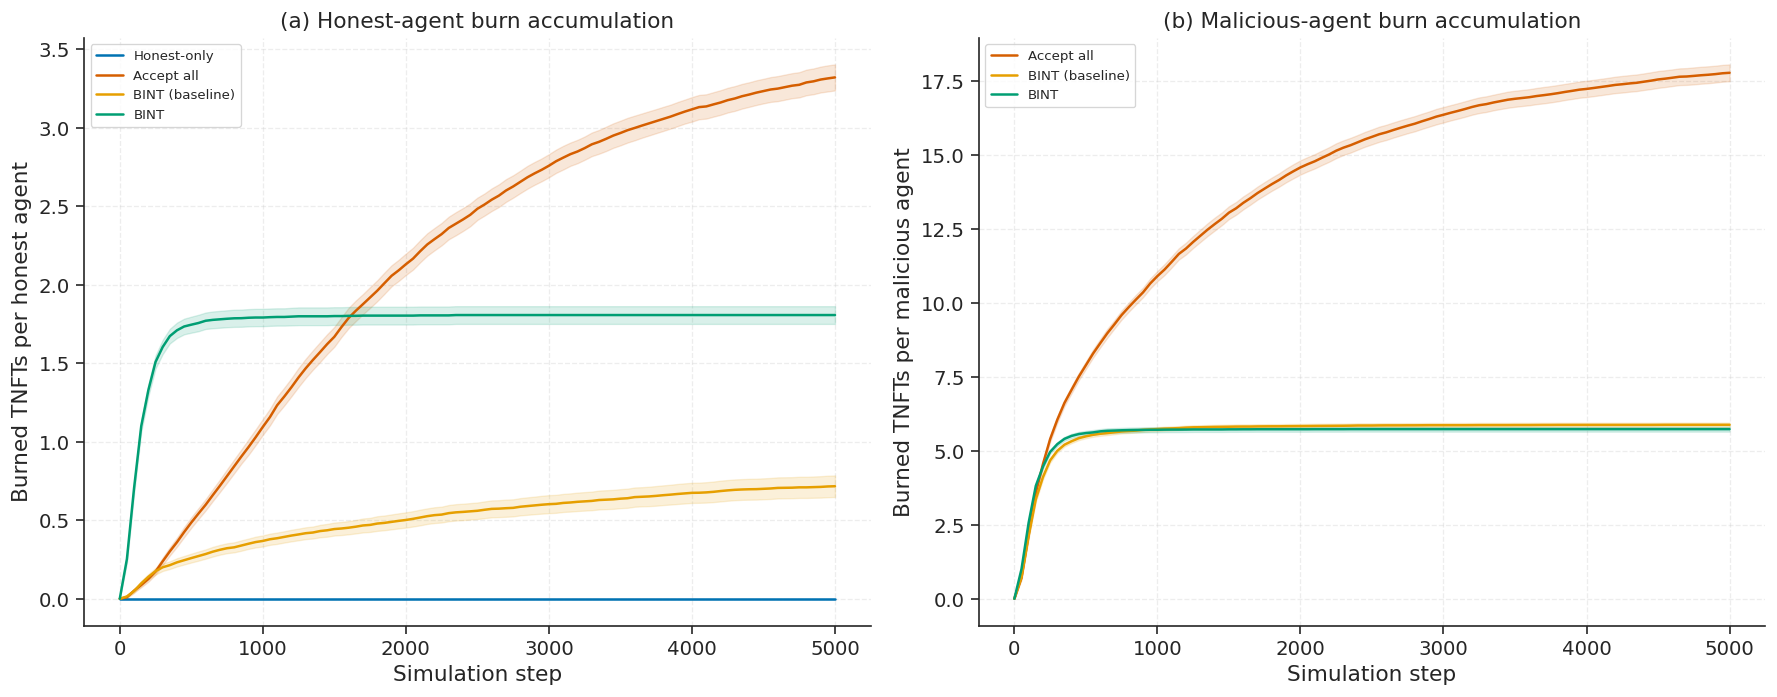

In [45]:
# ── Figure 7: Cumulative burns per agent type over time ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL)

ci_lineplot(
    axes[0], abl_traj,
    y="burned_tnfts_per_honest",
    configs=SCENARIO_ORDER,
    ylabel="Burned TNFTs per honest agent",
    title="(a) Honest-agent burn accumulation",
)

ci_lineplot(
    axes[1],
    abl_traj[abl_traj["malicious_agents"] > 0],
    y="burned_tnfts_per_malicious",
    configs=[c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"],
    ylabel="Burned TNFTs per malicious agent",
    title="(b) Malicious-agent burn accumulation",
)

fig.tight_layout()
save_figure("fig7_burn_accumulation_over_time.pdf")
plt.show()

## Delivery efficiency

**Important nuance**: BINT reduces the total number of interactions per agent
(from ~33 in Accept-all to ~13 in BINT), but each accepted interaction is more
likely to succeed. Does BINT improve the total number of deliveries, or does
the reduction in interaction volume dominate?

The figure below shows cumulative deliveries per honest agent over time.
A steeper slope means more frequent successful deliveries per agent.

Saved: fig_delivery_efficiency.pdf + fig_delivery_efficiency.svg


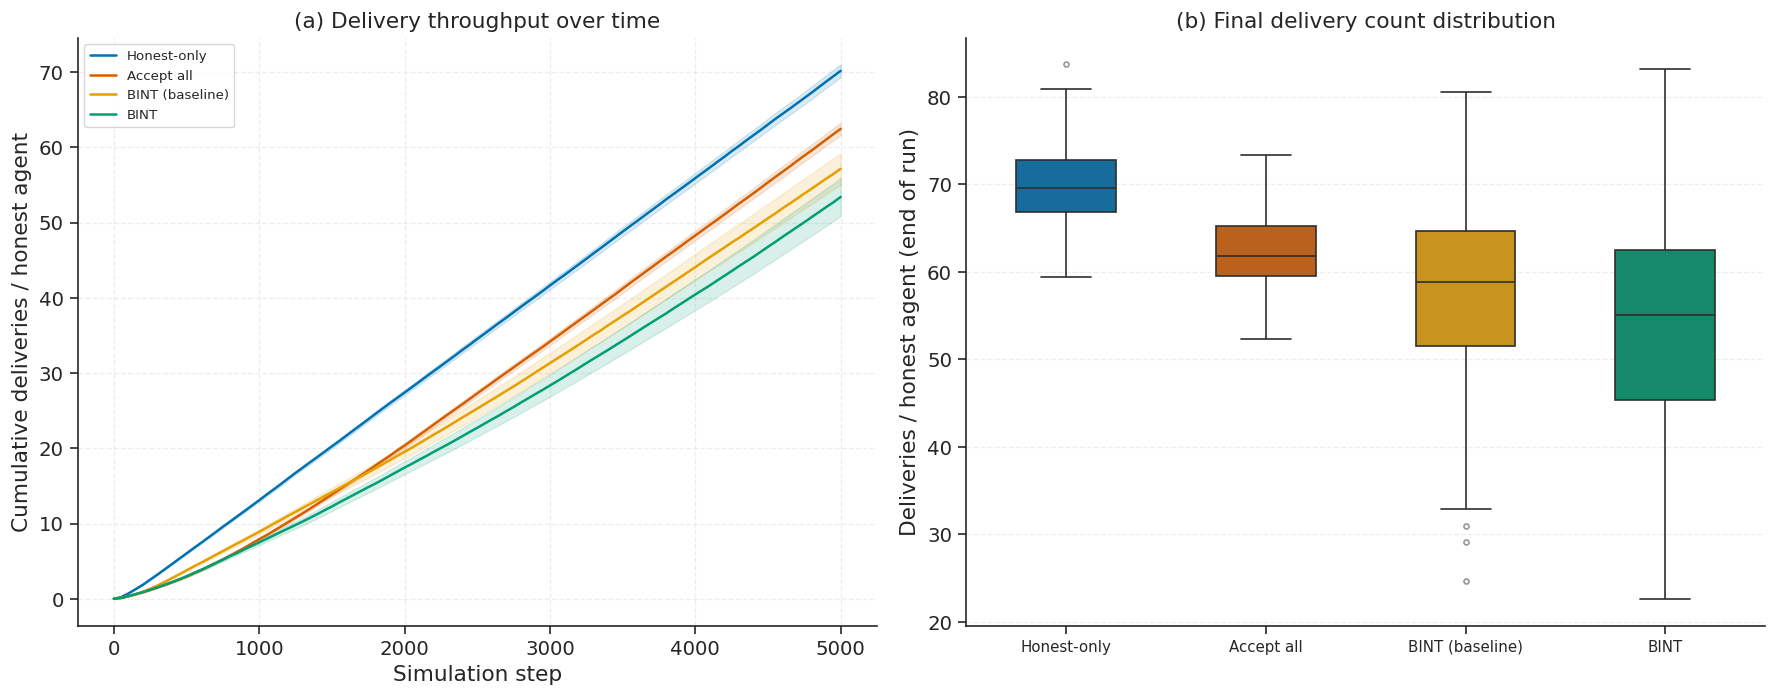

Delivery efficiency summary (means):
  Accept all: deliveries=62.4, pts/agent=540.9, pts/delivery=8.7
  BINT (baseline): deliveries=57.1, pts/agent=526.7, pts/delivery=9.2
  BINT: deliveries=53.4, pts/agent=480.4, pts/delivery=9.0
  Honest-only: deliveries=70.2, pts/agent=692.5, pts/delivery=9.9


In [46]:
# ── Figure: Delivery efficiency over time ────────────────────────────────────
# Cumulative deliveries per honest agent over time.
# This captures the net effect of BINT: higher success rate but fewer interactions.

fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL)

# Panel a: deliveries per honest agent over time
ci_lineplot(axes[0], abl_traj,
            y="deliveries_per_honest_agent",
            configs=SCENARIO_ORDER,
            ylabel="Cumulative deliveries / honest agent",
            title="(a) Delivery throughput over time")

# Panel b: final distribution
scenario_boxplot(axes[1], abl_final, "deliveries_per_honest_agent",
                 ylabel="Deliveries / honest agent (end of run)",
                 title="(b) Final delivery count distribution")

fig.tight_layout()
save_figure("fig_delivery_efficiency.pdf")
plt.show()

print("Delivery efficiency summary (means):")
for _cfg, _grp in abl_final.groupby("config"):
    _d = _grp["deliveries_per_honest_agent"].mean() if "deliveries_per_honest_agent" in _grp.columns else float("nan")
    _p = _grp["points_per_honest_agent"].mean()
    _pts_per_del = _p / _d if _d > 0 else float("nan")
    print(f"  {SCENARIO_LABELS.get(_cfg,_cfg)}: "
          f"deliveries={_d:.1f}, pts/agent={_p:.1f}, pts/delivery={_pts_per_del:.1f}")

## TNFT lifecycle — complete view

Saved: fig_tnft_lifecycle_complete.pdf + fig_tnft_lifecycle_complete.svg


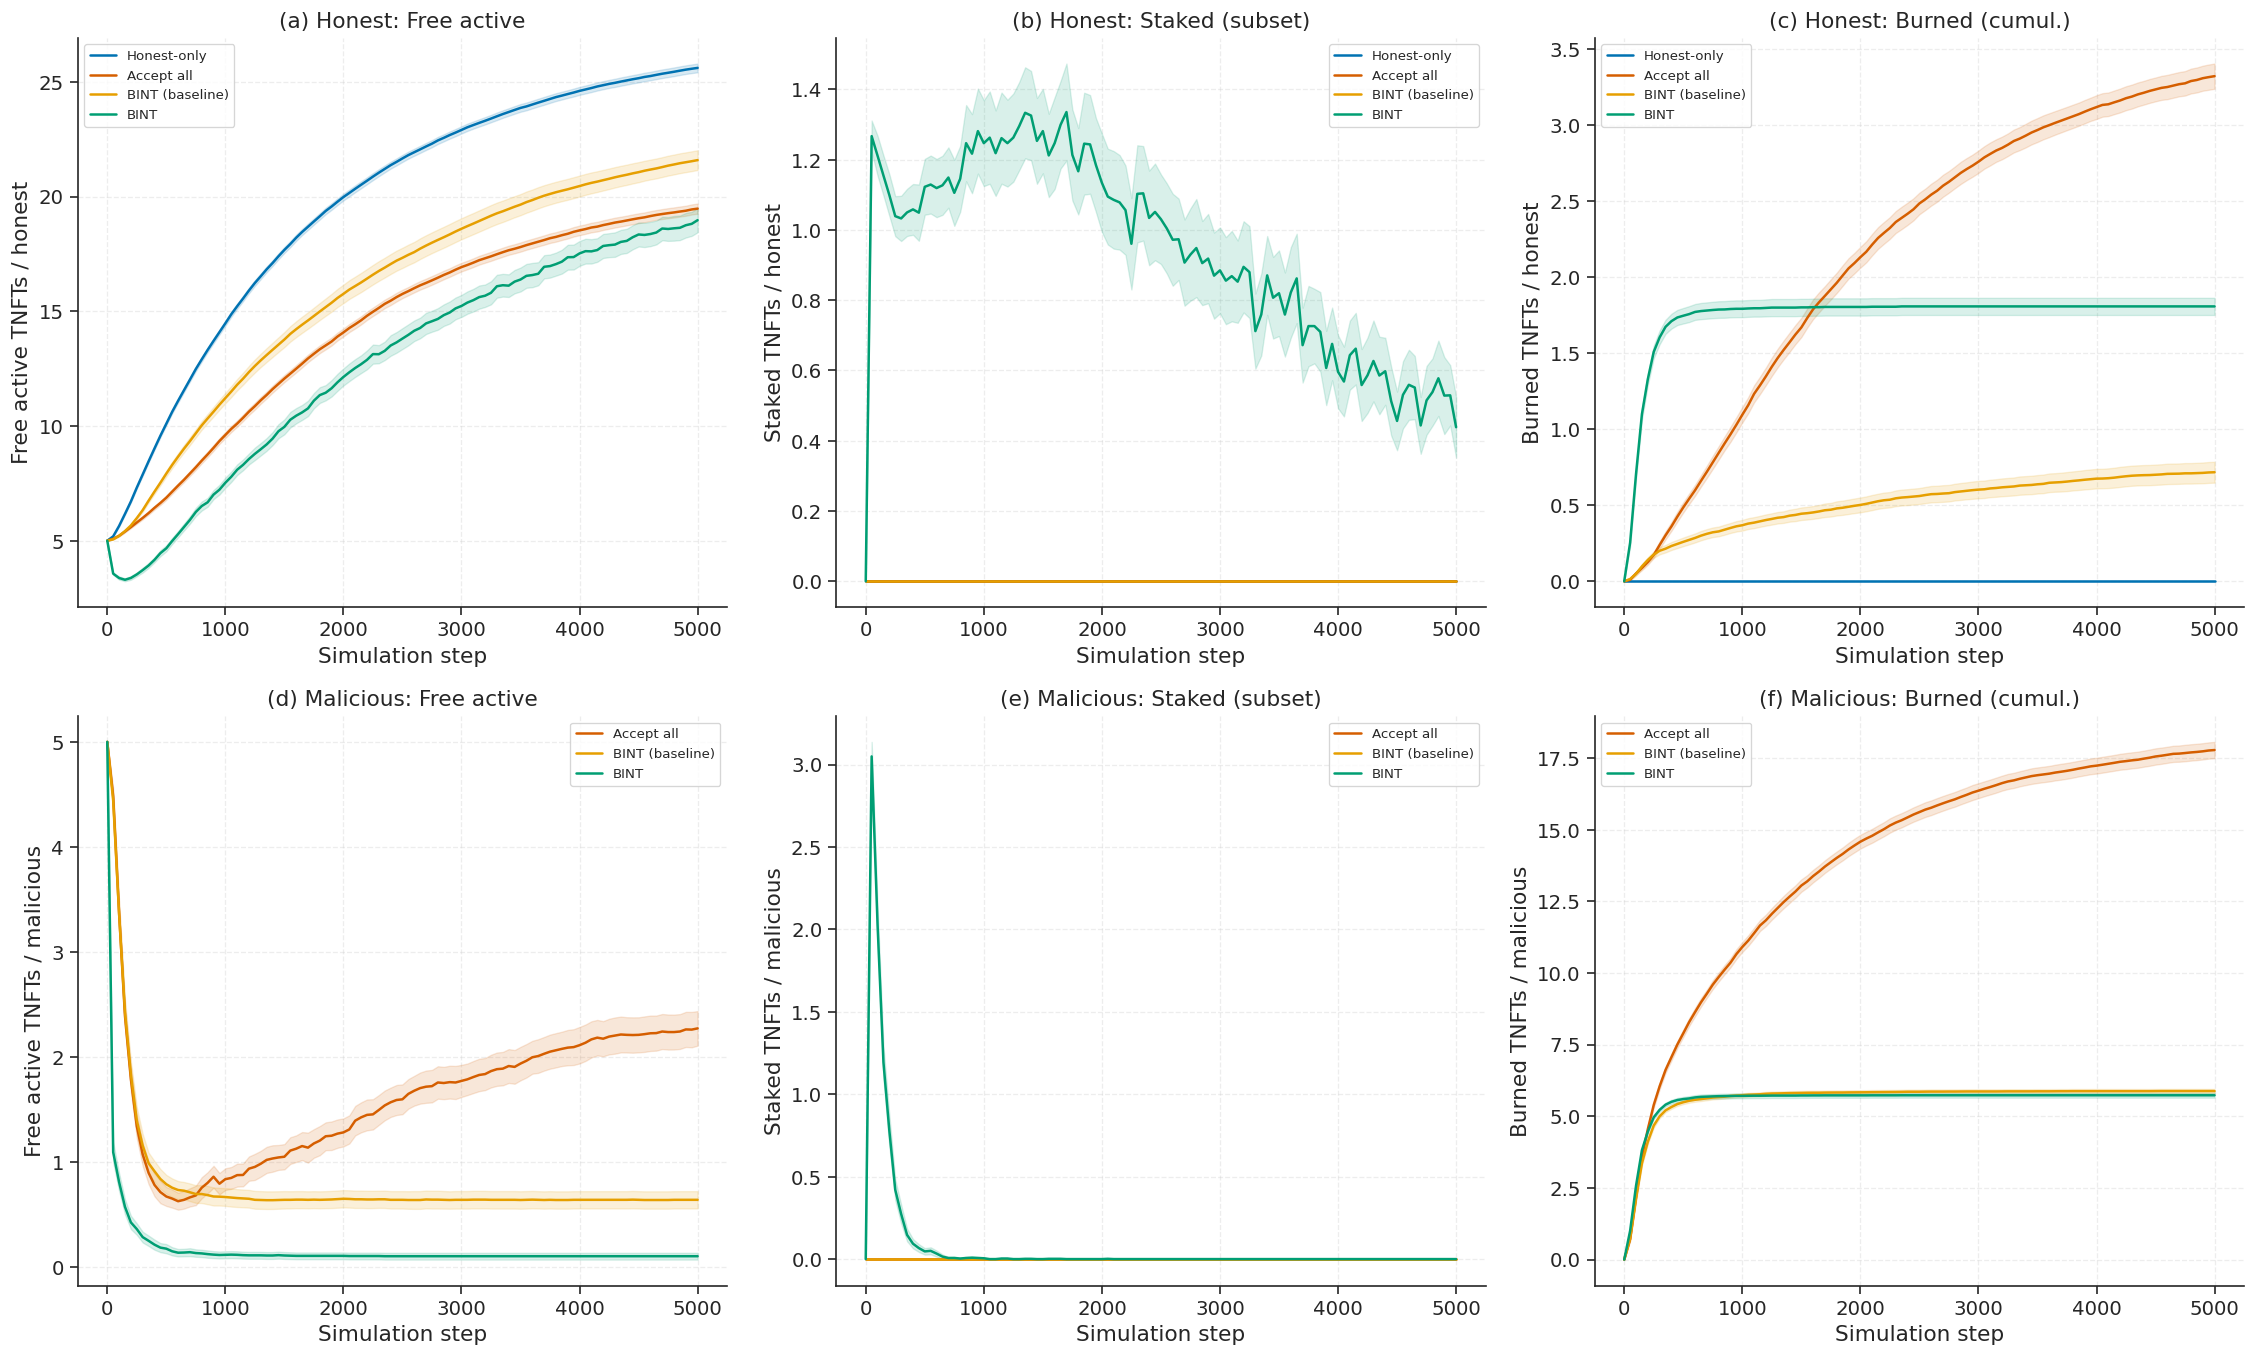

In [47]:
# ── Figure: Complete TNFT lifecycle (active, staked, burned) ─────────────────
# Staked TNFTs are a SUBSET of active: locked as collateral for a pending interaction.
# Free = active - staked: immediately available.
# Burned: cumulative, permanently removed.
# This figure shows the full token economy dynamics for each agent type.

_lc = abl_traj.copy()
_lc["free_tnfts_honest"]    = (_lc["active_tnfts_honest"]    - _lc["staked_tnfts_honest"]).clip(lower=0)
_lc["free_tnfts_malicious"] = (_lc["active_tnfts_malicious"] - _lc["staked_tnfts_malicious"]).clip(lower=0)
_lc["free_per_honest"]       = safe_div(_lc["free_tnfts_honest"],    _lc["honest_agents"])
_lc["staked_per_honest"]     = safe_div(_lc["staked_tnfts_honest"],  _lc["honest_agents"])
_lc["burned_per_honest"]     = safe_div(_lc["burned_tnfts_honest"],  _lc["honest_agents"])
_lc["free_per_malicious"]    = safe_div(_lc["free_tnfts_malicious"], _lc["malicious_agents"])
_lc["staked_per_malicious"]  = safe_div(_lc["staked_tnfts_malicious"],_lc["malicious_agents"])
_lc["burned_per_malicious"]  = safe_div(_lc["burned_tnfts_malicious"],_lc["malicious_agents"])

_adv_lc = [c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"]

fig, axes = plt.subplots(2, 3, figsize=(19, 11.5))
_HON = [("free_per_honest",    "Free active TNFTs / honest",   "(a) Honest: Free active"),
        ("staked_per_honest",  "Staked TNFTs / honest",        "(b) Honest: Staked (subset)"),
        ("burned_per_honest",  "Burned TNFTs / honest",        "(c) Honest: Burned (cumul.)")]
_MAL = [("free_per_malicious", "Free active TNFTs / malicious","(d) Malicious: Free active"),
        ("staked_per_malicious","Staked TNFTs / malicious",    "(e) Malicious: Staked (subset)"),
        ("burned_per_malicious","Burned TNFTs / malicious",    "(f) Malicious: Burned (cumul.)")]

for ax, (m, yl, t) in zip(axes[0], _HON):
    ci_lineplot(ax, _lc, y=m, configs=SCENARIO_ORDER, ylabel=yl, title=t)
for ax, (m, yl, t) in zip(axes[1], _MAL):
    ci_lineplot(ax, _lc[_lc["malicious_agents"] > 0], y=m, configs=_adv_lc, ylabel=yl, title=t)

fig.tight_layout()
save_figure("fig_tnft_lifecycle_complete.pdf")
plt.show()

## Token economy summary

For each scenario × agent type, shows the final TNFT balance at end of run.
**Burn fraction** = burned / (active + burned): the share of all tokens ever
held that were destroyed. A working mechanism should produce a large gap
between honest (low burn fraction) and malicious (high burn fraction) agents,
and this gap should widen from Accept-all → BINT (baseline) → BINT.

In [48]:
# ── Token economy summary table ───────────────────────────────────────────────
_genesis = FINAL_BASE_PARAMETERS["genesis_tokens"]

_te_rows = []
for _cfg in SCENARIO_ORDER:
    _lbl = SCENARIO_LABELS.get(_cfg, _cfg)
    for _atype in ["honest", "malicious"]:
        _sub = abl_snap[
            (abl_snap["config"] == _cfg) & (abl_snap["agent_type"] == _atype)
        ]
        if _sub.empty:
            continue
        _active = _sub["active_tnfts"].mean()
        _burned = _sub["burned_tnfts"].mean()
        _total  = _active + _burned
        _bfrac  = _burned / _total if _total > 0 else float("nan")
        _te_rows.append({
            "Scenario":              _lbl,
            "Agent type":            _atype.capitalize(),
            "Active / agent":        f"{_active:.2f}",
            "Burned / agent":        f"{_burned:.2f}",
            "Total held / agent":    f"{_total:.2f}",
            "Earned beyond genesis": f"{(_total - _genesis):+.2f}",
            "Burn fraction":         f"{_bfrac:.3f}" if not pd.isna(_bfrac) else "—",
        })

_te_tbl = pd.DataFrame(_te_rows).set_index(["Scenario", "Agent type"])
print(f"=== Token Economy Summary (genesis = {_genesis} tokens / agent) ===")
display(_te_tbl)
_te_tbl.to_csv(OUTPUT_DIR / "token_economy_table.csv")
print("Saved: token_economy_table.csv")

=== Token Economy Summary (genesis = 5 tokens / agent) ===


Active / agent Burned / agent Total held / agent Earned beyond genesis Burn fraction
Scenario        Agent type                                                                                     
Honest-only     Honest              25.61           0.00              25.61                +20.61         0.000
Accept all      Honest              19.47           3.32              22.80                +17.80         0.146
                Malicious            2.27          17.78              20.05                +15.05         0.887
BINT (baseline) Honest              21.59           0.72              22.31                +17.31         0.032
                Malicious            0.64           5.88               6.52                 +1.52         0.902
BINT            Honest              19.41           1.81              21.22                +16.22         0.085
                Malicious            0.10           5.73               5.84                 +0.84         0.982

Saved: token_economy_table.csv


## Staking effect: trust alone vs trust + staking

These figures isolate the contribution of the staking mechanism by comparing
`bint_baseline` (trust filtering only, no staking) vs `bint_staking` (full BINT).

**Key question**: does staking reduce malicious exploitation beyond what trust
filtering alone achieves?

Expected: staking burns TNFTs directly on failure → faster depletion of malicious
agent token capital → lower trust scores sooner → more aggressive filtering.

Saved: fig_staking_effect.pdf + fig_staking_effect.svg


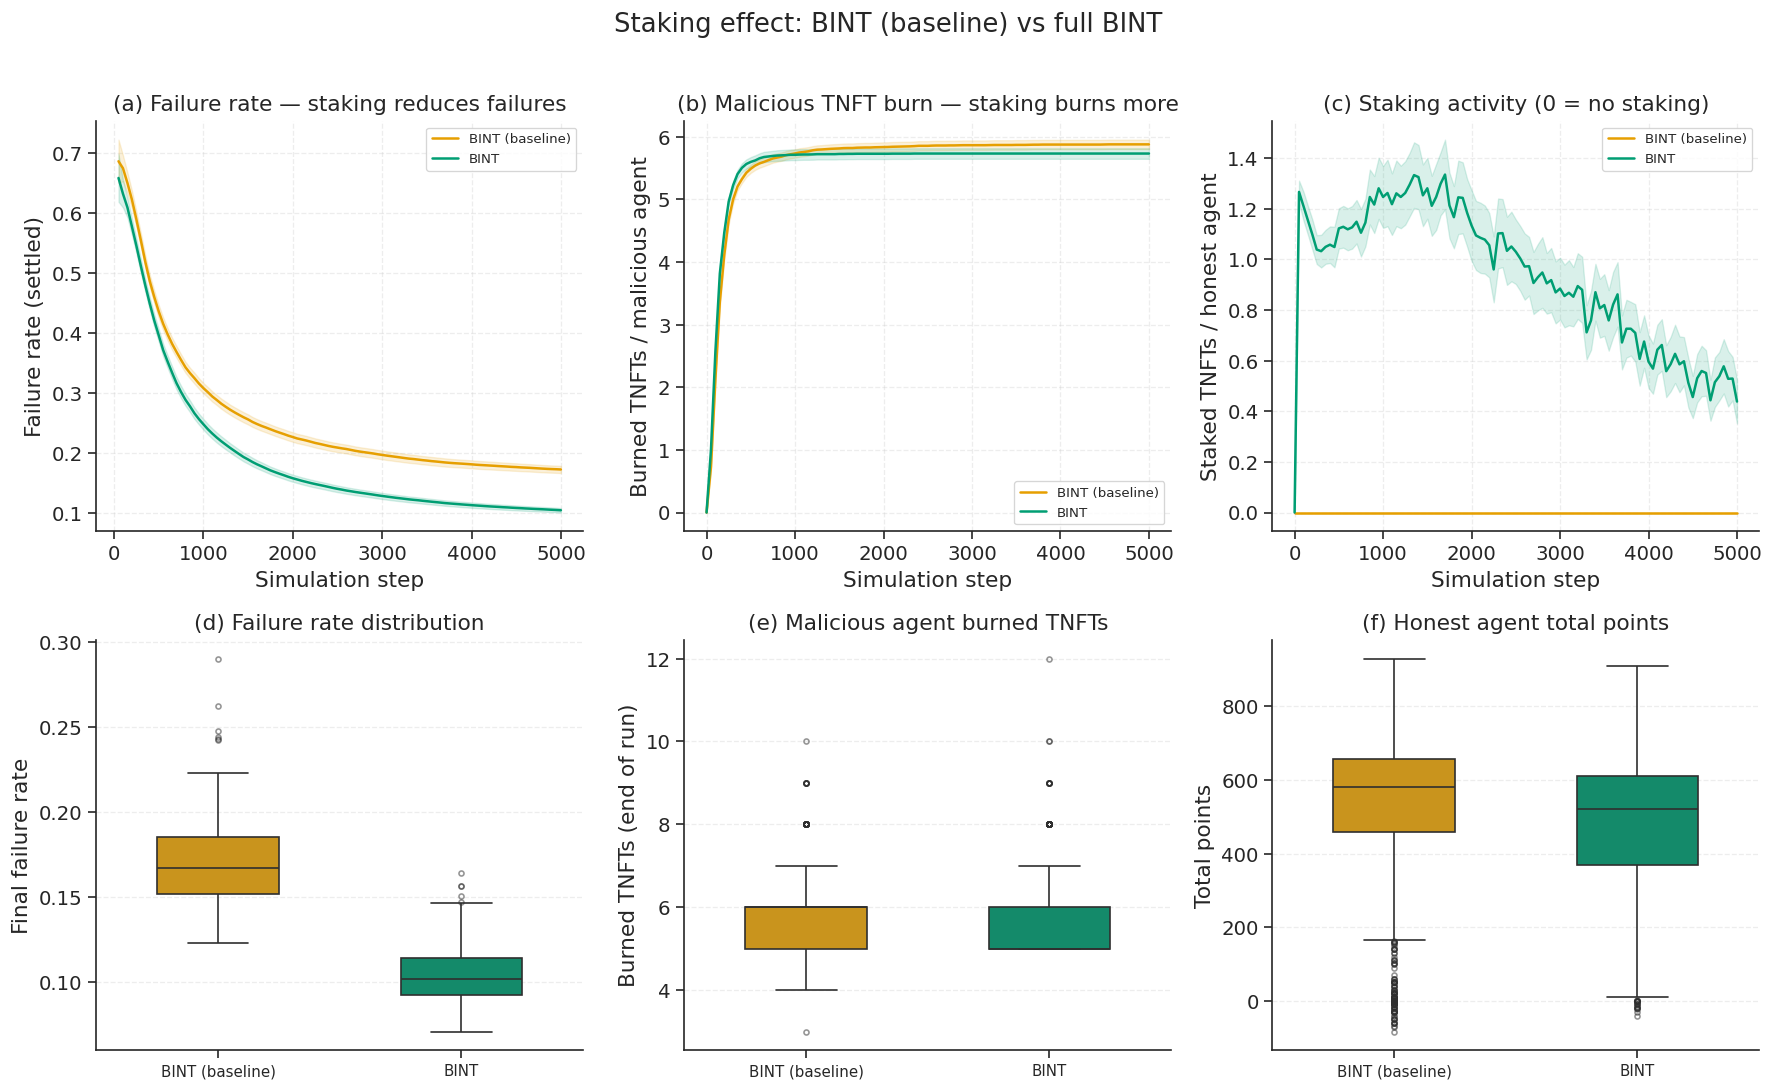

Staking effect summary (means across 50 seeds):
  BINT (baseline):
    failure_rate     = 0.1732
    malicious_pts    = 27.42
    burned TNFTs/mal = 5.88
  BINT:
    failure_rate     = 0.1052
    malicious_pts    = -1.09
    burned TNFTs/mal = 5.73


In [49]:
# ── Figure: Staking effect — bint_baseline vs bint_staking comparison ─────────
# Isolates the contribution of the staking mechanism to the BINT mechanism.

_stk_cfgs = ["bint_baseline", "bint_staking"]
_stk_traj  = abl_traj[abl_traj["config"].isin(_stk_cfgs)]
_stk_final = abl_final[abl_final["config"].isin(_stk_cfgs)]
_stk_snap  = abl_snap[abl_snap["config"].isin(_stk_cfgs)]

# Staking-specific color overrides so both lines are visible
_STAKING_COLORS = {
    "bint_baseline": SCENARIO_COLORS["bint_baseline"],
    "bint_staking":  SCENARIO_COLORS["bint_staking"],
}

fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: time-series comparisons
ci_lineplot(axes[0, 0], _stk_traj,
            y="failure_rate",
            configs=_stk_cfgs,
            ylabel="Failure rate (settled)",
            title="(a) Failure rate — staking reduces failures")

ci_lineplot(axes[0, 1],
            _stk_traj[_stk_traj["malicious_agents"] > 0],
            y="burned_tnfts_per_malicious",
            configs=_stk_cfgs,
            ylabel="Burned TNFTs / malicious agent",
            title="(b) Malicious TNFT burn — staking burns more")

ci_lineplot(axes[0, 2], _stk_traj,
            y="staked_tnfts_per_honest",
            configs=_stk_cfgs,
            ylabel="Staked TNFTs / honest agent",
            title="(c) Staking activity (0 = no staking)")

# Row 2: end-state distributions
scenario_boxplot(axes[1, 0], _stk_final,
                 "failure_rate",
                 ylabel="Final failure rate",
                 title="(d) Failure rate distribution")

scenario_boxplot(axes[1, 1],
                 _stk_snap[_stk_snap["agent_type"] == "malicious"],
                 "burned_tnfts",
                 ylabel="Burned TNFTs (end of run)",
                 title="(e) Malicious agent burned TNFTs")

scenario_boxplot(axes[1, 2],
                 _stk_snap[_stk_snap["agent_type"] == "honest"],
                 "points",
                 ylabel="Total points",
                 title="(f) Honest agent total points")

fig.suptitle("Staking effect: BINT (baseline) vs full BINT", y=1.01)
fig.tight_layout()
save_figure("fig_staking_effect.pdf")
plt.show()

# Quantitative staking effect summary
print("Staking effect summary (means across 50 seeds):")
for _cfg in _stk_cfgs:
    _f = _stk_final[_stk_final["config"] == _cfg]
    _s = _stk_snap[(_stk_snap["config"] == _cfg) & (_stk_snap["agent_type"] == "malicious")]
    print(f"  {SCENARIO_LABELS[_cfg]}:")
    print(f"    failure_rate     = {_f['failure_rate'].mean():.4f}")
    print(f"    malicious_pts    = {_f['points_per_malicious_agent'].mean():.2f}")
    print(f"    burned TNFTs/mal = {_s['burned_tnfts'].mean():.2f}")

## Section 21–23 — Interaction and decision analysis

Saved: fig8_provider_composition.pdf + fig8_provider_composition.svg


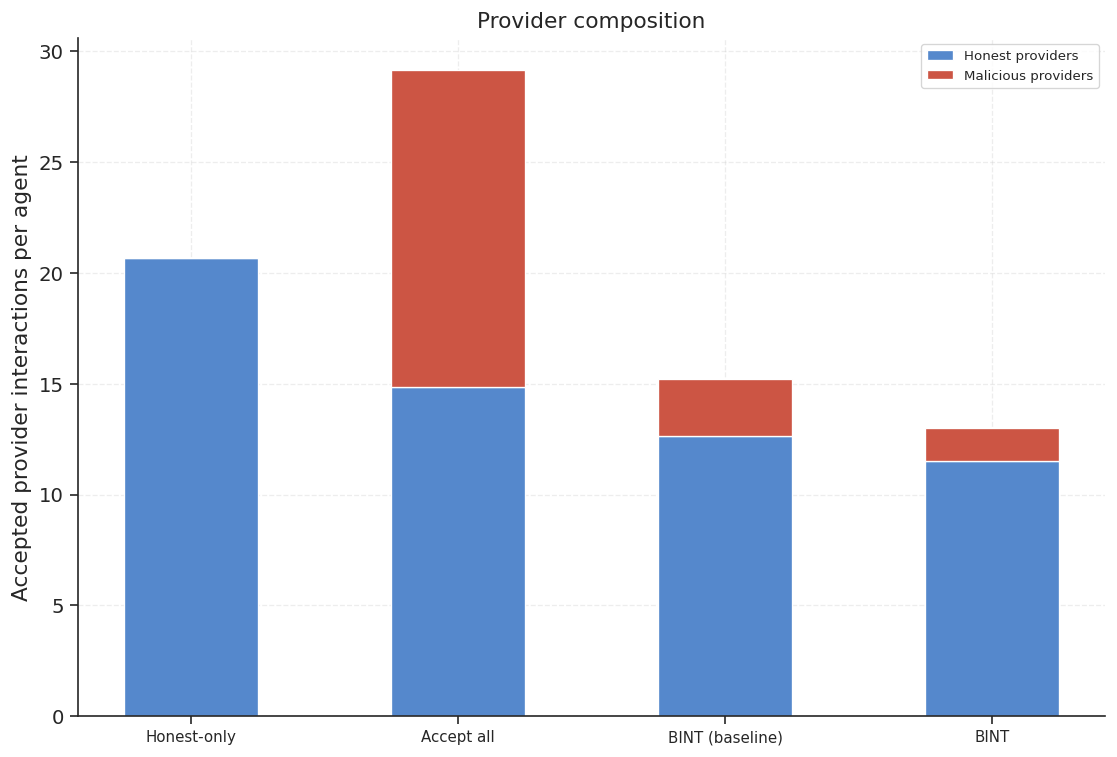

In [50]:
# ── Figure 8: Accepted provider composition (stacked bar) ────────────────────
_pc = (
    abl_final
    .groupby("config")[["accepted_honest_per_agent", "accepted_malicious_per_agent"]]
    .mean()
    .reindex(SCENARIO_ORDER)
    .fillna(0)
)
_pc.index = [SCENARIO_LABELS[i] for i in _pc.index]

fig, ax = plt.subplots(figsize=FIG_SINGLE)
bottom = np.zeros(len(_pc))

bar_colors = {"Honest providers": "#5588cc", "Malicious providers": "#cc5544"}
for col, label, color in [
    ("accepted_honest_per_agent",    "Honest providers",    "#5588cc"),
    ("accepted_malicious_per_agent", "Malicious providers", "#cc5544"),
]:
    vals = _pc[col].values
    ax.bar(_pc.index, vals, bottom=bottom, label=label, color=color, width=0.5, edgecolor="white")
    bottom += vals

ax.set_ylabel("Accepted provider interactions per agent")
ax.set_title("Provider composition")
ax.legend(fontsize=8)
ax.tick_params(axis="x", labelsize=9)
sns.despine(ax=ax)
fig.tight_layout()
save_figure("fig8_provider_composition.pdf")
plt.show()

## Decision reason verification

## Model limitation: reviewer credibility and false-positive collusion

The reviewer credibility check in `DeliveryAgent.verify_credibility`
(agents.py line 199–208) only checks:

```python
return summary["negative_review_rate"] <= self.max_negative_review_rate
```

**What this catches well:** A malicious requester issuing false *negative*
reviews (reporting honest providers as failures) will accumulate a high
`negative_review_rate` and be rejected as a requester. This directly protects
honest providers against reputation attacks.

**What this does not catch:** A malicious requester issuing exclusively false
*positive* reviews (reporting malicious providers as successes) will have a
*low* `negative_review_rate` and pass the credibility check. This means
systematic reputation inflation of malicious providers through false positives
is not directly penalised by the reviewer credibility mechanism.

**Why it still partially works in practice:** Malicious providers with inflated
reputation will eventually fail deliveries (they give wrong coordinates), and
honest requesters who receive those failures will issue genuine negative reviews.
These genuine negatives accumulate in the provider's VTP, eventually triggering
the trust filter. The false positives slow this process but don't prevent it.

**Implications for your results:**
- The `falpos` corner config (false positives only) tests this gap directly.
  If BINT still suppresses malicious agents there, it means the VTP filter
  compensates for the credibility check's blind spot.
- The `isorev` config (all reviews forged, both directions) represents the
  worst case where both mechanisms are stressed simultaneously.

**Thesis framing:** Present this as a known design trade-off. The negative-rate
check was chosen to protect honest agents from bad-mouthing attacks. Extending
it to also detect suspiciously high positive-rate reviewers (e.g., flagging
agents whose positive review rate exceeds the population mean by a threshold)
is a natural direction for future work.

In [51]:
# ── Print all logged decision reason columns ──────────────────────────────────
_rcols = sorted(c for c in abl_dec.columns
                if c not in ("config","seed","scenario_label","scenario_color"))
print(f"Decision reason columns ({len(_rcols)}):")
for _col in _rcols:
    print(f"  {_col}: {int(abl_dec[_col].sum()):,}")

Decision reason columns (11):
  provider_accepted: 151,507
  provider_rejected_low_reviewer_credibility: 1,343
  provider_rejected_low_vtp: 153,359
  provider_rejected_no_available_stake: 2,974
  provider_rejected_stake_limit: 1
  rejected_unknown_target: 2,393,807
  requester_accepted: 1,772,447
  requester_rejected_low_reviewer_credibility: 60,883
  requester_rejected_low_vtp: 1,065,599
  requester_rejected_no_available_stake: 5,825
  requester_rejected_stake_limit: 1


Saved: fig9_decision_breakdown.pdf + fig9_decision_breakdown.svg


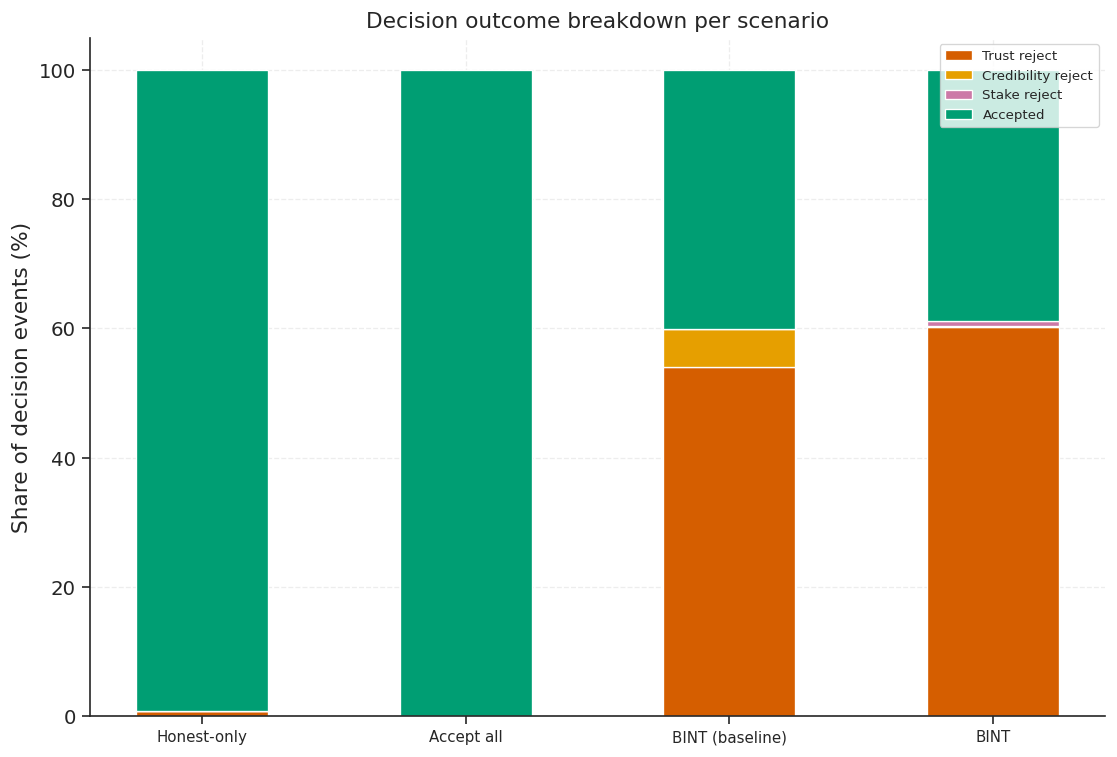

In [52]:
# ── Figure 9: Decision rejection breakdown ───────────────────────────────────
# Aggregate decision counts per scenario from decision summary DataFrames
REJECTION_GROUPS = {
    "Trust reject":       ["provider_rejected_low_vtp", "requester_rejected_low_vtp"],
    "Credibility reject": ["provider_rejected_low_reviewer_credibility",
                           "requester_rejected_low_reviewer_credibility"],
    "Stake reject":       ["provider_rejected_no_available_stake",
                           "provider_rejected_insufficient_stake",
                           "provider_rejected_stake_limit",
                           "requester_rejected_no_available_stake",
                           "requester_rejected_insufficient_stake",
                           "requester_rejected_stake_limit",
                           "stake_lock_failed"],
    "Accepted":           ["provider_accepted", "requester_accepted"],
}

dec_rows = []
for cfg, grp in abl_dec.groupby("config"):
    row = {"config": cfg}
    for group_name, reasons in REJECTION_GROUPS.items():
        total = sum(grp[r].sum() for r in reasons if r in grp.columns)
        row[group_name] = total
    dec_rows.append(row)

dec_df = pd.DataFrame(dec_rows).set_index("config")
dec_df = dec_df.reindex(SCENARIO_ORDER).dropna(how="all")
dec_df.index = [SCENARIO_LABELS[i] for i in dec_df.index]

# Normalise to rates
dec_pct = dec_df.div(dec_df.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=FIG_SINGLE)
bottom = np.zeros(len(dec_pct))
group_colors = {
    "Trust reject":       "#D55E00",
    "Credibility reject": "#E69F00",
    "Stake reject":       "#CC79A7",
    "Accepted":           "#009E73",
}

for group_name, color in group_colors.items():
    if group_name not in dec_pct.columns:
        continue
    vals = dec_pct[group_name].fillna(0).values
    ax.bar(dec_pct.index, vals, bottom=bottom, label=group_name,
           color=color, width=0.5, edgecolor="white")
    bottom += vals

ax.set_ylabel("Share of decision events (%)")
ax.set_title("Decision outcome breakdown per scenario")
ax.legend(fontsize=8, loc="upper right")
ax.tick_params(axis="x", labelsize=9)
sns.despine(ax=ax)
fig.tight_layout()
save_figure("fig9_decision_breakdown.pdf")
plt.show()

Saved: fig10_interaction_outcomes_over_time.pdf + fig10_interaction_outcomes_over_time.svg


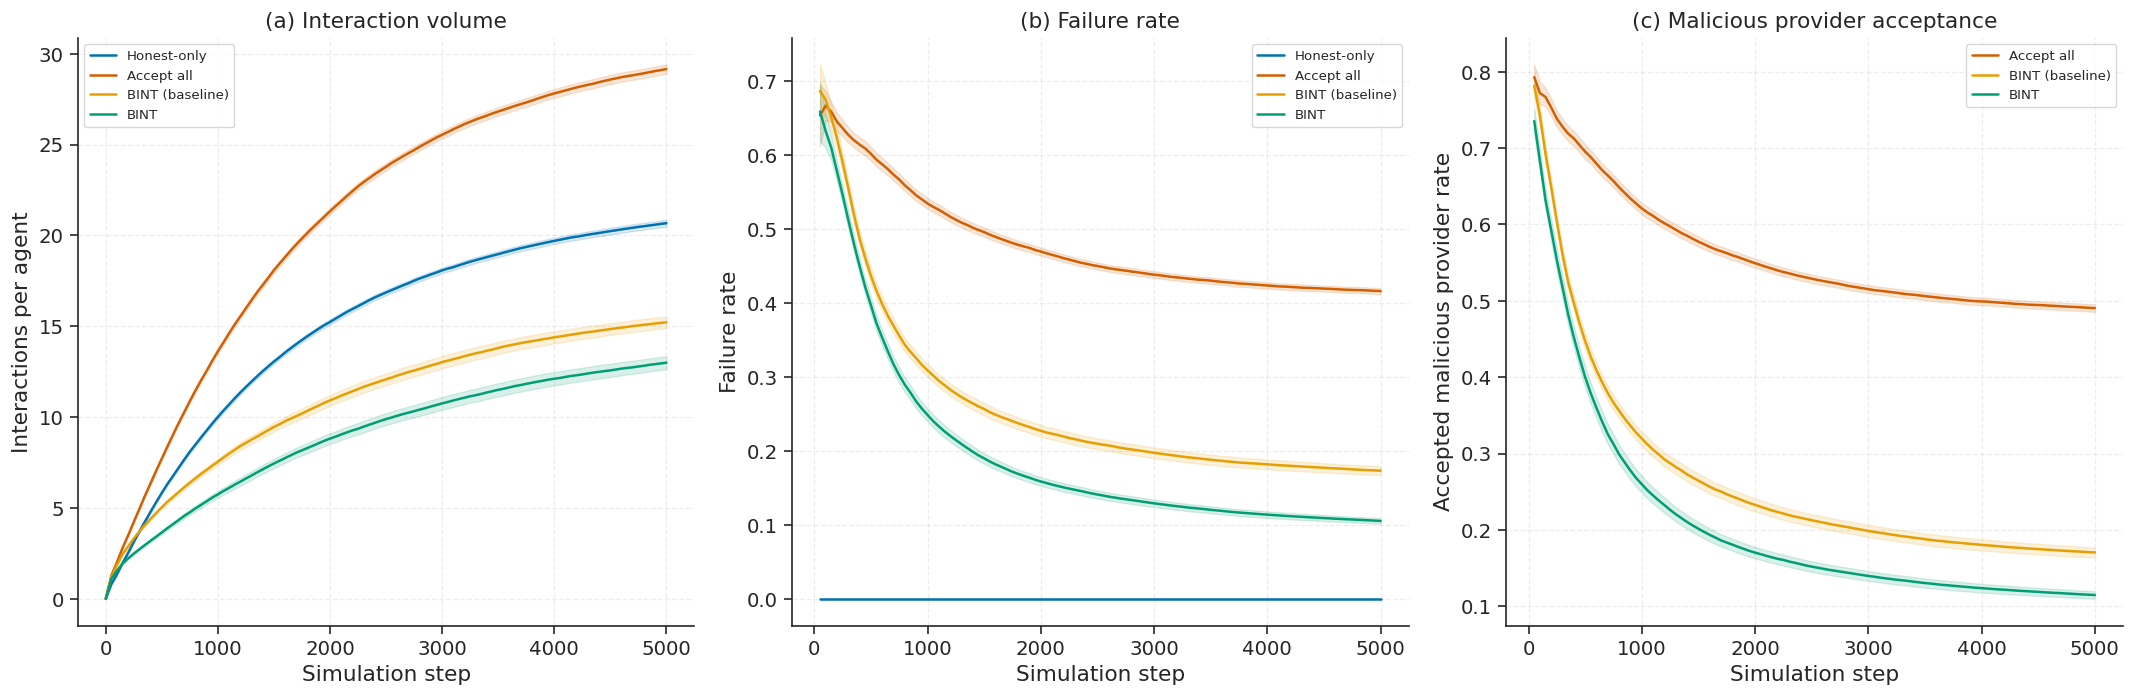

In [53]:
# ── Figure 10: Interaction outcomes over time ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=FIG_3PANEL)

ci_lineplot(axes[0], abl_traj,
    y="interactions_per_agent",
    configs=SCENARIO_ORDER,
    ylabel="Interactions per agent",
    title="(a) Interaction volume",
)
ci_lineplot(axes[1], abl_traj,
    y="failure_rate",
    configs=SCENARIO_ORDER,
    ylabel="Failure rate",
    title="(b) Failure rate",
)
ci_lineplot(
    axes[2],
    abl_traj[abl_traj["malicious_agents"] > 0],
    y="accepted_malicious_rate",
    configs=[c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"],
    ylabel="Accepted malicious provider rate",
    title="(c) Malicious provider acceptance",
)

fig.tight_layout()
save_figure("fig10_interaction_outcomes_over_time.pdf")
plt.show()

## Interaction completion and false review analysis

Saved: fig_interaction_completion.pdf + fig_interaction_completion.svg


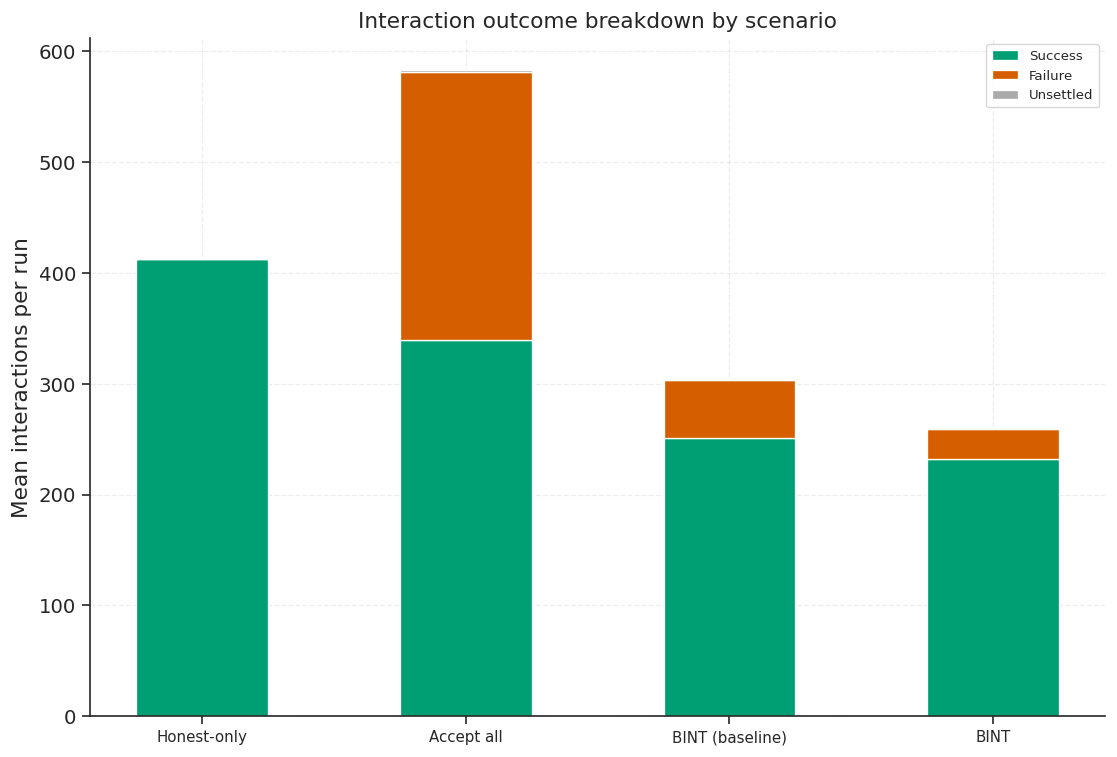

In [54]:
# ── Figure: Interaction outcome breakdown (stacked bar) ───────────────────────
# Shows per-run mean of: successful, failed, and unsettled interactions.
# Unsettled = pending at run end OR cancelled (e.g. zero-stake burn failure).

_bd = (
    abl_final
    .groupby("config")[["outcome_success","outcome_failure","interactions"]]
    .mean()
    .reindex(SCENARIO_ORDER)
    .fillna(0)
)
_bd["settled"] = _bd["outcome_success"] + _bd["outcome_failure"]
_bd["unsettled"] = (_bd["interactions"] - _bd["settled"]).clip(lower=0)
_bd.index = [SCENARIO_LABELS[i] for i in _bd.index]

fig, ax = plt.subplots(figsize=FIG_SINGLE)
_bot = np.zeros(len(_bd))
for _col, _lbl, _clr in [("outcome_success","Success","#009E73"),
                           ("outcome_failure","Failure","#D55E00"),
                           ("unsettled","Unsettled","#aaaaaa")]:
    _v = _bd[_col].fillna(0).values
    ax.bar(_bd.index, _v, bottom=_bot, label=_lbl, color=_clr, width=0.5, edgecolor="white")
    _bot += _v
ax.set_ylabel("Mean interactions per run")
ax.set_title("Interaction outcome breakdown by scenario")
ax.legend(fontsize=8); ax.tick_params(axis="x", labelsize=9)
sns.despine(ax=ax); fig.tight_layout()
save_figure("fig_interaction_completion.pdf")
plt.show()

Saved: fig_false_review_impact.pdf + fig_false_review_impact.svg


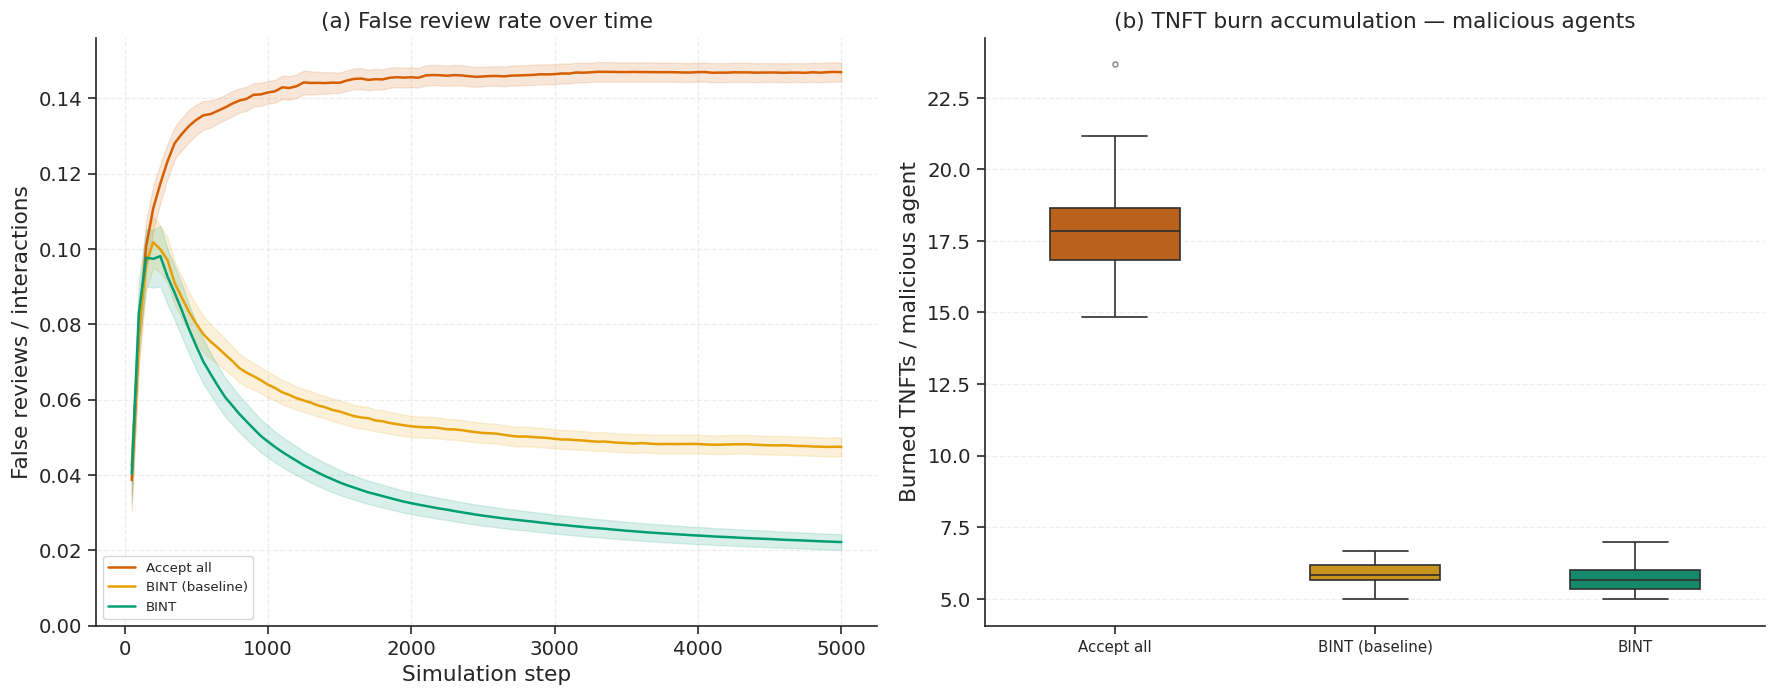

Mean false review rate by scenario:
  Accept all: 0.1469
  BINT (baseline): 0.0474
  BINT: 0.0222
  Honest-only: 0.0000


In [55]:
# ── Figure: False review rate and TNFT burn asymmetry ────────────────────────
# False reviews: malicious requesters misreport provider quality.
# false_positive: failure reported as success → malicious trustee unfairly earns TNFT.
# false_negative: success reported as failure → honest trustee unfairly gets burned.
# Panel (a): false review rate over time. Panel (b): cumulative burns for malicious agents.

_adv_cfgs_fr = [c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"]
fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL)

ci_lineplot(axes[0], abl_traj, y="false_review_rate", configs=_adv_cfgs_fr,
            ylabel="False reviews / interactions",
            title="(a) False review rate over time")
axes[0].set_ylim(bottom=0)

scenario_boxplot(axes[1],
                 abl_final[abl_final["malicious_agents"] > 0],
                 "burned_tnfts_per_malicious",
                 ylabel="Burned TNFTs / malicious agent",
                 title="(b) TNFT burn accumulation — malicious agents")

fig.tight_layout()
save_figure("fig_false_review_impact.pdf")
plt.show()

if "false_review_rate" in abl_final.columns:
    print("Mean false review rate by scenario:")
    for _cfg, _g in abl_final.groupby("config"):
        print(f"  {SCENARIO_LABELS.get(_cfg,_cfg)}: {_g['false_review_rate'].mean():.4f}")

## Section 24 — Sensitivity to malicious fraction

Saved: fig11_sensitivity_malicious_fraction.pdf + fig11_sensitivity_malicious_fraction.svg


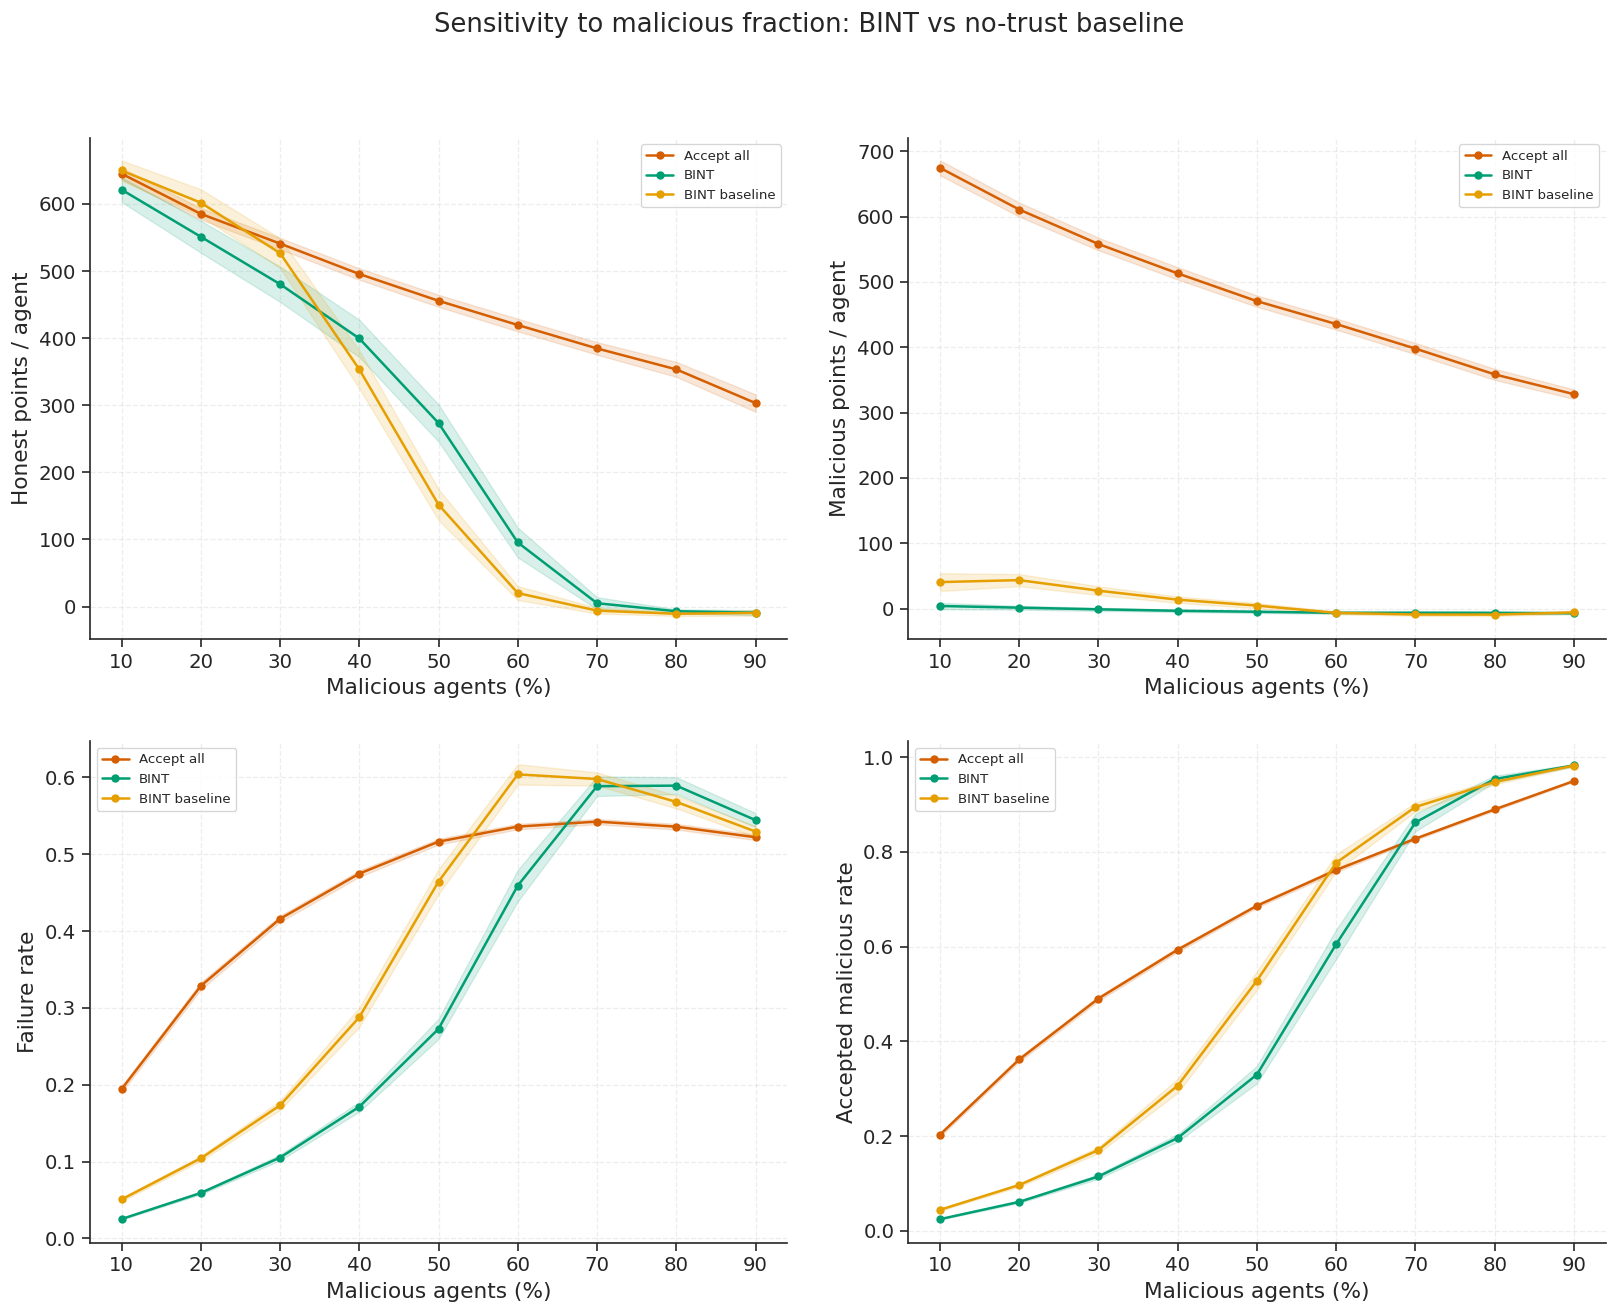

In [56]:
# ── Figure 11: Sensitivity to malicious fraction ────────────────────────────
_key_metrics = [
    ("points_per_honest_agent",   "Honest points / agent"),
    ("points_per_malicious_agent","Malicious points / agent"),
    ("failure_rate",              "Failure rate"),
    ("accepted_malicious_rate",   "Accepted malicious rate"),
]

fig, axes = plt.subplots(2, 2, figsize=FIG_2X2)
axes = axes.flatten()

TYPE_COLORS_SEN = {
    "BINT":          SCENARIO_COLORS["bint_staking"],
    "Accept all":    SCENARIO_COLORS["accept_all"],
    "BINT baseline": SCENARIO_COLORS["bint_baseline"],
}

for ax, (metric, ylabel) in zip(axes, _key_metrics):
    for stype, grp in sen_final.groupby("scenario_type"):
        sub = grp.dropna(subset=["malicious_pct", metric])
        agg = sub.groupby("malicious_pct")[metric].agg(["mean", "std", "count"]).reset_index()
        agg["ci"] = 1.96 * agg["std"] / np.sqrt(agg["count"])
        color = TYPE_COLORS_SEN.get(stype, "grey")
        ax.plot(agg["malicious_pct"], agg["mean"], marker="o", color=color,
                linewidth=1.5, markersize=4, label=stype)
        ax.fill_between(agg["malicious_pct"],
                        agg["mean"] - agg["ci"],
                        agg["mean"] + agg["ci"],
                        alpha=0.15, color=color)
    ax.set_xlabel("Malicious agents (%)")
    ax.set_ylabel(ylabel)
    ax.set_xticks([int(f * 100) for f in SENSITIVITY_FRACTIONS])
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle("Sensitivity to malicious fraction: BINT vs no-trust baseline", y=1.01)
fig.tight_layout(pad=2.0)
save_figure("fig11_sensitivity_malicious_fraction.pdf")
plt.show()

## Attack sensitivity — map attack robustness

Saved: fig_map_attack_sensitivity.pdf + fig_map_attack_sensitivity.svg


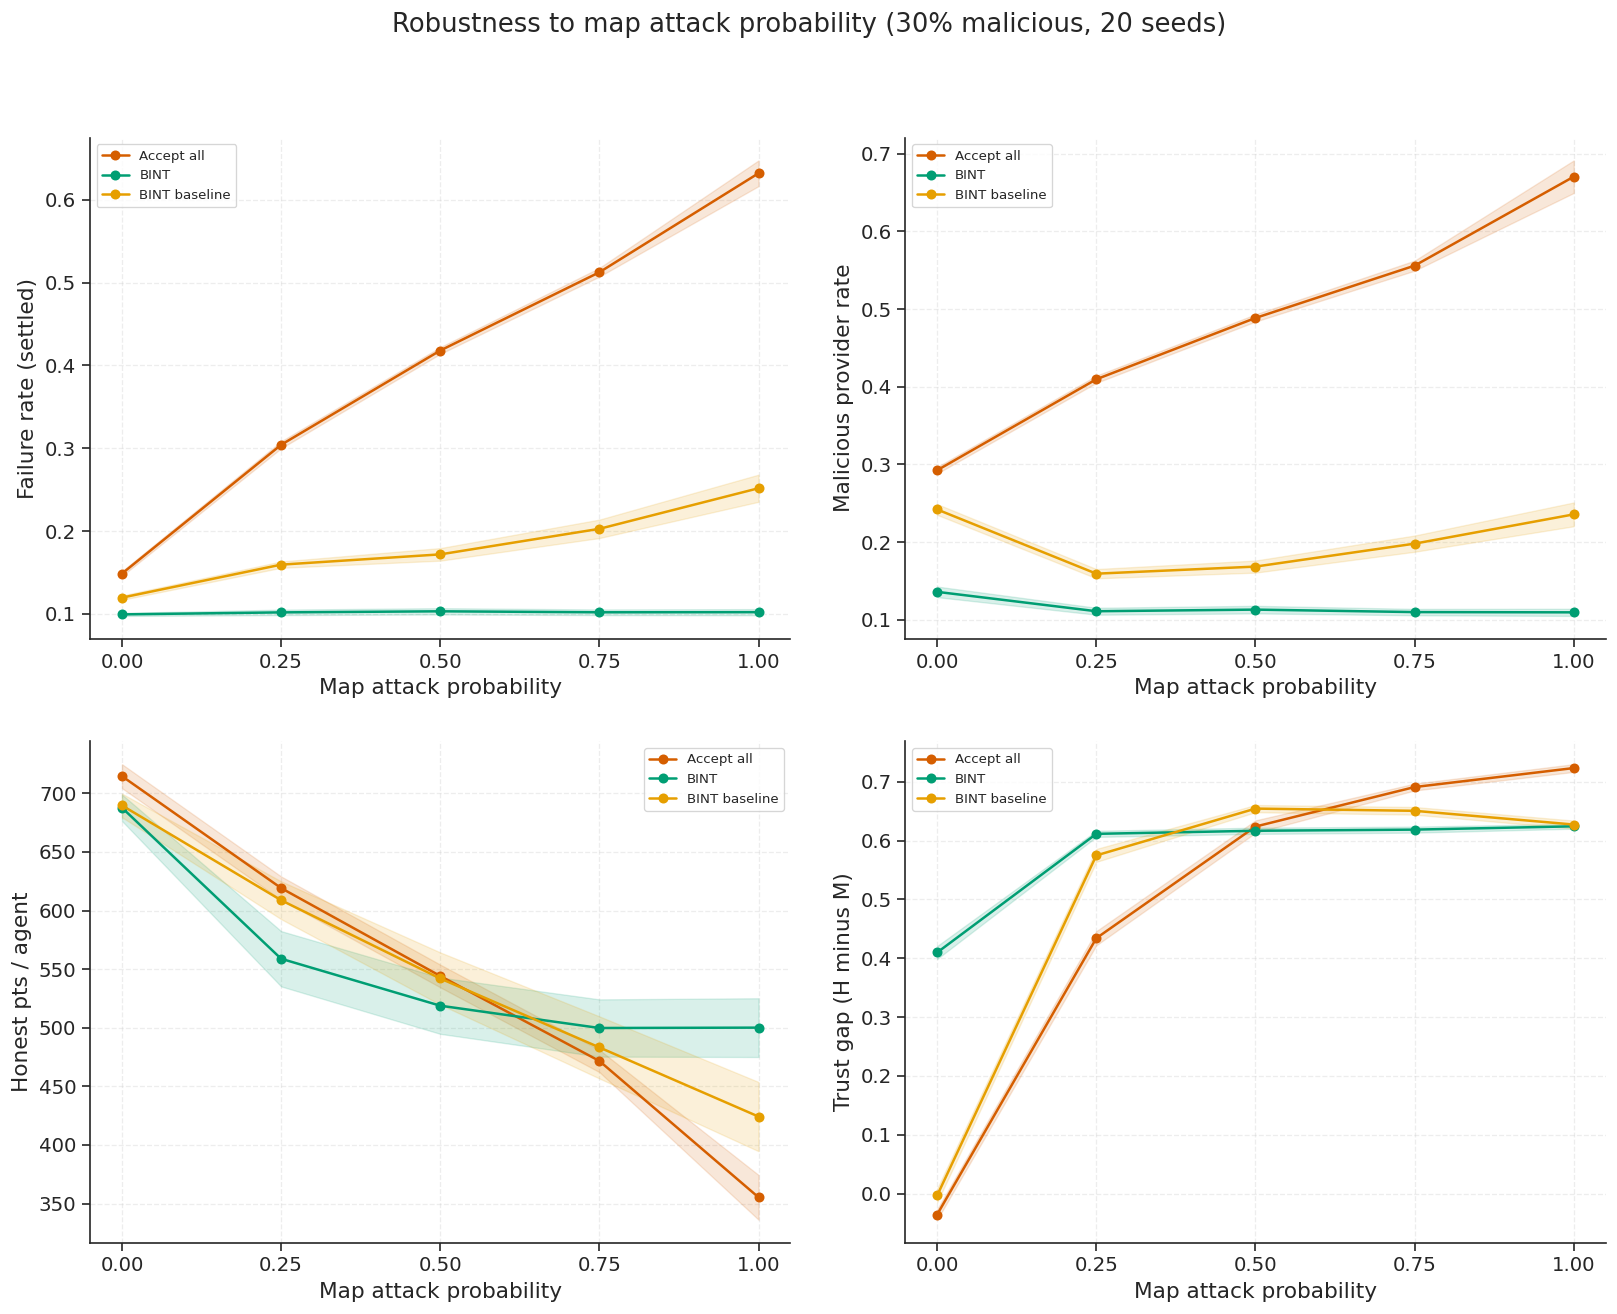

In [57]:
# ── Figure: Robustness to map attack probability ─────────────────────────────
# Shows how BINT and Accept-all respond as malicious map-coordinate attacks intensify.
# A robust mechanism maintains low failure rate and malicious provider rate
# even at high attack probabilities.

if atk_map_final is None:
    print("Map attack data not available — run the attack sensitivity cell first.")
else:
    _m_cols = [
        ("failure_rate",             "Failure rate (settled)"),
        ("accepted_malicious_rate",  "Malicious provider rate"),
        ("points_per_honest_agent",  "Honest pts / agent"),
        ("trust_gap_honest_minus_malicious", "Trust gap (H minus M)"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=FIG_2X2)
    axes = axes.flatten()
    for ax, (_m, _y) in zip(axes, _m_cols):
        for _st, _grp in atk_map_final.groupby("scenario_type"):
            _s = _grp.dropna(subset=["map_attack_prob", _m])
            _a = _s.groupby("map_attack_prob")[_m].agg(["mean","std","count"]).reset_index()
            _a["ci"] = 1.96 * _a["std"] / np.sqrt(_a["count"])
            _c = _ATK_COLORS.get(_st, "grey")
            ax.plot(_a["map_attack_prob"], _a["mean"], marker="o", color=_c,
                    linewidth=1.5, markersize=5, label=_st)
            ax.fill_between(_a["map_attack_prob"],
                            _a["mean"] - _a["ci"], _a["mean"] + _a["ci"],
                            alpha=0.15, color=_c)
        ax.set_xlabel("Map attack probability"); ax.set_ylabel(_y)
        ax.set_xticks(ATK_MAP_PROBS); ax.legend(fontsize=8); sns.despine(ax=ax)
    fig.suptitle("Robustness to map attack probability (30% malicious, 20 seeds)", y=1.01)
    fig.tight_layout(pad=2.0)
    save_figure("fig_map_attack_sensitivity.pdf")
    plt.show()

## Attack sensitivity — review forgery robustness

Saved: fig_review_attack_sensitivity.pdf + fig_review_attack_sensitivity.svg


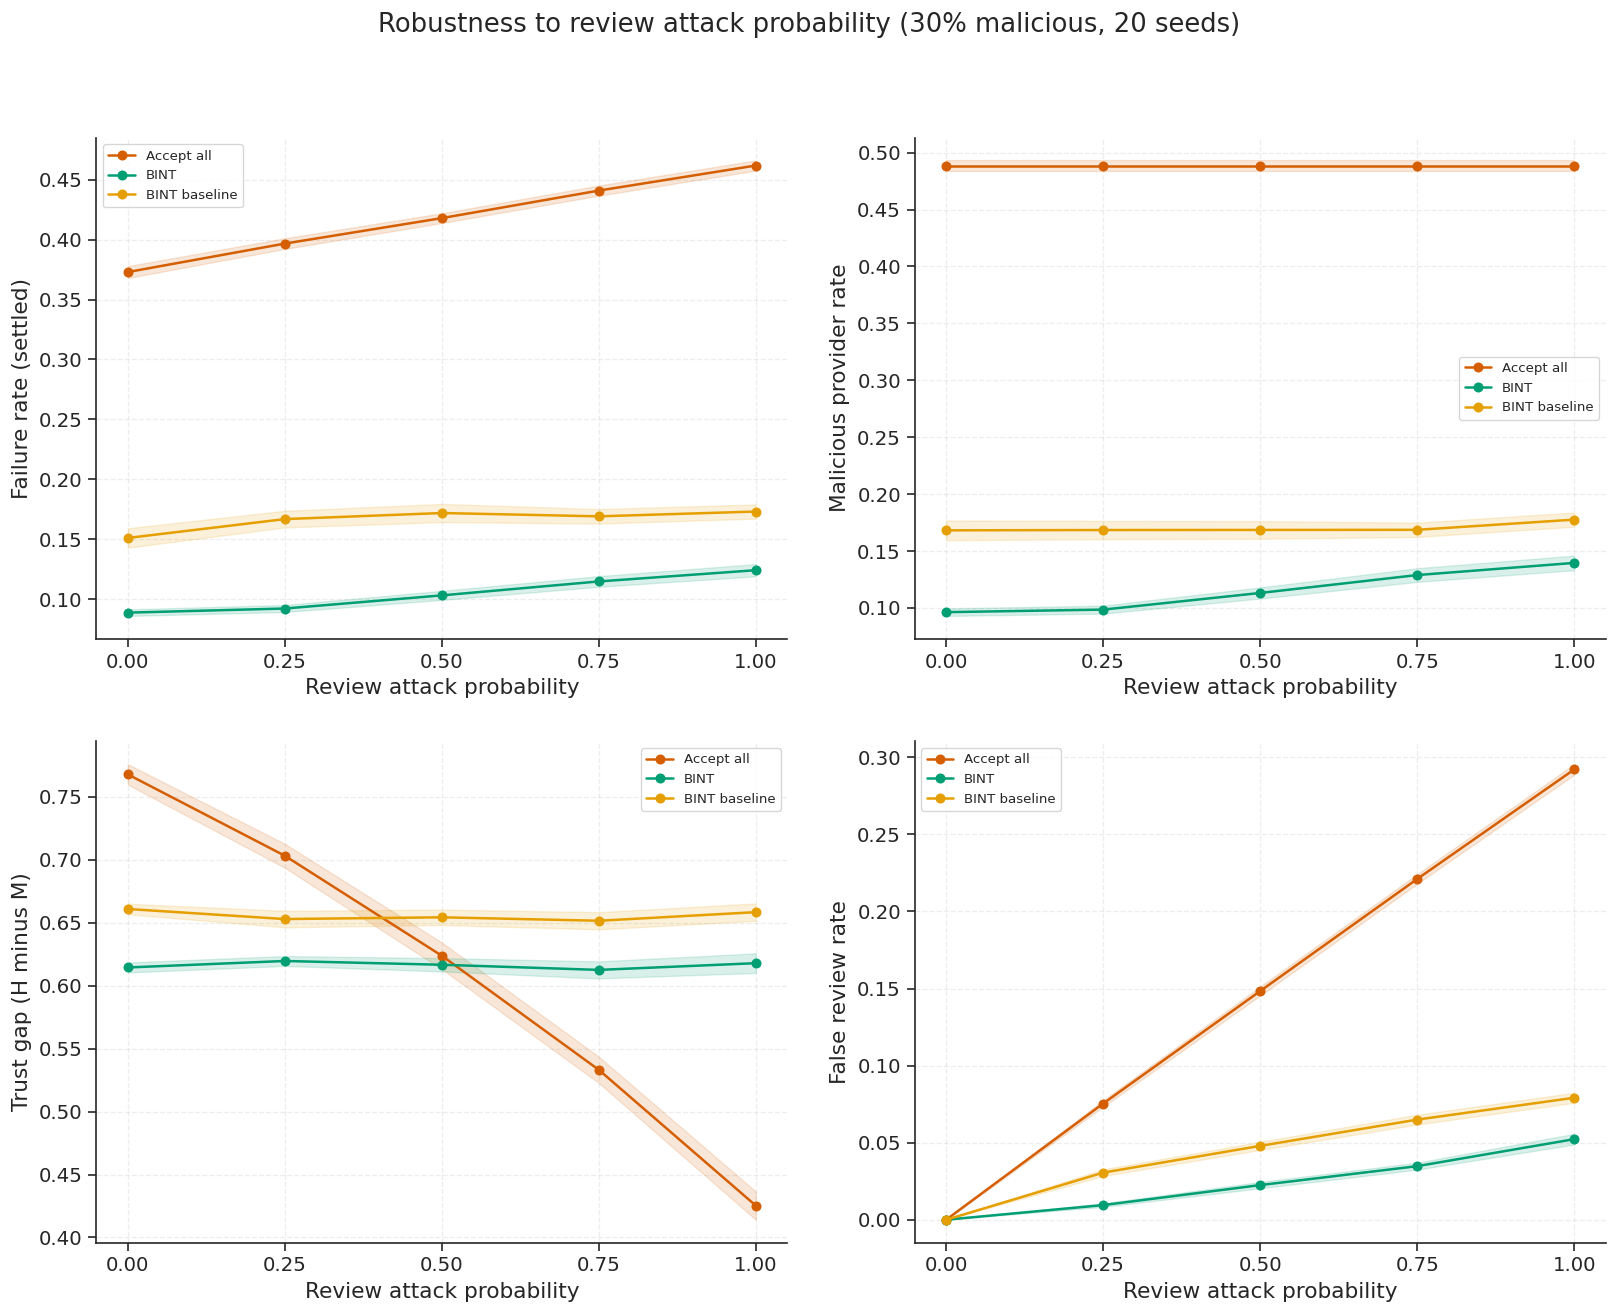

In [58]:
# ── Figure: Robustness to review attack probability ──────────────────────────
# As false_review_probability increases, malicious requesters forge more evaluations,
# polluting the trust signal. This tests the reviewer credibility mechanism.
# Key question: does BINT maintain trust accuracy even under heavy review manipulation?

if atk_rev_final is None:
    print("Review attack data not available — run the attack sensitivity cell first.")
else:
    _r_cols = [
        ("failure_rate",             "Failure rate (settled)"),
        ("accepted_malicious_rate",  "Malicious provider rate"),
        ("trust_gap_honest_minus_malicious", "Trust gap (H minus M)"),
        ("false_review_rate",        "False review rate"),
    ]
    fig, axes = plt.subplots(2, 2, figsize=FIG_2X2)
    axes = axes.flatten()
    for ax, (_m, _y) in zip(axes, _r_cols):
        for _st, _grp in atk_rev_final.groupby("scenario_type"):
            _s = _grp.dropna(subset=["review_attack_prob", _m])
            if _s.empty: continue
            _a = _s.groupby("review_attack_prob")[_m].agg(["mean","std","count"]).reset_index()
            _a["ci"] = 1.96 * _a["std"] / np.sqrt(_a["count"])
            _c = _ATK_COLORS.get(_st, "grey")
            ax.plot(_a["review_attack_prob"], _a["mean"], marker="o", color=_c,
                    linewidth=1.5, markersize=5, label=_st)
            ax.fill_between(_a["review_attack_prob"],
                            _a["mean"] - _a["ci"], _a["mean"] + _a["ci"],
                            alpha=0.15, color=_c)
        ax.set_xlabel("Review attack probability"); ax.set_ylabel(_y)
        ax.set_xticks(ATK_REV_PROBS); ax.legend(fontsize=8); sns.despine(ax=ax)
    fig.suptitle("Robustness to review attack probability (30% malicious, 20 seeds)", y=1.01)
    fig.tight_layout(pad=2.0)
    save_figure("fig_review_attack_sensitivity.pdf")
    plt.show()

## Corner and asymmetric attack analysis

Five mechanistically specific attack configurations show which BINT defensive
layer handles which threat:

| Config | `false_map` | `false_neg` | `false_pos` | What it tests |
|---|---|---|---|---|
| Isolated map | 1.0 | 0.0 | 0.0 | VTP filter alone; honest reviews of all failures |
| Isolated review | 0.0 | 1.0 | 1.0 | Review credibility filter; known maps correct |
| Worst case | 1.0 | 1.0 | 1.0 | Both attacks maxed simultaneously |
| False neg. only | 0.0 | 1.0 | 0.0 | Attack on honest providers' reputations only |
| False pos. only | 0.0 | 0.0 | 1.0 | Inflation of malicious providers' reputations only |

The **isolated review** attack is the most interesting: maps are correct so
deliveries succeed, but reviews are forged. Does BINT still correctly
distinguish agents when the reputation signal is fully corrupted?

The **asymmetric** configs (false neg vs false pos) reveal whether BINT is
more vulnerable to attacks that harm honest agents or attacks that inflate
malicious ones — directly relevant to the threat model discussion.


Saved: fig_corner_attack_heatmap.pdf + fig_corner_attack_heatmap.svg


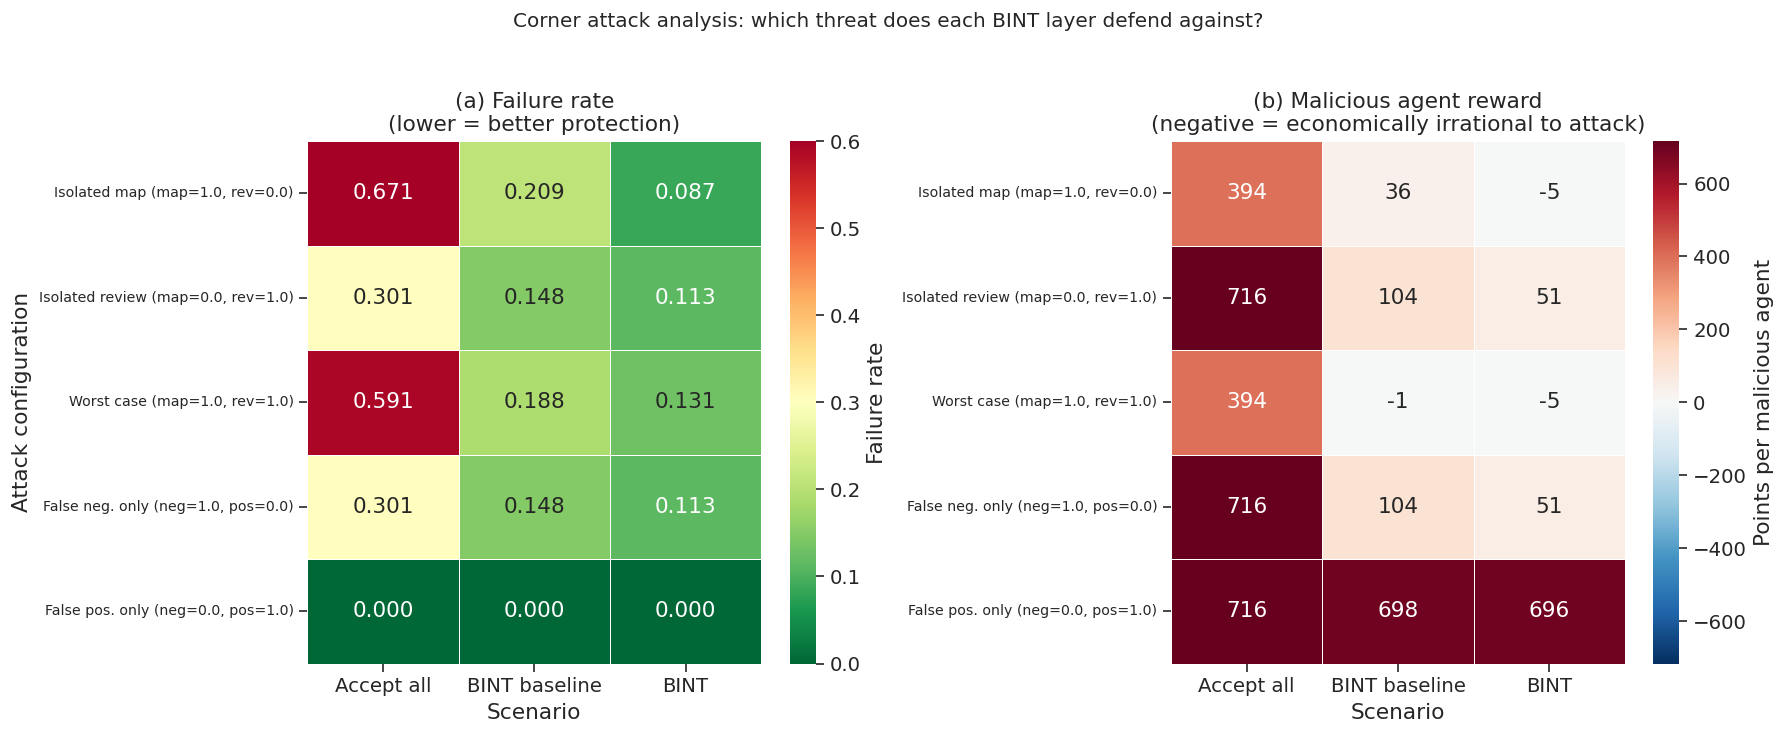

Key results — failure rate (mean across seeds):
scenario_type  Accept all  BINT baseline  BINT
attack_tag                                    
isomap              0.671          0.209 0.087
isorev              0.301          0.148 0.113
worst               0.591          0.188 0.131
falneg              0.301          0.148 0.113
falpos              0.000          0.000 0.000

Key results — malicious pts / agent:
scenario_type  Accept all  BINT baseline  BINT
attack_tag                                    
isomap              393.8           36.4  -5.5
isorev              716.0          103.9  51.2
worst               393.6           -1.2  -5.4
falneg              716.0          103.9  51.2
falpos              716.0          698.1 696.1


In [59]:
# ── Figure: Corner attack heatmap ────────────────────────────────────────────
# Two heatmaps showing failure_rate and malicious_pts across attack x scenario.
# Rows: attack configuration.  Columns: scenario type.
# Green = mechanism working. Red = mechanism struggling.

if corner_final is None:
    print("Corner attack data not available — run the attack sensitivity cell first.")
else:
    _SCEN_ORDER_C = ["Accept all", "BINT baseline", "BINT"]
    _ATK_ORDER    = [tag for tag, *_ in _CORNER_ATTACKS]
    _ATK_LABELS   = [
        CORNER_ATTACK_LABELS[t].replace("\n", " ")
        for t in _ATK_ORDER
    ]

    _piv_fail = (
        corner_final
        .groupby(["attack_tag", "scenario_type"])["failure_rate"]
        .mean()
        .reset_index()
        .pivot(index="attack_tag", columns="scenario_type", values="failure_rate")
        .reindex(index=_ATK_ORDER, columns=_SCEN_ORDER_C)
    )
    _piv_mal = (
        corner_final[corner_final["malicious_agents"] > 0]
        .groupby(["attack_tag", "scenario_type"])["points_per_malicious_agent"]
        .mean()
        .reset_index()
        .pivot(index="attack_tag", columns="scenario_type", values="points_per_malicious_agent")
        .reindex(index=_ATK_ORDER, columns=_SCEN_ORDER_C)
    )

    fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL)

    # Left: failure rate (lower = better for BINT → green)
    _im0 = sns.heatmap(
        _piv_fail,
        ax=axes[0],
        annot=True, fmt=".3f",
        cmap="RdYlGn_r",
        vmin=0.0, vmax=0.6,
        linewidths=0.5,
        cbar_kws={"label": "Failure rate"},
        yticklabels=_ATK_LABELS,
    )
    axes[0].set_title("(a) Failure rate\n(lower = better protection)")
    axes[0].set_xlabel("Scenario")
    axes[0].set_ylabel("Attack configuration")
    axes[0].tick_params(axis="y", labelsize=8.5)

    # Right: malicious points (lower / negative = better for BINT)
    # Centre colormap at 0: negative is blue (good), positive is red (bad for incentives)
    _abs_max = max(abs(_piv_mal.values[~np.isnan(_piv_mal.values)]).max(), 1)
    _im1 = sns.heatmap(
        _piv_mal,
        ax=axes[1],
        annot=True, fmt=".0f",
        cmap="RdBu_r",
        center=0, vmin=-_abs_max, vmax=_abs_max,
        linewidths=0.5,
        cbar_kws={"label": "Points per malicious agent"},
        yticklabels=_ATK_LABELS,
    )
    axes[1].set_title("(b) Malicious agent reward\n(negative = economically irrational to attack)")
    axes[1].set_xlabel("Scenario")
    axes[1].set_ylabel("")
    axes[1].tick_params(axis="y", labelsize=8.5)

    fig.suptitle("Corner attack analysis: which threat does each BINT layer defend against?",
                 y=1.02, fontsize=12)
    fig.tight_layout()
    save_figure("fig_corner_attack_heatmap.pdf")
    plt.show()

    # Numeric summary of the most interesting cases
    print("Key results — failure rate (mean across seeds):")
    print(_piv_fail.to_string(float_format=lambda x: f"{x:.3f}"))
    print("\nKey results — malicious pts / agent:")
    print(_piv_mal.to_string(float_format=lambda x: f"{x:.1f}"))

## Malicious fraction sensitivity — trust gap and damage rate

The previous sensitivity figure shows points and failure rate. This figure
extends the analysis to show how the *trust mechanism itself* responds to
increasing malicious fraction, and how the actual damage caused by malicious
providers changes as they become the majority.

Saved: fig_sensitivity_trust_failure.pdf + fig_sensitivity_trust_failure.svg


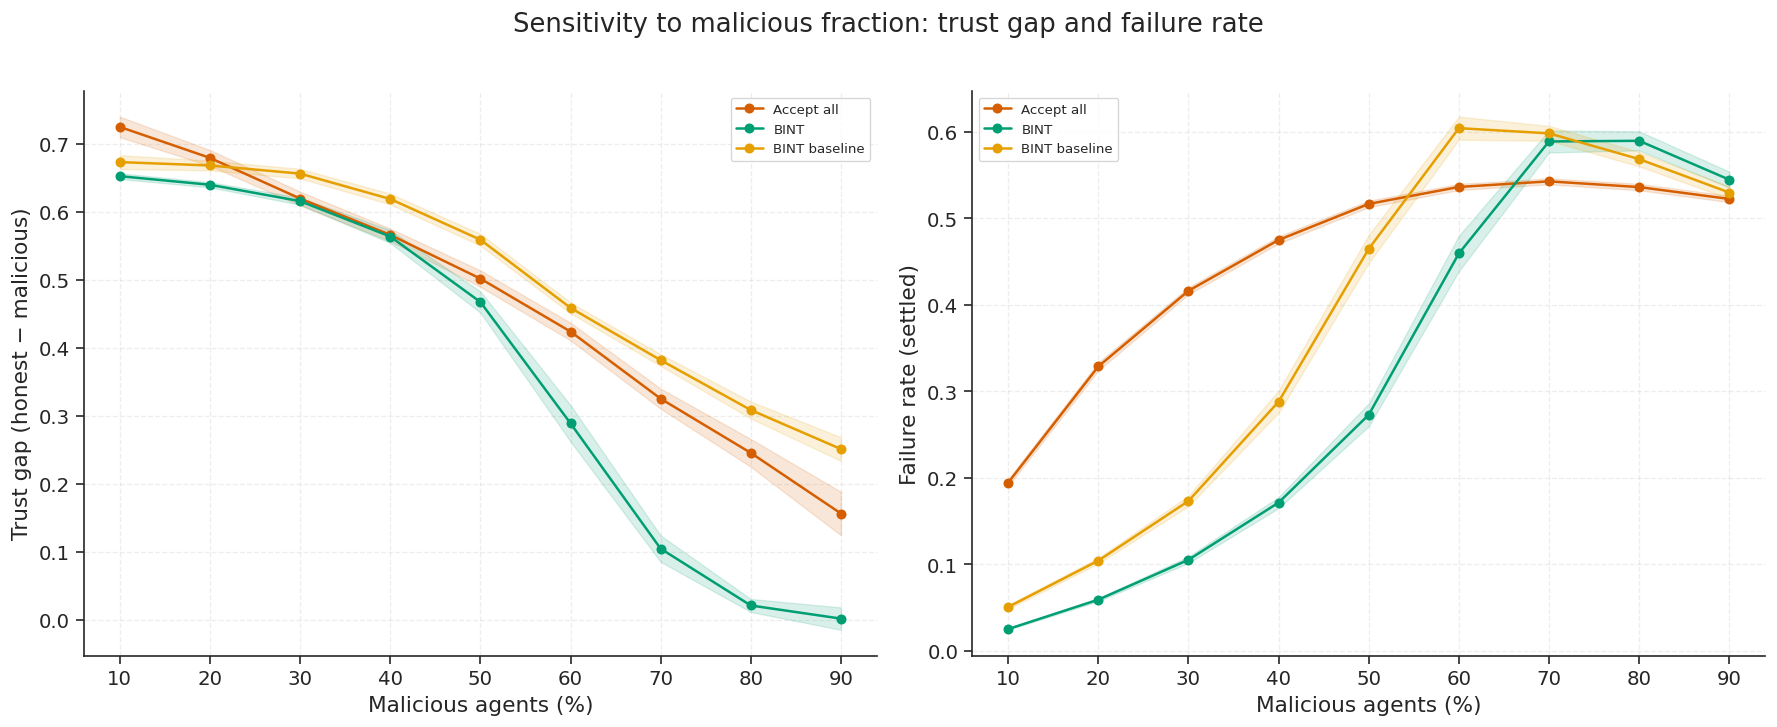

In [60]:
# ── Figure: Sensitivity — trust gap and damage rate ──────────────────────────
# Extends the malicious fraction analysis to include trust gap and damage rate.

sen_final_dm = add_derived_metrics(sen_final.copy())

fig, axes = plt.subplots(1, 2, figsize=FIG_2PANEL)

_SEN_COLORS2 = {
    "BINT":          SCENARIO_COLORS["bint_staking"],
    "Accept all":    SCENARIO_COLORS["accept_all"],
    "BINT baseline": SCENARIO_COLORS["bint_baseline"],
}

for ax, (metric, ylabel) in zip(axes, [
    ("trust_gap_honest_minus_malicious", "Trust gap (honest − malicious)"),
    ("failure_rate",                     "Failure rate (settled)"),
]):
    for _st, _grp in sen_final_dm.groupby("scenario_type"):
        _sub = _grp.dropna(subset=["malicious_pct", metric])
        if _sub.empty: continue
        _agg = _sub.groupby("malicious_pct")[metric].agg(["mean","std","count"]).reset_index()
        _agg["ci"] = 1.96 * _agg["std"] / np.sqrt(_agg["count"])
        _c = _SEN_COLORS2.get(_st, "grey")
        ax.plot(_agg["malicious_pct"], _agg["mean"], marker="o", color=_c,
                linewidth=1.5, markersize=5, label=_st)
        ax.fill_between(_agg["malicious_pct"],
                        _agg["mean"] - _agg["ci"],
                        _agg["mean"] + _agg["ci"],
                        alpha=0.15, color=_c)
    ax.set_xlabel("Malicious agents (%)")
    ax.set_ylabel(ylabel)
    ax.set_xticks([int(f * 100) for f in SENSITIVITY_FRACTIONS])
    ax.legend(fontsize=8)
    sns.despine(ax=ax)

fig.suptitle("Sensitivity to malicious fraction: trust gap and failure rate", y=1.01)
fig.tight_layout()
save_figure("fig_sensitivity_trust_failure.pdf")
plt.show()

## Key findings summary

This cell prints all the key quantitative claims that can be made in the
thesis/report, with exact values and seeds for reproducibility.

In [61]:
# ── Key findings summary ─────────────────────────────────────────────────────
print("=" * 70)
print("BINT EVALUATION — KEY FINDINGS")
print(f"Ablation: {abl_final['seed'].nunique()} seeds × {abl_final['config'].nunique()} scenarios")
print("=" * 70)

_kf = abl_final.groupby("config").agg(
    failure_rate_mean=("failure_rate","mean"),
    failure_rate_std=("failure_rate","std"),
    pts_honest_mean=("points_per_honest_agent","mean"),
    pts_honest_std=("points_per_honest_agent","std"),
    pts_mal_mean=("points_per_malicious_agent","mean"),
    pts_mal_std=("points_per_malicious_agent","std"),
    mal_rate_mean=("accepted_malicious_rate","mean"),
    trust_gap_mean=("trust_gap_honest_minus_malicious","mean"),
).reindex(SCENARIO_ORDER)

for _cfg in SCENARIO_ORDER:
    if _cfg not in _kf.index: continue
    _r = _kf.loc[_cfg]
    print(f"\n{SCENARIO_LABELS[_cfg]}:")
    print(f"  Failure rate:          {_r.failure_rate_mean:.3f} ± {_r.failure_rate_std:.3f}")
    print(f"  Honest pts/agent:      {_r.pts_honest_mean:.1f} ± {_r.pts_honest_std:.1f}")
    if not pd.isna(_r.pts_mal_mean):
        print(f"  Malicious pts/agent:   {_r.pts_mal_mean:.1f} ± {_r.pts_mal_std:.1f}")
    if not pd.isna(_r.mal_rate_mean):
        print(f"  Malicious provider rt: {_r.mal_rate_mean:.3f}")
    if not pd.isna(_r.trust_gap_mean):
        print(f"  Trust gap (H-M):       {_r.trust_gap_mean:.3f}")

# Improvement ratios
_at = _kf.loc["accept_all"]
_bk = _kf.loc["bint_staking"]
print("\n" + "=" * 70)
print("BINT vs Accept-all improvements:")
print(f"  Failure rate reduction: {(_at.failure_rate_mean - _bk.failure_rate_mean) / _at.failure_rate_mean * 100:.1f}%")
print(f"  Malicious reward drop:  {(_at.pts_mal_mean - _bk.pts_mal_mean) / abs(_at.pts_mal_mean) * 100:.1f}%")
print(f"  Honest reward change:   {(_bk.pts_honest_mean - _at.pts_honest_mean) / abs(_at.pts_honest_mean) * 100:.1f}%")
print(f"  Malicious provider reduction: {(_at.mal_rate_mean - _bk.mal_rate_mean) / _at.mal_rate_mean * 100:.1f}%")
# Precise mechanism: negative points come from late-delivery penalties (up to -20 pts/delivery),
# not from TNFT burns. BINT filters malicious providers so they receive false coordinates
# from other malicious agents (or no useful map data), causing them to deliver to wrong
# locations and accumulate LATE_PENALTY_PER_STEP penalties. TNFT burns reduce trust capital
# (affecting future filtering) but do not directly affect the points variable.
print("\nMechanism note: negative points arise from late-delivery penalties on wrong-coordinate " +
      f"deliveries, not from TNFT burns. Burns deplete trust capital, worsening future " +
      f"filtering outcomes. Combined effect: {_bk.pts_mal_mean:.1f} pts/agent in full BINT.")
print("=" * 70)

BINT EVALUATION — KEY FINDINGS
Ablation: 100 seeds × 4 scenarios

Honest-only:
  Failure rate:          0.000 ± 0.000
  Honest pts/agent:      692.5 ± 43.6
  Malicious provider rt: 0.000

Accept all:
  Failure rate:          0.416 ± 0.021
  Honest pts/agent:      540.9 ± 43.0
  Malicious pts/agent:   558.1 ± 49.1
  Malicious provider rt: 0.490
  Trust gap (H-M):       0.619

BINT (baseline):
  Failure rate:          0.173 ± 0.031
  Honest pts/agent:      526.7 ± 113.5
  Malicious pts/agent:   27.4 ± 34.3
  Malicious provider rt: 0.171
  Trust gap (H-M):       0.656

BINT:
  Failure rate:          0.105 ± 0.019
  Honest pts/agent:      480.4 ± 134.4
  Malicious pts/agent:   -1.1 ± 12.3
  Malicious provider rt: 0.115
  Trust gap (H-M):       0.615

BINT vs Accept-all improvements:
  Failure rate reduction: 74.7%
  Malicious reward drop:  100.2%
  Honest reward change:   -11.2%
  Malicious provider reduction: 76.6%

Mechanism note: negative points arise from late-delivery penalties on wro

Saved: fig10_interaction_outcomes_over_time.pdf + fig10_interaction_outcomes_over_time.svg


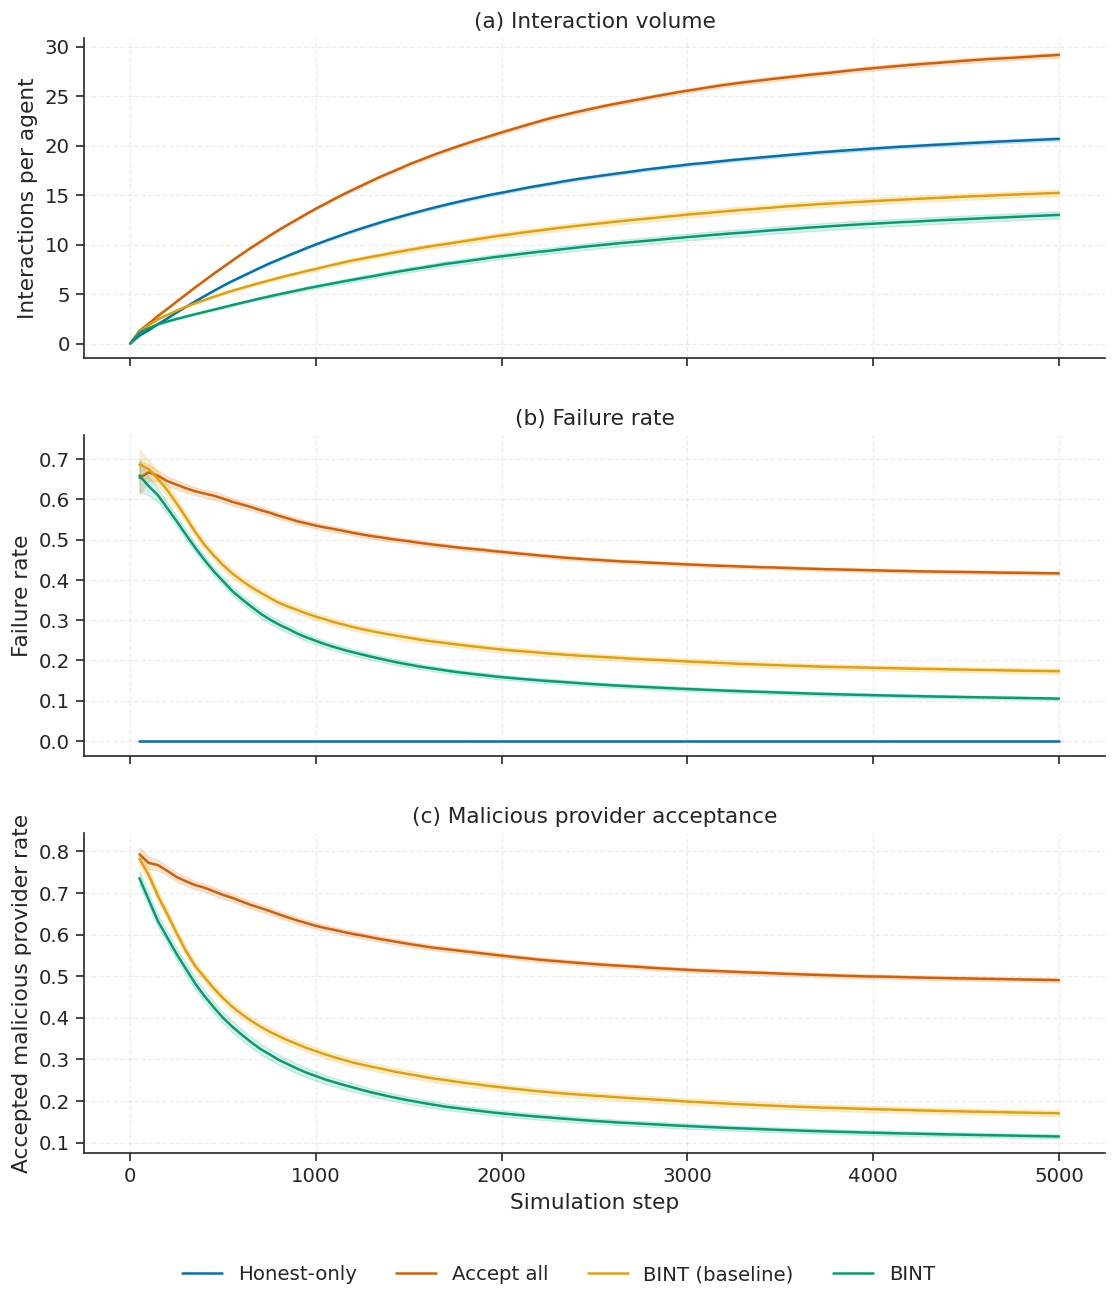

In [62]:
# ── Fixed Figure 6: Interaction outcomes over time, vertical readable version ──
# Overwrites fig10_interaction_outcomes_over_time.pdf / .svg

fig, axes = plt.subplots(3, 1, figsize=(9.5, 11.0), sharex=True)

ci_lineplot(
    axes[0],
    abl_traj,
    y="interactions_per_agent",
    configs=SCENARIO_ORDER,
    ylabel="Interactions per agent",
    title="(a) Interaction volume",
)

ci_lineplot(
    axes[1],
    abl_traj,
    y="failure_rate",
    configs=SCENARIO_ORDER,
    ylabel="Failure rate",
    title="(b) Failure rate",
)

ci_lineplot(
    axes[2],
    abl_traj[abl_traj["malicious_agents"] > 0],
    y="accepted_malicious_rate",
    configs=[c for c in SCENARIO_ORDER if c != "honest_only_upper_bound"],
    ylabel="Accepted malicious provider rate",
    title="(c) Malicious provider acceptance",
)

# Use one shared legend instead of repeating it three times.
handles, labels = axes[0].get_legend_handles_labels()
for ax in axes:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

for ax in axes[:-1]:
    ax.set_xlabel("")

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.005),
)

fig.tight_layout(rect=(0, 0.055, 1, 1), h_pad=2.0)
save_figure("fig10_interaction_outcomes_over_time.pdf")
plt.show()

Saved: fig11_sensitivity_malicious_fraction.pdf + fig11_sensitivity_malicious_fraction.svg


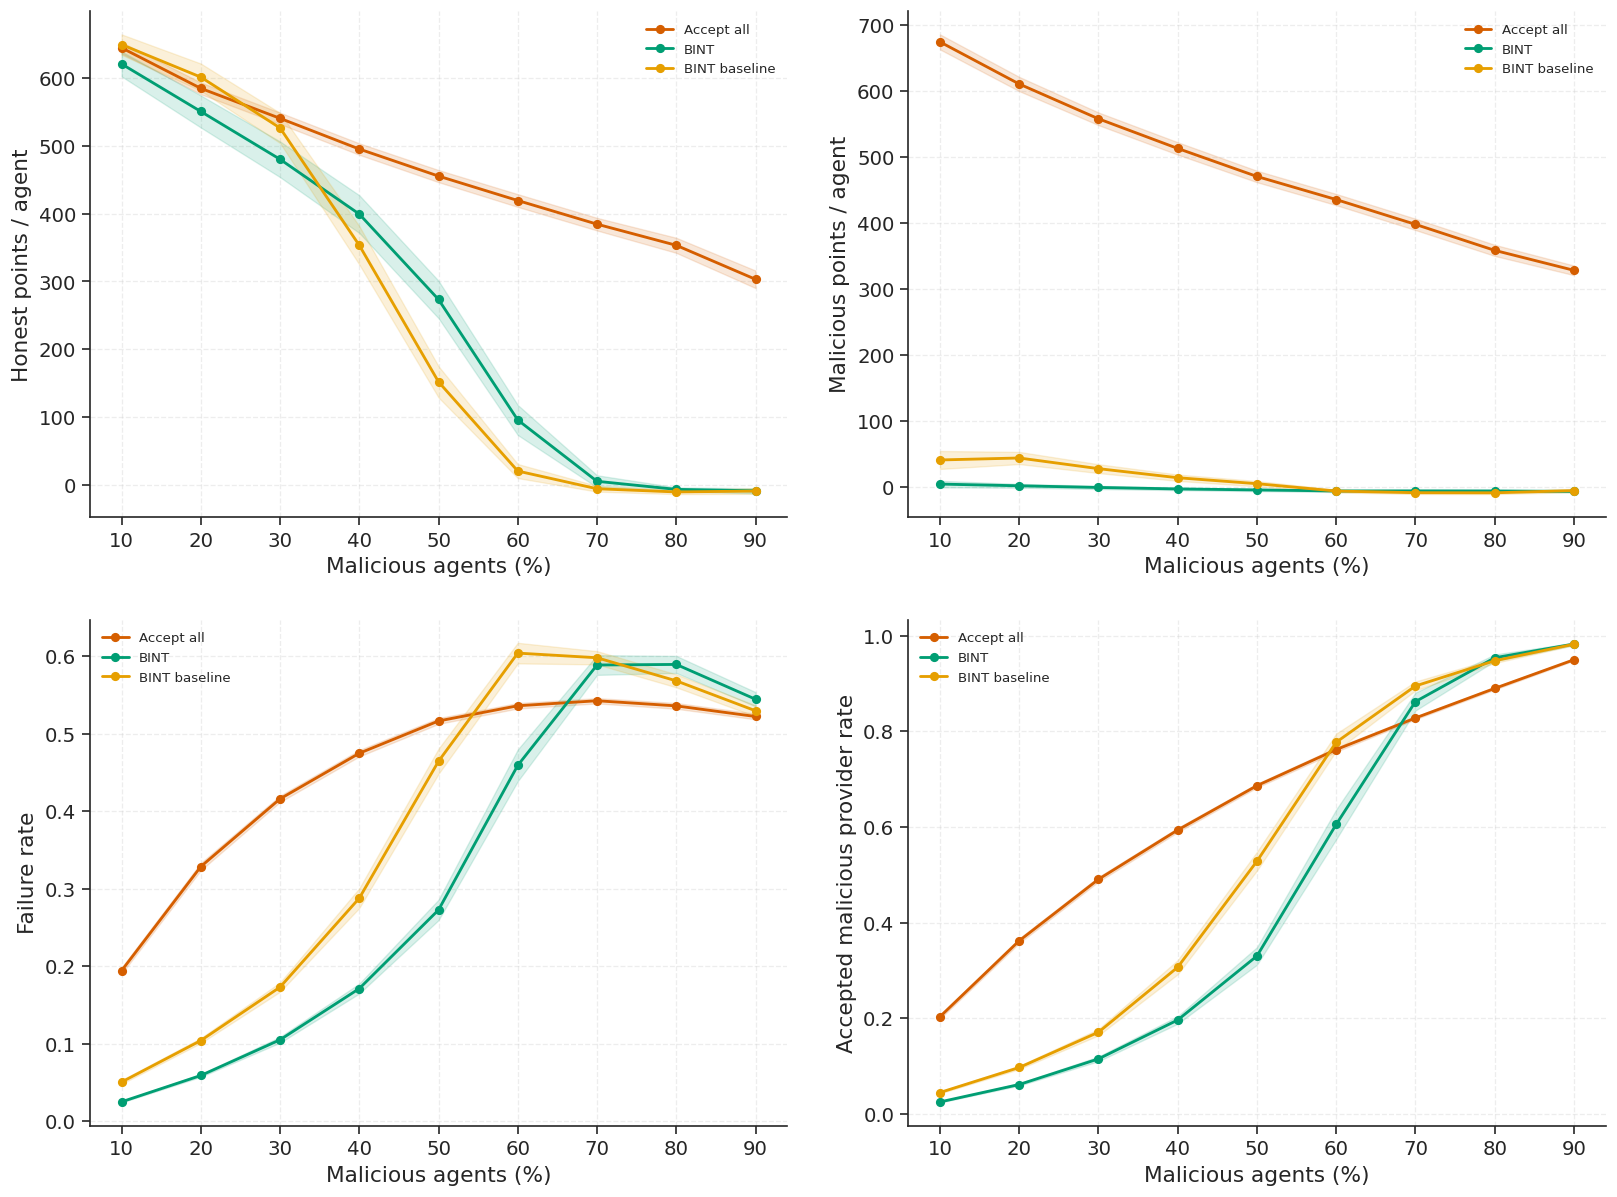

In [63]:
# ── Fixed Figure 7: Sensitivity to malicious fraction, no global title ─────────
# Overwrites fig11_sensitivity_malicious_fraction.pdf / .svg

_key_metrics = [
    ("points_per_honest_agent",    "Honest points / agent"),
    ("points_per_malicious_agent", "Malicious points / agent"),
    ("failure_rate",               "Failure rate"),
    ("accepted_malicious_rate",    "Accepted malicious provider rate"),
]

TYPE_COLORS_SEN = {
    "BINT":          SCENARIO_COLORS["bint_staking"],
    "Accept all":    SCENARIO_COLORS["accept_all"],
    "BINT baseline": SCENARIO_COLORS["bint_baseline"],
}

fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.5))
axes = axes.flatten()

for ax, (metric, ylabel) in zip(axes, _key_metrics):
    for stype, grp in sen_final.groupby("scenario_type"):
        sub = grp.dropna(subset=["malicious_pct", metric]).copy()
        if sub.empty:
            continue

        agg = (
            sub.groupby("malicious_pct")[metric]
            .agg(["mean", "std", "count"])
            .reset_index()
            .sort_values("malicious_pct")
        )
        agg["ci"] = 1.96 * agg["std"] / np.sqrt(agg["count"])

        color = TYPE_COLORS_SEN.get(stype, "grey")
        ax.plot(
            agg["malicious_pct"],
            agg["mean"],
            marker="o",
            color=color,
            linewidth=1.7,
            markersize=4.5,
            label=stype,
        )
        ax.fill_between(
            agg["malicious_pct"],
            agg["mean"] - agg["ci"],
            agg["mean"] + agg["ci"],
            alpha=0.15,
            color=color,
        )

    ax.set_xlabel("Malicious agents (%)")
    ax.set_ylabel(ylabel)
    ax.set_xticks([int(f * 100) for f in SENSITIVITY_FRACTIONS])
    ax.legend(fontsize=8, frameon=False)
    sns.despine(ax=ax)

fig.tight_layout(pad=2.0)
save_figure("fig11_sensitivity_malicious_fraction.pdf")
plt.show()

Saved: fig_map_attack_sensitivity.pdf + fig_map_attack_sensitivity.svg


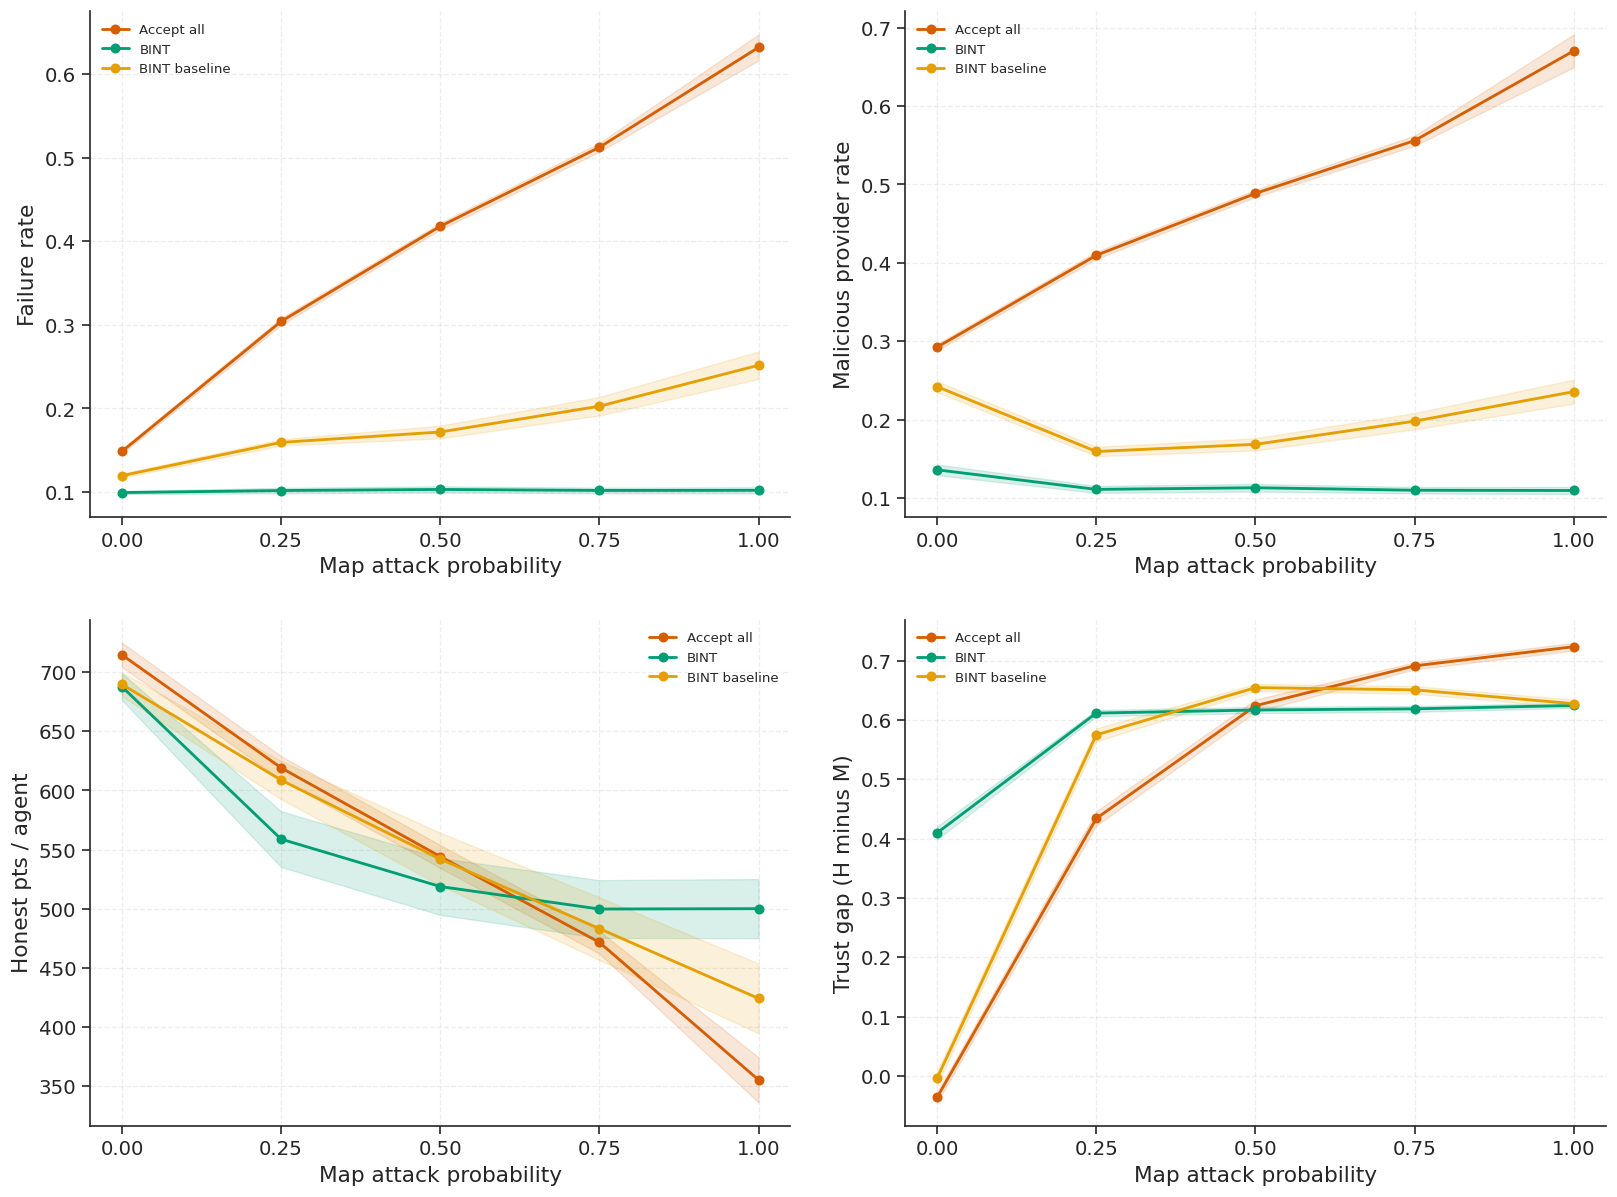

In [64]:
# ── Fixed Figure 8: Map attack sensitivity, no incorrect seed title ───────────
# Overwrites fig_map_attack_sensitivity.pdf / .svg

if atk_map_final is None:
    print("Map attack data not available — run/load the attack sensitivity data first.")
else:
    _m_cols = [
        ("failure_rate", "Failure rate"),
        ("accepted_malicious_rate", "Malicious provider rate"),
        ("points_per_honest_agent", "Honest pts / agent"),
        ("trust_gap_honest_minus_malicious", "Trust gap (H minus M)"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.5))
    axes = axes.flatten()

    for ax, (_m, _y) in zip(axes, _m_cols):
        for _st, _grp in atk_map_final.groupby("scenario_type"):
            _s = _grp.dropna(subset=["map_attack_prob", _m]).copy()
            if _s.empty:
                continue

            _a = (
                _s.groupby("map_attack_prob")[_m]
                .agg(["mean", "std", "count"])
                .reset_index()
                .sort_values("map_attack_prob")
            )
            _a["ci"] = 1.96 * _a["std"] / np.sqrt(_a["count"])

            _c = _ATK_COLORS.get(_st, "grey")
            ax.plot(
                _a["map_attack_prob"],
                _a["mean"],
                marker="o",
                color=_c,
                linewidth=1.7,
                markersize=5,
                label=_st,
            )
            ax.fill_between(
                _a["map_attack_prob"],
                _a["mean"] - _a["ci"],
                _a["mean"] + _a["ci"],
                alpha=0.15,
                color=_c,
            )

        ax.set_xlabel("Map attack probability")
        ax.set_ylabel(_y)
        ax.set_xticks(ATK_MAP_PROBS)
        ax.legend(fontsize=8, frameon=False)
        sns.despine(ax=ax)

    fig.tight_layout(pad=2.0)
    save_figure("fig_map_attack_sensitivity.pdf")
    plt.show()

Saved: fig_review_attack_sensitivity.pdf + fig_review_attack_sensitivity.svg


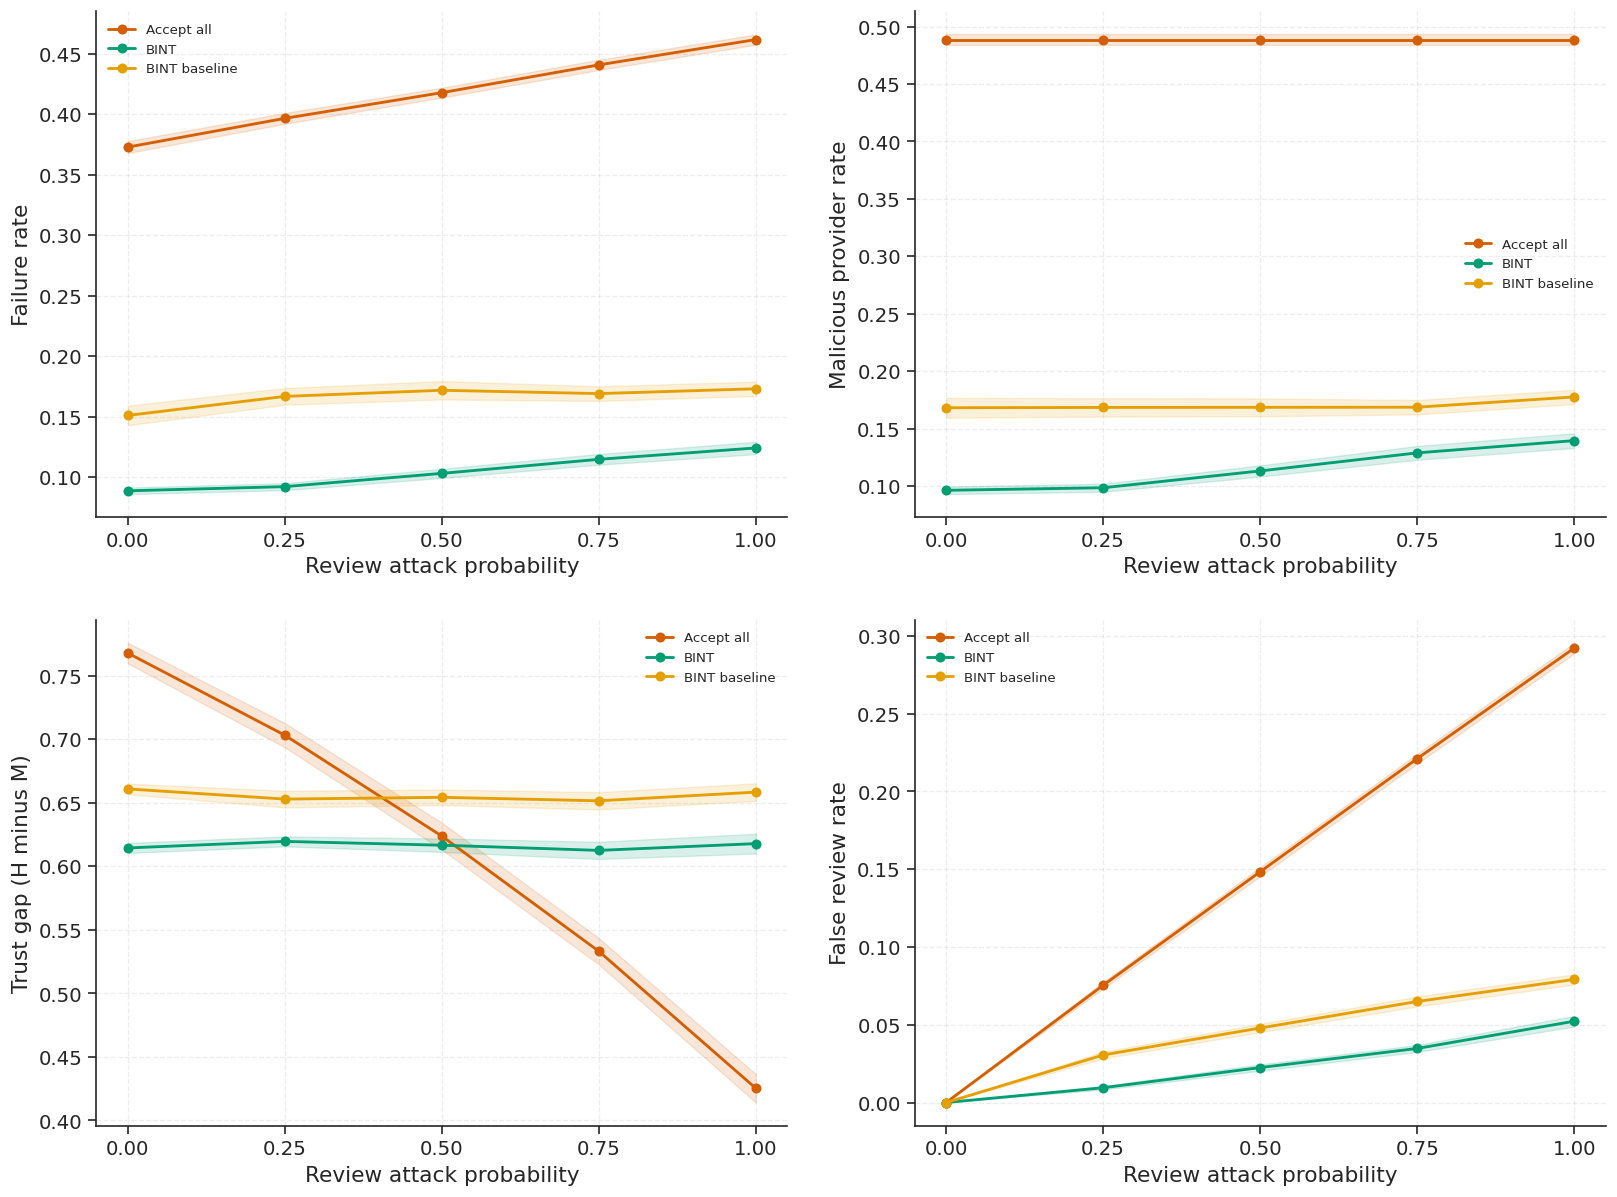

In [65]:
# ── Fixed Figure 9: Review attack sensitivity, no incorrect seed title ────────
# Overwrites fig_review_attack_sensitivity.pdf / .svg

if atk_rev_final is None:
    print("Review attack data not available — run/load the attack sensitivity data first.")
else:
    _r_cols = [
        ("failure_rate", "Failure rate"),
        ("accepted_malicious_rate", "Malicious provider rate"),
        ("trust_gap_honest_minus_malicious", "Trust gap (H minus M)"),
        ("false_review_rate", "False review rate"),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.5))
    axes = axes.flatten()

    for ax, (_m, _y) in zip(axes, _r_cols):
        for _st, _grp in atk_rev_final.groupby("scenario_type"):
            _s = _grp.dropna(subset=["review_attack_prob", _m]).copy()
            if _s.empty:
                continue

            _a = (
                _s.groupby("review_attack_prob")[_m]
                .agg(["mean", "std", "count"])
                .reset_index()
                .sort_values("review_attack_prob")
            )
            _a["ci"] = 1.96 * _a["std"] / np.sqrt(_a["count"])

            _c = _ATK_COLORS.get(_st, "grey")
            ax.plot(
                _a["review_attack_prob"],
                _a["mean"],
                marker="o",
                color=_c,
                linewidth=1.7,
                markersize=5,
                label=_st,
            )
            ax.fill_between(
                _a["review_attack_prob"],
                _a["mean"] - _a["ci"],
                _a["mean"] + _a["ci"],
                alpha=0.15,
                color=_c,
            )

        ax.set_xlabel("Review attack probability")
        ax.set_ylabel(_y)
        ax.set_xticks(ATK_REV_PROBS)
        ax.legend(fontsize=8, frameon=False)
        sns.despine(ax=ax)

    fig.tight_layout(pad=2.0)
    save_figure("fig_review_attack_sensitivity.pdf")
    plt.show()

Saved: fig_corner_attack_heatmap.pdf + fig_corner_attack_heatmap.svg


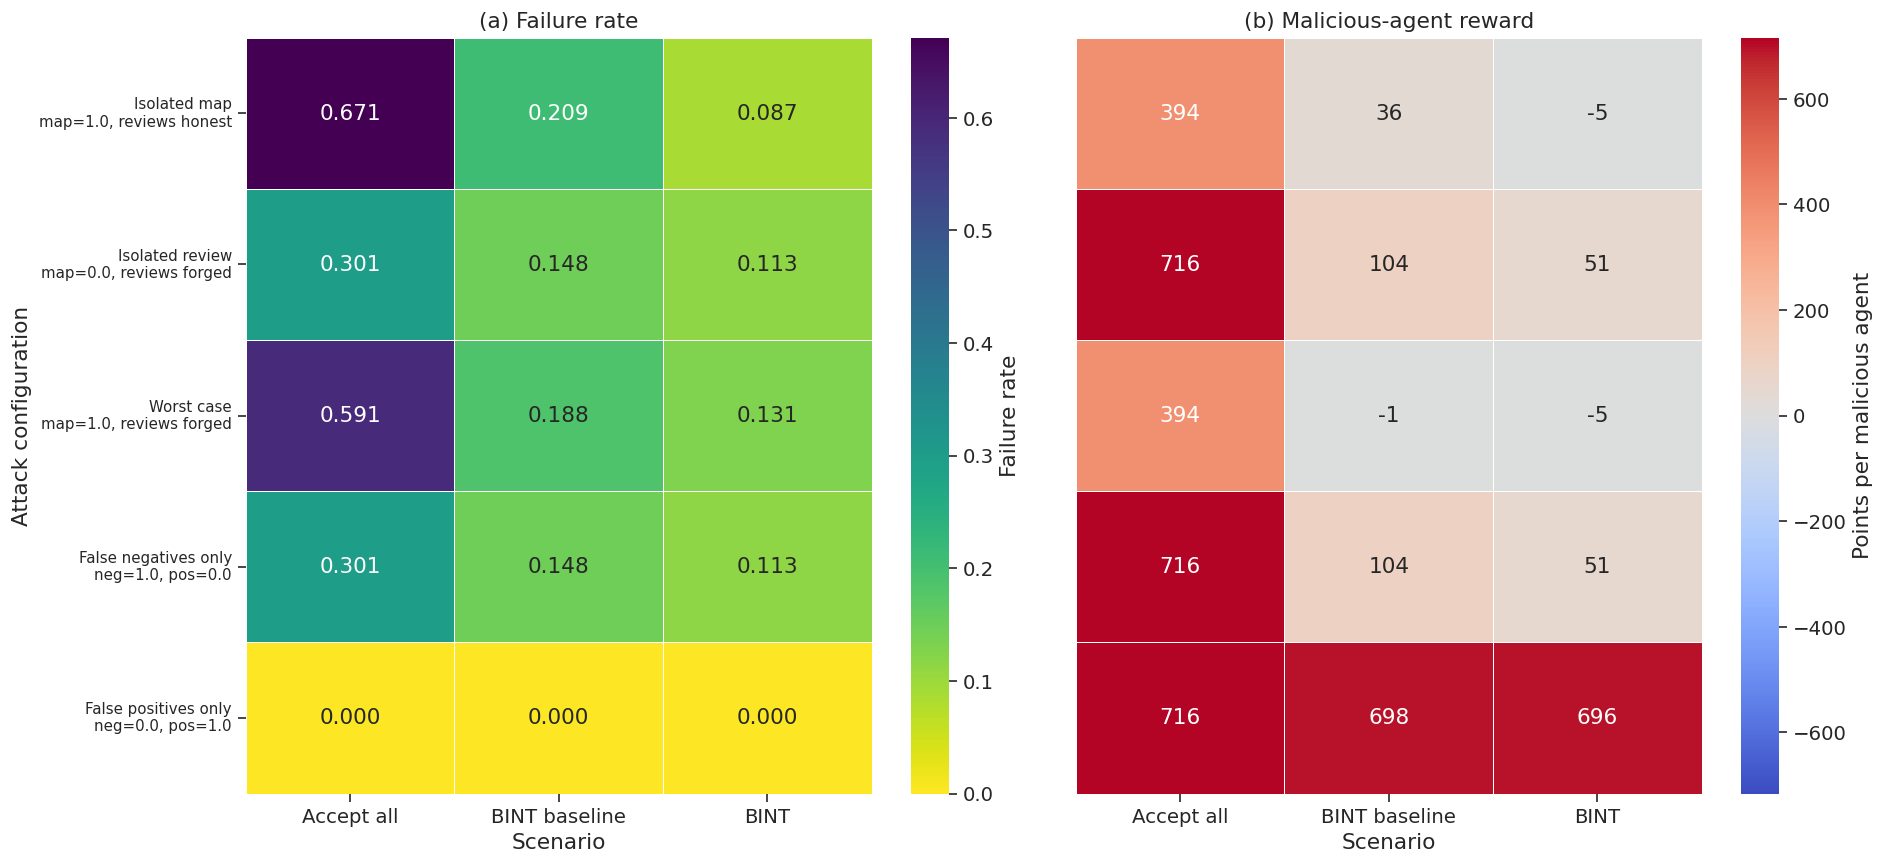

Key results — failure rate:
scenario_type  Accept all  BINT baseline  BINT
attack_tag                                    
isomap              0.671          0.209 0.087
isorev              0.301          0.148 0.113
worst               0.591          0.188 0.131
falneg              0.301          0.148 0.113
falpos              0.000          0.000 0.000

Key results — malicious pts / agent:
scenario_type  Accept all  BINT baseline  BINT
attack_tag                                    
isomap              393.8           36.4  -5.5
isorev              716.0          103.9  51.2
worst               393.6           -1.2  -5.4
falneg              716.0          103.9  51.2
falpos              716.0          698.1 696.1


In [66]:
# ── Improved Figure 10: Corner attack heatmap, clearer labels ─────────────────
# Overwrites fig_corner_attack_heatmap.pdf / .svg

if corner_final is None:
    print("Corner attack data not available — run/load the corner attack data first.")
else:
    _SCEN_ORDER_C = ["Accept all", "BINT baseline", "BINT"]
    _ATK_ORDER = [tag for tag, *_ in _CORNER_ATTACKS]

    _ATK_LABELS = {
        "isomap": "Isolated map\nmap=1.0, reviews honest",
        "isorev": "Isolated review\nmap=0.0, reviews forged",
        "worst": "Worst case\nmap=1.0, reviews forged",
        "falneg": "False negatives only\nneg=1.0, pos=0.0",
        "falpos": "False positives only\nneg=0.0, pos=1.0",
    }

    _piv_fail = (
        corner_final
        .groupby(["attack_tag", "scenario_type"])["failure_rate"]
        .mean()
        .reset_index()
        .pivot(index="attack_tag", columns="scenario_type", values="failure_rate")
        .reindex(index=_ATK_ORDER, columns=_SCEN_ORDER_C)
    )

    _piv_mal = (
        corner_final[corner_final["malicious_agents"] > 0]
        .groupby(["attack_tag", "scenario_type"])["points_per_malicious_agent"]
        .mean()
        .reset_index()
        .pivot(index="attack_tag", columns="scenario_type", values="points_per_malicious_agent")
        .reindex(index=_ATK_ORDER, columns=_SCEN_ORDER_C)
    )

    row_labels = [_ATK_LABELS[t] for t in _ATK_ORDER]

    fig, axes = plt.subplots(1, 2, figsize=(16.0, 7.4))

    sns.heatmap(
        _piv_fail,
        ax=axes[0],
        annot=True,
        fmt=".3f",
        cmap="viridis_r",
        vmin=0.0,
        vmax=max(0.6, float(np.nanmax(_piv_fail.values))),
        linewidths=0.5,
        cbar_kws={"label": "Failure rate"},
        yticklabels=row_labels,
    )
    axes[0].set_title("(a) Failure rate")
    axes[0].set_xlabel("Scenario")
    axes[0].set_ylabel("Attack configuration")
    axes[0].tick_params(axis="y", labelsize=9)

    _abs_max = max(abs(_piv_mal.values[~np.isnan(_piv_mal.values)]).max(), 1)

    sns.heatmap(
        _piv_mal,
        ax=axes[1],
        annot=True,
        fmt=".0f",
        cmap="coolwarm",
        center=0,
        vmin=-_abs_max,
        vmax=_abs_max,
        linewidths=0.5,
        cbar_kws={"label": "Points per malicious agent"},
        yticklabels=False,
    )
    axes[1].set_title("(b) Malicious-agent reward")
    axes[1].set_xlabel("Scenario")
    axes[1].set_ylabel("")

    fig.tight_layout(w_pad=2.0)
    save_figure("fig_corner_attack_heatmap.pdf")
    plt.show()

    print("Key results — failure rate:")
    print(_piv_fail.to_string(float_format=lambda x: f"{x:.3f}"))

    print("\nKey results — malicious pts / agent:")
    print(_piv_mal.to_string(float_format=lambda x: f"{x:.1f}"))

In [67]:
# ============================================================================
# Staking validity check  —  paste as a NEW CELL at the END of bint_eval_clean
#
# Question: are the full-BINT gains real, or just an artifact of staking doing
# FEWER interactions (fewer interactions -> trivially fewer absolute failures)?
#
# Logic: the headline safety metrics are already RATES (per-interaction), so if
# staking only reduced volume they would NOT move. We test, BINT baseline -> BINT:
#   1. rate metrics (failure_rate, accepted_malicious_rate) with Mann-Whitney +
#      Cohen's d  -> do they improve beyond what volume alone would give?
#   2. a decomposition of the absolute failure COUNT into volume x rate
#   3. malicious payoff PER accepted interaction (volume-normalised incentive)
#   4. honest efficiency: points per interaction and per delivery
#
# Uses the already-loaded `abl_final` dataframe and the helpers defined earlier
# (SCENARIO_LABELS, the `stats` import from the significance cell).
# ============================================================================
import numpy as np, pandas as pd
from scipy import stats

BASE, FULL = "bint_baseline", "bint_staking"

df = abl_final.copy()

# --- make sure the per-interaction columns we need exist (derive if missing) ---
if "interactions" not in df.columns and "interactions_per_agent" in df.columns and "total_agents" in df.columns:
    df["interactions"] = df["interactions_per_agent"] * df["total_agents"]
# malicious payoff per accepted interaction (volume-normalised incentive signal)
if {"points_malicious", "accepted_malicious_provider"}.issubset(df.columns):
    df["mal_points_per_accepted_mal_interaction"] = df["points_malicious"] / df["accepted_malicious_provider"].replace(0, np.nan)
# honest efficiency
if {"points_honest", "interactions"}.issubset(df.columns):
    df["honest_points_per_interaction"] = df["points_honest"] / df["interactions"].replace(0, np.nan)

a = df[df["config"] == BASE]
b = df[df["config"] == FULL]

def cohens_d(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    nx, ny = len(x), len(y)
    sp = np.sqrt(((nx-1)*x.std(ddof=1)**2 + (ny-1)*y.std(ddof=1)**2) / (nx+ny-2))
    return (y.mean() - x.mean()) / sp if sp > 0 else 0.0

def compare(col, lower_is_better=True):
    xa, xb = a[col].dropna().values, b[col].dropna().values
    if len(xa) < 2 or len(xb) < 2:
        return None
    _, p = stats.mannwhitneyu(xa, xb, alternative="two-sided")
    d = cohens_d(xa, xb)
    better = (xb.mean() < xa.mean()) if lower_is_better else (xb.mean() > xa.mean())
    return dict(metric=col, base=xa.mean(), full=xb.mean(),
                delta=xb.mean()-xa.mean(), p=p, d=abs(d),
                moves_right_way=better)

print("="*78)
print("STAKING VALIDITY  —  BINT baseline -> full BINT   (n =",
      int(min(a['seed'].nunique(), b['seed'].nunique())), "seeds each)")
print("="*78)

# ---- 1. Rate metrics: these are per-interaction, so volume cannot explain them
print("\n[1] PER-INTERACTION RATE METRICS (volume-independent by construction)")
print(f"    {'metric':38s} {'base':>8} {'full':>8} {'delta':>8} {'p':>9} {'d':>6}")
rate_real = True
for col, lo in [("failure_rate", True), ("accepted_malicious_rate", True),
                ("success_rate", False)]:
    r = compare(col, lower_is_better=lo)
    if r is None:
        print(f"    {col:38s}  (column missing)"); continue
    sig = "***" if r['p']<0.001 else "**" if r['p']<0.01 else "*" if r['p']<0.05 else "ns"
    print(f"    {col:38s} {r['base']:8.3f} {r['full']:8.3f} {r['delta']:+8.3f} "
          f"{r['p']:9.4f} {r['d']:6.2f}  {sig}")
    if col in ("failure_rate", "accepted_malicious_rate"):
        if not (r['moves_right_way'] and r['p'] < 0.05):
            rate_real = False

# ---- 2. Decompose absolute failures = interactions x failure_rate
print("\n[2] FAILURE-COUNT DECOMPOSITION  (failures = interactions x failure_rate)")
inter_a, inter_b = a["interactions"].mean(), b["interactions"].mean()
fr_a, fr_b = a["failure_rate"].mean(), b["failure_rate"].mean()
fail_a, fail_b = inter_a*fr_a, inter_b*fr_b
print(f"    interactions/run : base {inter_a:8.1f}  ->  full {inter_b:8.1f}  "
      f"({100*(inter_b-inter_a)/inter_a:+.1f}%)")
print(f"    failure_rate     : base {fr_a:8.3f}  ->  full {fr_b:8.3f}  "
      f"({100*(fr_b-fr_a)/fr_a:+.1f}%)")
print(f"    => est. failures : base {fail_a:8.1f}  ->  full {fail_b:8.1f}")
# counterfactual: full BINT's volume but baseline's per-interaction rate
cf = inter_b * fr_a
print(f"    counterfactual (full volume, baseline rate) = {cf:6.1f} failures")
print(f"    of the {fail_a-fail_b:.1f} fewer failures, "
      f"{fail_a-cf:6.1f} come from LESS VOLUME and "
      f"{cf-fail_b:6.1f} from a LOWER PER-INTERACTION RATE")

# ---- 3. Incentive per accepted interaction (not per run)
print("\n[3] MALICIOUS PAYOFF PER ACCEPTED MALICIOUS INTERACTION (volume-normalised)")
r = compare("mal_points_per_accepted_mal_interaction", lower_is_better=True)
if r:
    sig = "***" if r['p']<0.001 else "**" if r['p']<0.01 else "*" if r['p']<0.05 else "ns"
    print(f"    base {r['base']:.3f}  ->  full {r['full']:.3f}  "
          f"(delta {r['delta']:+.3f}, p={r['p']:.4f}, d={r['d']:.2f} {sig})")
    print("    If this DROPS, staking lowers the per-interaction payoff of cheating,")
    print("    not merely the number of times a malicious agent gets accepted.")

# ---- 4. Honest efficiency (is selectivity hurting honest agents per interaction?)
print("\n[4] HONEST EFFICIENCY")
for col in ["honest_points_per_interaction", "points_per_honest_agent",
            "deliveries_per_honest_agent"]:
    r = compare(col, lower_is_better=False)
    if r:
        print(f"    {col:34s} base {r['base']:8.3f} -> full {r['full']:8.3f} "
              f"(delta {r['delta']:+.3f}, p={r['p']:.4f})")

# ---- verdict ----
print("\n" + "="*78)
print("VERDICT")
print("="*78)
if rate_real:
    print("Staking improves the PER-INTERACTION rates (failure & malicious-provider)")
    print("significantly. Because these are already volume-normalised, the gain is NOT")
    print("merely an artifact of doing fewer interactions: each accepted interaction is")
    print("genuinely safer under staking. The decomposition in [2] shows how much of the")
    print("absolute drop is volume vs. rate, and [3] shows whether the incentive effect")
    print("survives normalisation. (Caveat: this holds for THIS scenario/parameters.)")
else:
    print("The per-interaction rate change is small or not significant -> the benefit is")
    print("largely a VOLUME effect (fewer interactions), not a genuine per-interaction")
    print("improvement. In that case staking mostly adds selectivity, not protection,")
    print("and you should report it as such.")


STAKING VALIDITY  —  BINT baseline -> full BINT   (n = 100 seeds each)

[1] PER-INTERACTION RATE METRICS (volume-independent by construction)
    metric                                     base     full    delta         p      d
    failure_rate                              0.173    0.105   -0.068    0.0000   2.66  ***
    accepted_malicious_rate                   0.171    0.115   -0.056    0.0000   1.88  ***
    success_rate                              0.827    0.895   +0.068    0.0000   2.66  ***

[2] FAILURE-COUNT DECOMPOSITION  (failures = interactions x failure_rate)
    interactions/run : base    304.4  ->  full    259.9  (-14.6%)
    failure_rate     : base    0.173  ->  full    0.105  (-39.2%)
    => est. failures : base     52.7  ->  full     27.3
    counterfactual (full volume, baseline rate) =   45.0 failures
    of the 25.4 fewer failures,    7.7 come from LESS VOLUME and   17.7 from a LOWER PER-INTERACTION RATE

[3] MALICIOUS PAYOFF PER ACCEPTED MALICIOUS INTERACTION (vo